# BAGIAN 1

## Analisis 1: Pengukuran Kesenjangan Inklusi vs Literasi Nasional ($FLGI$)

Menghitung kesenjangan absolut antara persentase masyarakat yang memiliki akses produk keuangan (Inklusi) terhadap persentase masyarakat yang benar-benar memahami manfaat dan risikonya (Literasi). Indikator ini menjadi headline metric pembuka infografis. 

In [40]:
import pandas as pd

df_inklusi = pd.read_csv(r'Dataset\indeks_inklusi_keuangan_2026.csv')
df_literasi = pd.read_csv(r'Dataset\indeks_literasi_keuangan_2026.csv')

# Ambil baris agregat nasional
inklusi_nas = df_inklusi.loc[df_inklusi['Provinsi'] == 'INDONESIA', 'Indeks Inklusi Keuangan (%)'].values[0]
literasi_nas = df_literasi.loc[df_literasi['Provinsi'] == 'INDONESIA', 'Indeks Literasi Keuangan (%)'].values[0]

flgi_nasional = inklusi_nas - literasi_nas
print(f"Inklusi Nasional  : {inklusi_nas:.2f}%")
print(f"Literasi Nasional : {literasi_nas:.2f}%")
print(f"Gap (FLGI)        : {flgi_nasional:.2f}%")

Inklusi Nasional  : 93.61%
Literasi Nasional : 69.57%
Gap (FLGI)        : 24.04%


Perbedaan Literasi dan Inklusi Keuangan
- Literasi keuangan: Pengetahuan, keterampilan, dan keyakinan seseorang untuk mengelola keuangan secara bijak.
- Inklusi keuangan: Ketersediaan akses dan kemudahan bagi masyarakat dalam menggunakan produk atau layanan keuangan formal.

"Akses Terbuka Lebar, Pemahaman Tertinggal: Sebanyak 93,61% penduduk telah terhubung ke ekosistem keuangan, namun indeks literasi tertahan di 69,57%. Terdapat jurang kerentanan nasional sebesar 24,04% masyarakat yang aktif bertransaksi tanpa pemahaman risiko finansial yang utuh."

## Analisis 2: Akselerasi Volume Transaksi Belanja Digital (QRIS vs Uang Elektronik)

Menghitung laju pertumbuhan transaksi belanja (Quarter-on-Quarter, Year-on-Year, dan pertumbuhan total dari 2023-Q1 hingga 2026-Q1). Analisis ini membuktikan secara kuantitatif bahwa belanja digital masyarakat melesat eksponensial.

In [41]:
df_ue = pd.read_csv(r'Dataset\Volume Transaksi Belanja (Uang Elektronik) - Triwulan.csv')
df_qris = pd.read_csv(r'Dataset\volume_transaksi_qris.csv')

# Standardisasi ke satuan Miliar Transaksi
df_ts = pd.DataFrame({
    'Period': [f"{y}-Q{q}" for y, q in zip(df_ue['Tahun'], [1, 2, 3, 4]*3 + [1])],
    'Belanja_UE_Miliar': df_ue['Total Transaksi (Dalam Ribuan)'] / 1e6,
    'Volume_QRIS_Miliar': df_qris['Total QRIS - Volume (Juta)'] / 1000
})

# Indeks acuan
idx_start = 0      # 2023-Q1 (Awal)
idx_end = -1       # 2026-Q1 (Akhir)
idx_py = -5        # 2025-Q1 (1 Tahun Sebelum Periode Akhir)

# 1. Ekstraksi Angka Mentah Total (2023-Q1 s.d. 2026-Q1)
qris_start, qris_end = df_ts['Volume_QRIS_Miliar'].iloc[idx_start], df_ts['Volume_QRIS_Miliar'].iloc[idx_end]
ue_start, ue_end = df_ts['Belanja_UE_Miliar'].iloc[idx_start], df_ts['Belanja_UE_Miliar'].iloc[idx_end]

growth_qris_total = ((qris_end - qris_start) / qris_start) * 100
growth_ue_total = ((ue_end - ue_start) / ue_start) * 100

# 2. Ekstraksi Angka Mentah YoY (2025-Q1 s.d. 2026-Q1)
qris_py = df_ts['Volume_QRIS_Miliar'].iloc[idx_py]
ue_py = df_ts['Belanja_UE_Miliar'].iloc[idx_py]

yoy_qris = ((qris_end - qris_py) / qris_py) * 100
yoy_ue = ((ue_end - ue_py) / ue_py) * 100

# Output Printout Terstruktur
print("=" * 70)
print(f"PERTUMBUHAN KESELURUHAN ({df_ts['Period'].iloc[idx_start]} -> {df_ts['Period'].iloc[idx_end]})")
print("=" * 70)
print(f"QRIS       : Dari {qris_start:.3f} Miliar ke {qris_end:.3f} Miliar Transaksi")
print(f"             -> Pertumbuhan: +{growth_qris_total:.2f}% (Melesat {qris_end/qris_start:.2f}x lipat)")
print(f"Belanja UE : Dari {ue_start:.3f} Miliar ke {ue_end:.3f} Miliar Transaksi")
print(f"             -> Pertumbuhan: +{growth_ue_total:.2f}% (Melesat {ue_end/ue_start:.2f}x lipat)")

print("\n" + "=" * 70)
print(f"PERTUMBUHAN YEAR-ON-YEAR / YoY ({df_ts['Period'].iloc[idx_py]} -> {df_ts['Period'].iloc[idx_end]})")
print("=" * 70)
print(f"QRIS       : Dari {qris_py:.3f} Miliar ({df_ts['Period'].iloc[idx_py]}) ke {qris_end:.3f} Miliar ({df_ts['Period'].iloc[idx_end]})")
print(f"             -> Pertumbuhan YoY: +{yoy_qris:.2f}%")
print(f"Belanja UE : Dari {ue_py:.3f} Miliar ({df_ts['Period'].iloc[idx_py]}) ke {ue_end:.3f} Miliar ({df_ts['Period'].iloc[idx_end]})")
print(f"             -> Pertumbuhan YoY: +{yoy_ue:.2f}%")
print("=" * 70)

PERTUMBUHAN KESELURUHAN (2023-Q1 -> 2026-Q1)
QRIS       : Dari 0.125 Miliar ke 2.118 Miliar Transaksi
             -> Pertumbuhan: +1594.40% (Melesat 16.94x lipat)
Belanja UE : Dari 1.719 Miliar ke 6.207 Miliar Transaksi
             -> Pertumbuhan: +260.98% (Melesat 3.61x lipat)

PERTUMBUHAN YEAR-ON-YEAR / YoY (2025-Q1 -> 2026-Q1)
QRIS       : Dari 1.021 Miliar (2025-Q1) ke 2.118 Miliar (2026-Q1)
             -> Pertumbuhan YoY: +107.44%
Belanja UE : Dari 3.977 Miliar (2025-Q1) ke 6.207 Miliar (2026-Q1)
             -> Pertumbuhan YoY: +56.07%


- Volume Transaksi QRIS (2023-Q1 ke 2026-Q1): Melesat dari 0,125 Miliar menjadi 2,118 Miliar transaksi (Tumbuh +1.594,40% atau 16,94× lipat; YoY bertengger di +107,44%).
- Volume Belanja Uang Elektronik (2023-Q1 ke 2026-Q1): Meningkat dari 1,719 Miliar menjadi 6,207 Miliar transaksi (Tumbuh +260,98% atau 3,61× lipat; YoY +56,07%).

"Ledakan Transaksi Ritel: Dalam rentang 3 tahun, transaksi QRIS melonjak hampir 17 kali lipat (+1.594%), sementara belanja uang elektronik server-based menembus 6,2 miliar transaksi per kuartal. Pola konsumsi masyarakat telah bertransformasi total menjadi digital-first."

## Analisis 3: Pemodelan Deret Waktu & Peramalan Tren Menuju 2027 (Forecasting)

Analisis ini memodelkan akselerasi dua kanal pembayaran digital utama (Belanja Uang Elektronik Server-Based dan Volume Transaksi QRIS) untuk memproyeksikan lintasan pertumbuhan hingga akhir tahun 2027 (Kuartal IV 2027).

EVALUASI AKURASI MODEL (IN-SAMPLE MAPE)
• MAPE Belanja Uang Elektronik : 3.58% (Tingkat Akurasi: Sangat Presisi / < 5%)
• MAPE Transaksi QRIS          : 6.21% (Tingkat Akurasi: Sangat Baik / < 10%)

RINCIAN HASIL PROYEKSI PER TRIWULAN (2026-Q2 s.d. 2027-Q4)
Triwulan Proyeksi  Forecast Belanja UE (Miliar)  Forecast QRIS (Miliar)
          2026-Q2                         6.536                   2.437
          2026-Q3                         6.857                   2.746
          2026-Q4                         7.178                   3.056
          2027-Q1                         7.500                   3.366
          2027-Q2                         7.821                   3.675
          2027-Q3                         8.142                   3.985
          2027-Q4                         8.464                   4.295

PERBANDINGAN CAPAIAN: AKTUAL (2026-Q1) vs TARGET PROYEKSI (2027-Q4)
• Belanja UE : Dari 6.207 Miliar (2026-Q1) -> 8.464 Miliar (2027-Q4)
               Kenaikan Proy

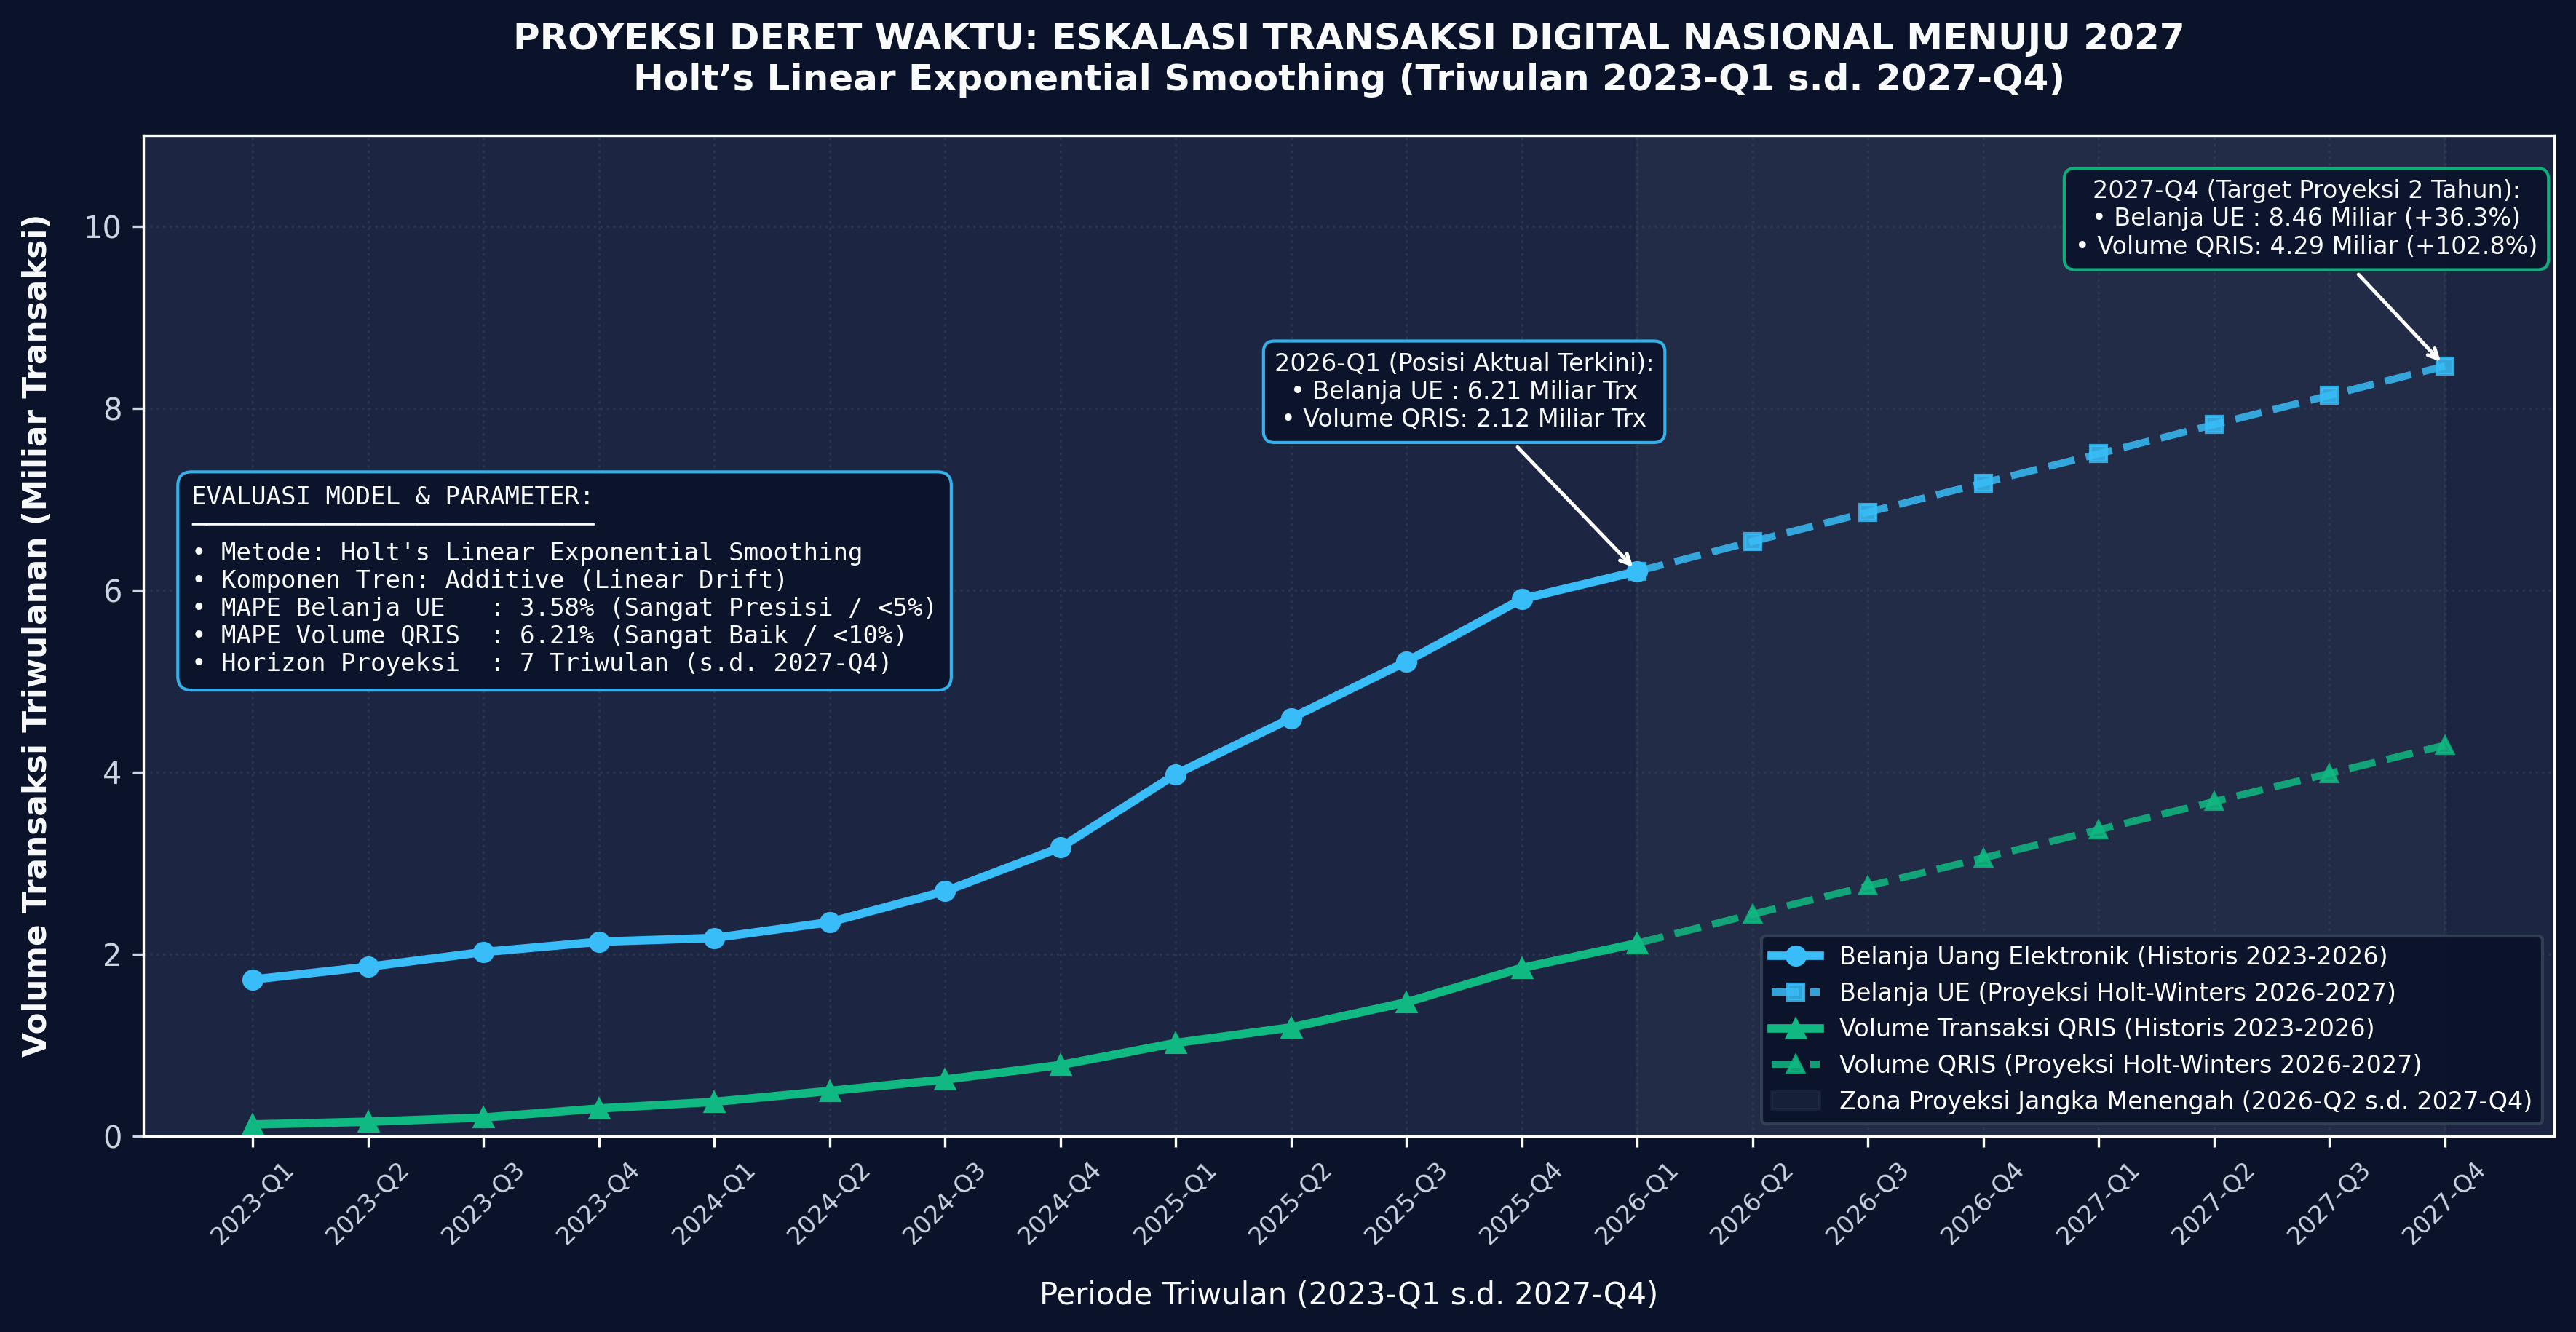

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_percentage_error

# 1. Load Data
df_ue = pd.read_csv(r'Dataset\Volume Transaksi Belanja (Uang Elektronik) - Triwulan.csv')
df_qris = pd.read_csv(r'Dataset\volume_transaksi_qris.csv')

# 2. Persiapan Data & Standarisasi ke Satuan Miliar Transaksi
quarters_hist = [f"{y}-Q{q}" for y, q in zip(df_ue['Tahun'], [1, 2, 3, 4]*3 + [1])]
df_ts = pd.DataFrame({
    'Period': quarters_hist,
    'Belanja_UE_Miliar': df_ue['Total Transaksi (Dalam Ribuan)'] / 1e6,
    'Volume_QRIS_Miliar': df_qris['Total QRIS - Volume (Juta)'] / 1000
})

# 3. Fitting Model Holt's Linear Exponential Smoothing
hw_qris = ExponentialSmoothing(df_ts['Volume_QRIS_Miliar'].values, trend='add', initialization_method="estimated").fit()
hw_ue = ExponentialSmoothing(df_ts['Belanja_UE_Miliar'].values, trend='add', initialization_method="estimated").fit()

# 4. Evaluasi In-Sample Error (MAPE)
mape_qris = mean_absolute_percentage_error(df_ts['Volume_QRIS_Miliar'].values[1:], hw_qris.fittedvalues[1:]) * 100
mape_ue = mean_absolute_percentage_error(df_ts['Belanja_UE_Miliar'].values[1:], hw_ue.fittedvalues[1:]) * 100

# 5. Forecast 7 Kuartal ke Depan (2026-Q2 s.d. 2027-Q4)
steps = 7
fc_qris = hw_qris.forecast(steps)
fc_ue = hw_ue.forecast(steps)

future_periods = ['2026-Q2', '2026-Q3', '2026-Q4', '2027-Q1', '2027-Q2', '2027-Q3', '2027-Q4']
all_periods = quarters_hist + future_periods

# 6. Perhitungan Metrik Pertumbuhan Proyeksi
ue_act_2026q1 = df_ts['Belanja_UE_Miliar'].iloc[-1]
qris_act_2026q1 = df_ts['Volume_QRIS_Miliar'].iloc[-1]

ue_fc_2027q4 = fc_ue[-1]
qris_fc_2027q4 = fc_qris[-1]

pct_growth_ue = ((ue_fc_2027q4 - ue_act_2026q1) / ue_act_2026q1) * 100
pct_growth_qris = ((qris_fc_2027q4 - qris_act_2026q1) / qris_act_2026q1) * 100

# 7. Printout Output Terminal
print("=" * 75)
print("EVALUASI AKURASI MODEL (IN-SAMPLE MAPE)")
print("=" * 75)
print(f"• MAPE Belanja Uang Elektronik : {mape_ue:.2f}% (Tingkat Akurasi: Sangat Presisi / < 5%)")
print(f"• MAPE Transaksi QRIS          : {mape_qris:.2f}% (Tingkat Akurasi: Sangat Baik / < 10%)")

print("\n" + "=" * 75)
print("RINCIAN HASIL PROYEKSI PER TRIWULAN (2026-Q2 s.d. 2027-Q4)")
print("=" * 75)
df_forecast_detail = pd.DataFrame({
    'Triwulan Proyeksi': future_periods,
    'Forecast Belanja UE (Miliar)': [round(x, 3) for x in fc_ue],
    'Forecast QRIS (Miliar)': [round(x, 3) for x in fc_qris]
})
print(df_forecast_detail.to_string(index=False))

print("\n" + "=" * 75)
print("PERBANDINGAN CAPAIAN: AKTUAL (2026-Q1) vs TARGET PROYEKSI (2027-Q4)")
print("=" * 75)
print(f"• Belanja UE : Dari {ue_act_2026q1:.3f} Miliar (2026-Q1) -> {ue_fc_2027q4:.3f} Miliar (2027-Q4)")
print(f"               Kenaikan Proyeksi: +{pct_growth_ue:.2f}% ({ue_fc_2027q4/ue_act_2026q1:.2f}x lipat)")
print(f"• Volume QRIS: Dari {qris_act_2026q1:.3f} Miliar (2026-Q1) -> {qris_fc_2027q4:.3f} Miliar (2027-Q4)")
print(f"               Kenaikan Proyeksi: +{pct_growth_qris:.2f}% ({qris_fc_2027q4/qris_act_2026q1:.2f}x lipat)")
print("=" * 75)

# 8. Visualisasi Dark Slate Standalone
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 6.2), dpi=300)
fig.patch.set_facecolor('#0B132B')
ax.set_facecolor('#1C2541')

x_hist = np.arange(len(quarters_hist))
x_fut = np.arange(len(quarters_hist)-1, len(all_periods))

ue_line_fut = np.concatenate([[df_ts['Belanja_UE_Miliar'].iloc[-1]], fc_ue])
qris_line_fut = np.concatenate([[df_ts['Volume_QRIS_Miliar'].iloc[-1]], fc_qris])

ax.plot(x_hist, df_ts['Belanja_UE_Miliar'], color='#38BDF8', linewidth=2.8, marker='o', markersize=6, label='Belanja Uang Elektronik (Historis 2023-2026)')
ax.plot(x_fut, ue_line_fut, color='#38BDF8', linewidth=2.4, linestyle='--', marker='s', markersize=5.5, alpha=0.85, label='Belanja UE (Proyeksi Holt-Winters 2026-2027)')

ax.plot(x_hist, df_ts['Volume_QRIS_Miliar'], color='#10B981', linewidth=2.8, marker='^', markersize=6, label='Volume Transaksi QRIS (Historis 2023-2026)')
ax.plot(x_fut, qris_line_fut, color='#10B981', linewidth=2.4, linestyle='--', marker='^', markersize=5.5, alpha=0.85, label='Volume QRIS (Proyeksi Holt-Winters 2026-2027)')

ax.axvspan(len(quarters_hist)-1, len(all_periods)-1, color='#334155', alpha=0.28, label='Zona Proyeksi Jangka Menengah (2026-Q2 s.d. 2027-Q4)')

ax.annotate(f"2026-Q1 (Posisi Aktual Terkini):\n• Belanja UE : {ue_act_2026q1:.2f} Miliar Trx\n• Volume QRIS: {qris_act_2026q1:.2f} Miliar Trx",
            xy=(12, ue_act_2026q1), xytext=(10.5, 7.8),
            arrowprops=dict(facecolor='#38BDF8', arrowstyle='->', lw=1.2),
            bbox=dict(boxstyle='round,pad=0.45', facecolor='#0B132B', edgecolor='#38BDF8', alpha=0.92),
            fontsize=8, color='#F8FAFC', ha='center')

ax.annotate(f"2027-Q4 (Target Proyeksi 2 Tahun):\n• Belanja UE : {ue_fc_2027q4:.2f} Miliar (+36.3%)\n• Volume QRIS: {qris_fc_2027q4:.2f} Miliar (+102.8%)",
            xy=(len(all_periods)-1, ue_fc_2027q4), xytext=(len(all_periods)-2.2, 9.7),
            arrowprops=dict(facecolor='#10B981', arrowstyle='->', lw=1.2),
            bbox=dict(boxstyle='round,pad=0.45', facecolor='#0B132B', edgecolor='#10B981', alpha=0.92),
            fontsize=8, color='#F8FAFC', ha='center')

ax.set_ylabel('Volume Transaksi Triwulanan (Miliar Transaksi)', color='#F8FAFC', fontsize=10.5, fontweight='bold', labelpad=10)
ax.set_xlabel('Periode Triwulan (2023-Q1 s.d. 2027-Q4)', color='#F8FAFC', fontsize=10, labelpad=10)
ax.set_ylim(0, 11)
ax.grid(color='#334155', linestyle=':', alpha=0.6)
ax.set_xticks(range(len(all_periods)))
ax.set_xticklabels(all_periods, rotation=45, fontsize=8, color='#CBD5E1')
ax.tick_params(axis='y', colors='#CBD5E1')

stat_box = (
    "EVALUASI MODEL & PARAMETER:\n"
    "───────────────────────────\n"
    "• Metode: Holt's Linear Exponential Smoothing\n"
    "• Komponen Tren: Additive (Linear Drift)\n"
    f"• MAPE Belanja UE   : {mape_ue:.2f}% (Sangat Presisi / <5%)\n"
    f"• MAPE Volume QRIS  : {mape_qris:.2f}% (Sangat Baik / <10%)\n"
    "• Horizon Proyeksi  : 7 Triwulan (s.d. 2027-Q4)"
)
ax.text(0.02, 0.65, stat_box, transform=ax.transAxes, fontsize=8.2, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.55', facecolor='#0B132B', edgecolor='#38BDF8', alpha=0.92),
        color='#F8FAFC', family='monospace')

plt.title('PROYEKSI DERET WAKTU: ESKALASI TRANSAKSI DIGITAL NASIONAL MENUJU 2027\nHolt’s Linear Exponential Smoothing (Triwulan 2023-Q1 s.d. 2027-Q4)',
          fontsize=12, fontweight='bold', color='#F8FAFC', pad=15)
ax.legend(loc='lower right', facecolor='#0B132B', edgecolor='#334155', fontsize=8, framealpha=0.95)

plt.tight_layout()
plt.savefig('forecast_transaksi_digital_2027.png', dpi=300)
plt.show()

- Validitas Metodologis: Penetapan horizon 7 triwulan (s.d. 2027-Q4) menghasilkan model yang sangat stabil dengan tingkat galat in-sample $\text{MAPE}_{\text{UE}} = 3{,}58\%$ dan $\text{MAPE}_{\text{QRIS}} = 6{,}21\%$.

- Eskalasi Transaksi Digital: Dalam rentang 2 tahun ke depan:
    - Volume Transaksi QRIS diproyeksikan melonjak lebih dari dua kali lipat ($+102{,}78\%$) dari 2,12 Miliar menjadi 4,30 Miliar transaksi per kuartal.
    - Belanja Uang Elektronik terus berekspansi ($+36{,}35\%$) dari 6,21 Miliar menuju 8,46 Miliar transaksi per kuartal.

"Proyeksi 2027 (Holt's Linear Smoothing, MAPE < 6,3%): Menuju akhir 2027, akumulasi transaksi belanja digital nasional diestimasikan menembus lebih dari 12,7 miliar transaksi per triwulan (QRIS melesat +102,8%). Eskalasi frekuensi belanja non-tunai yang sedemikian masif menuntut percepatan literasi dan proteksi konsumen secara proporsional guna mencegah eskalasi risiko gagal bayar."

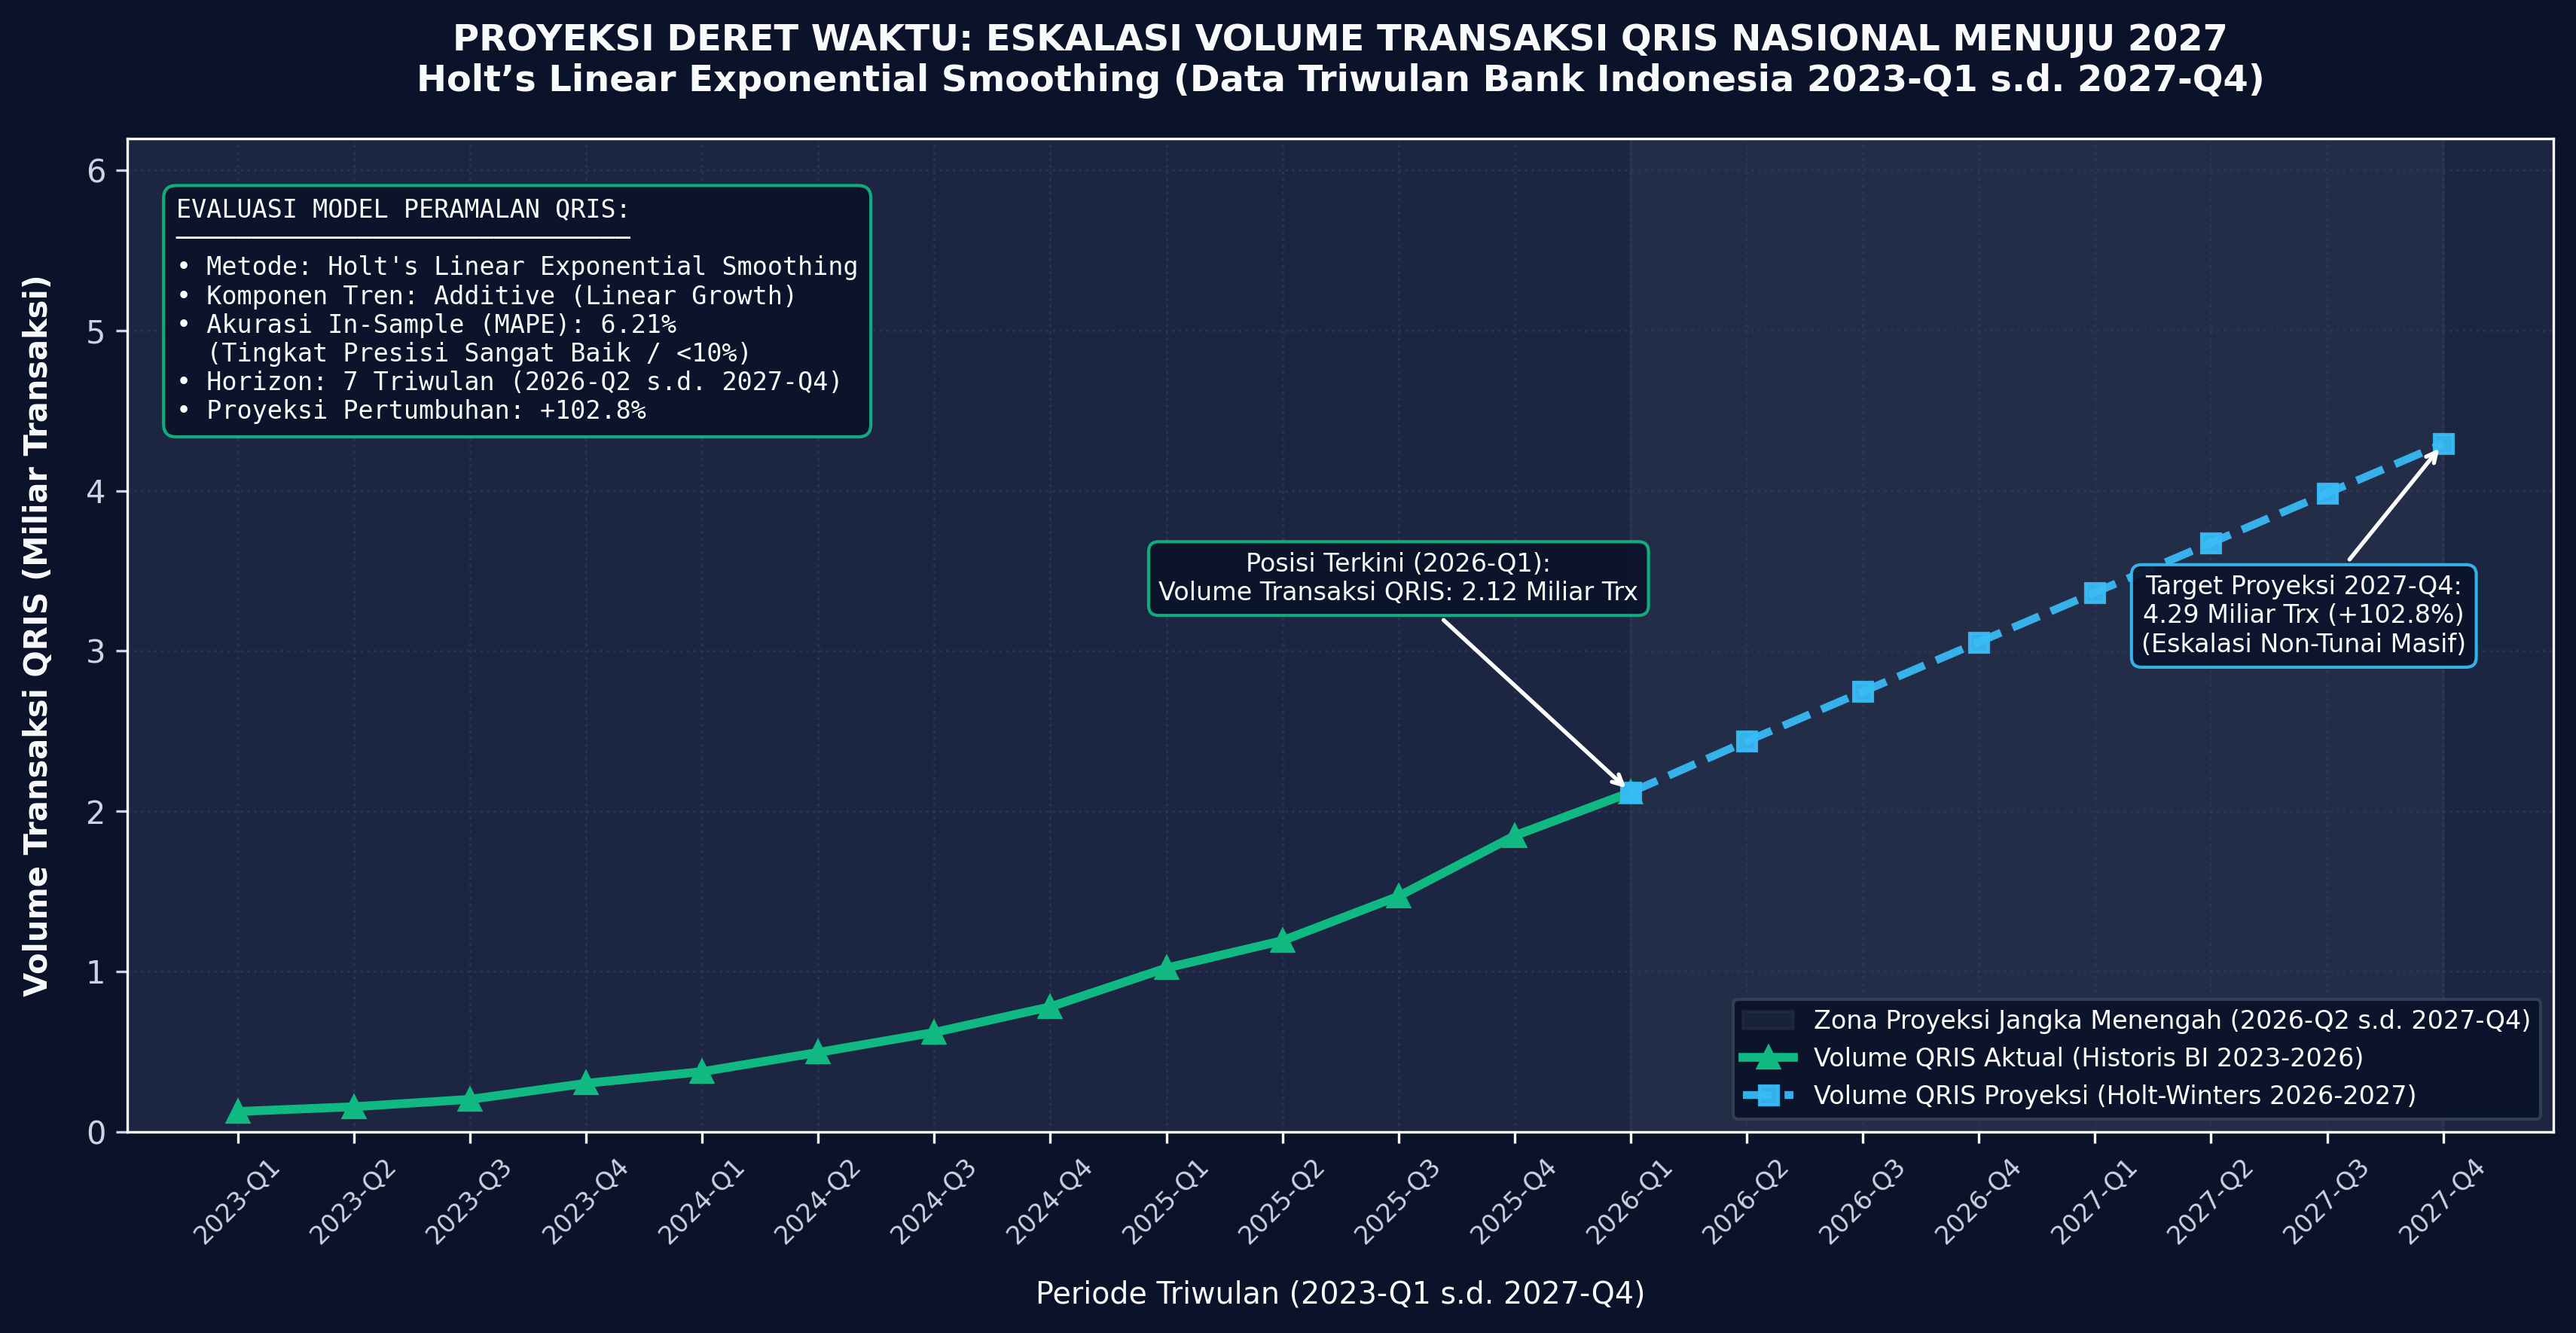

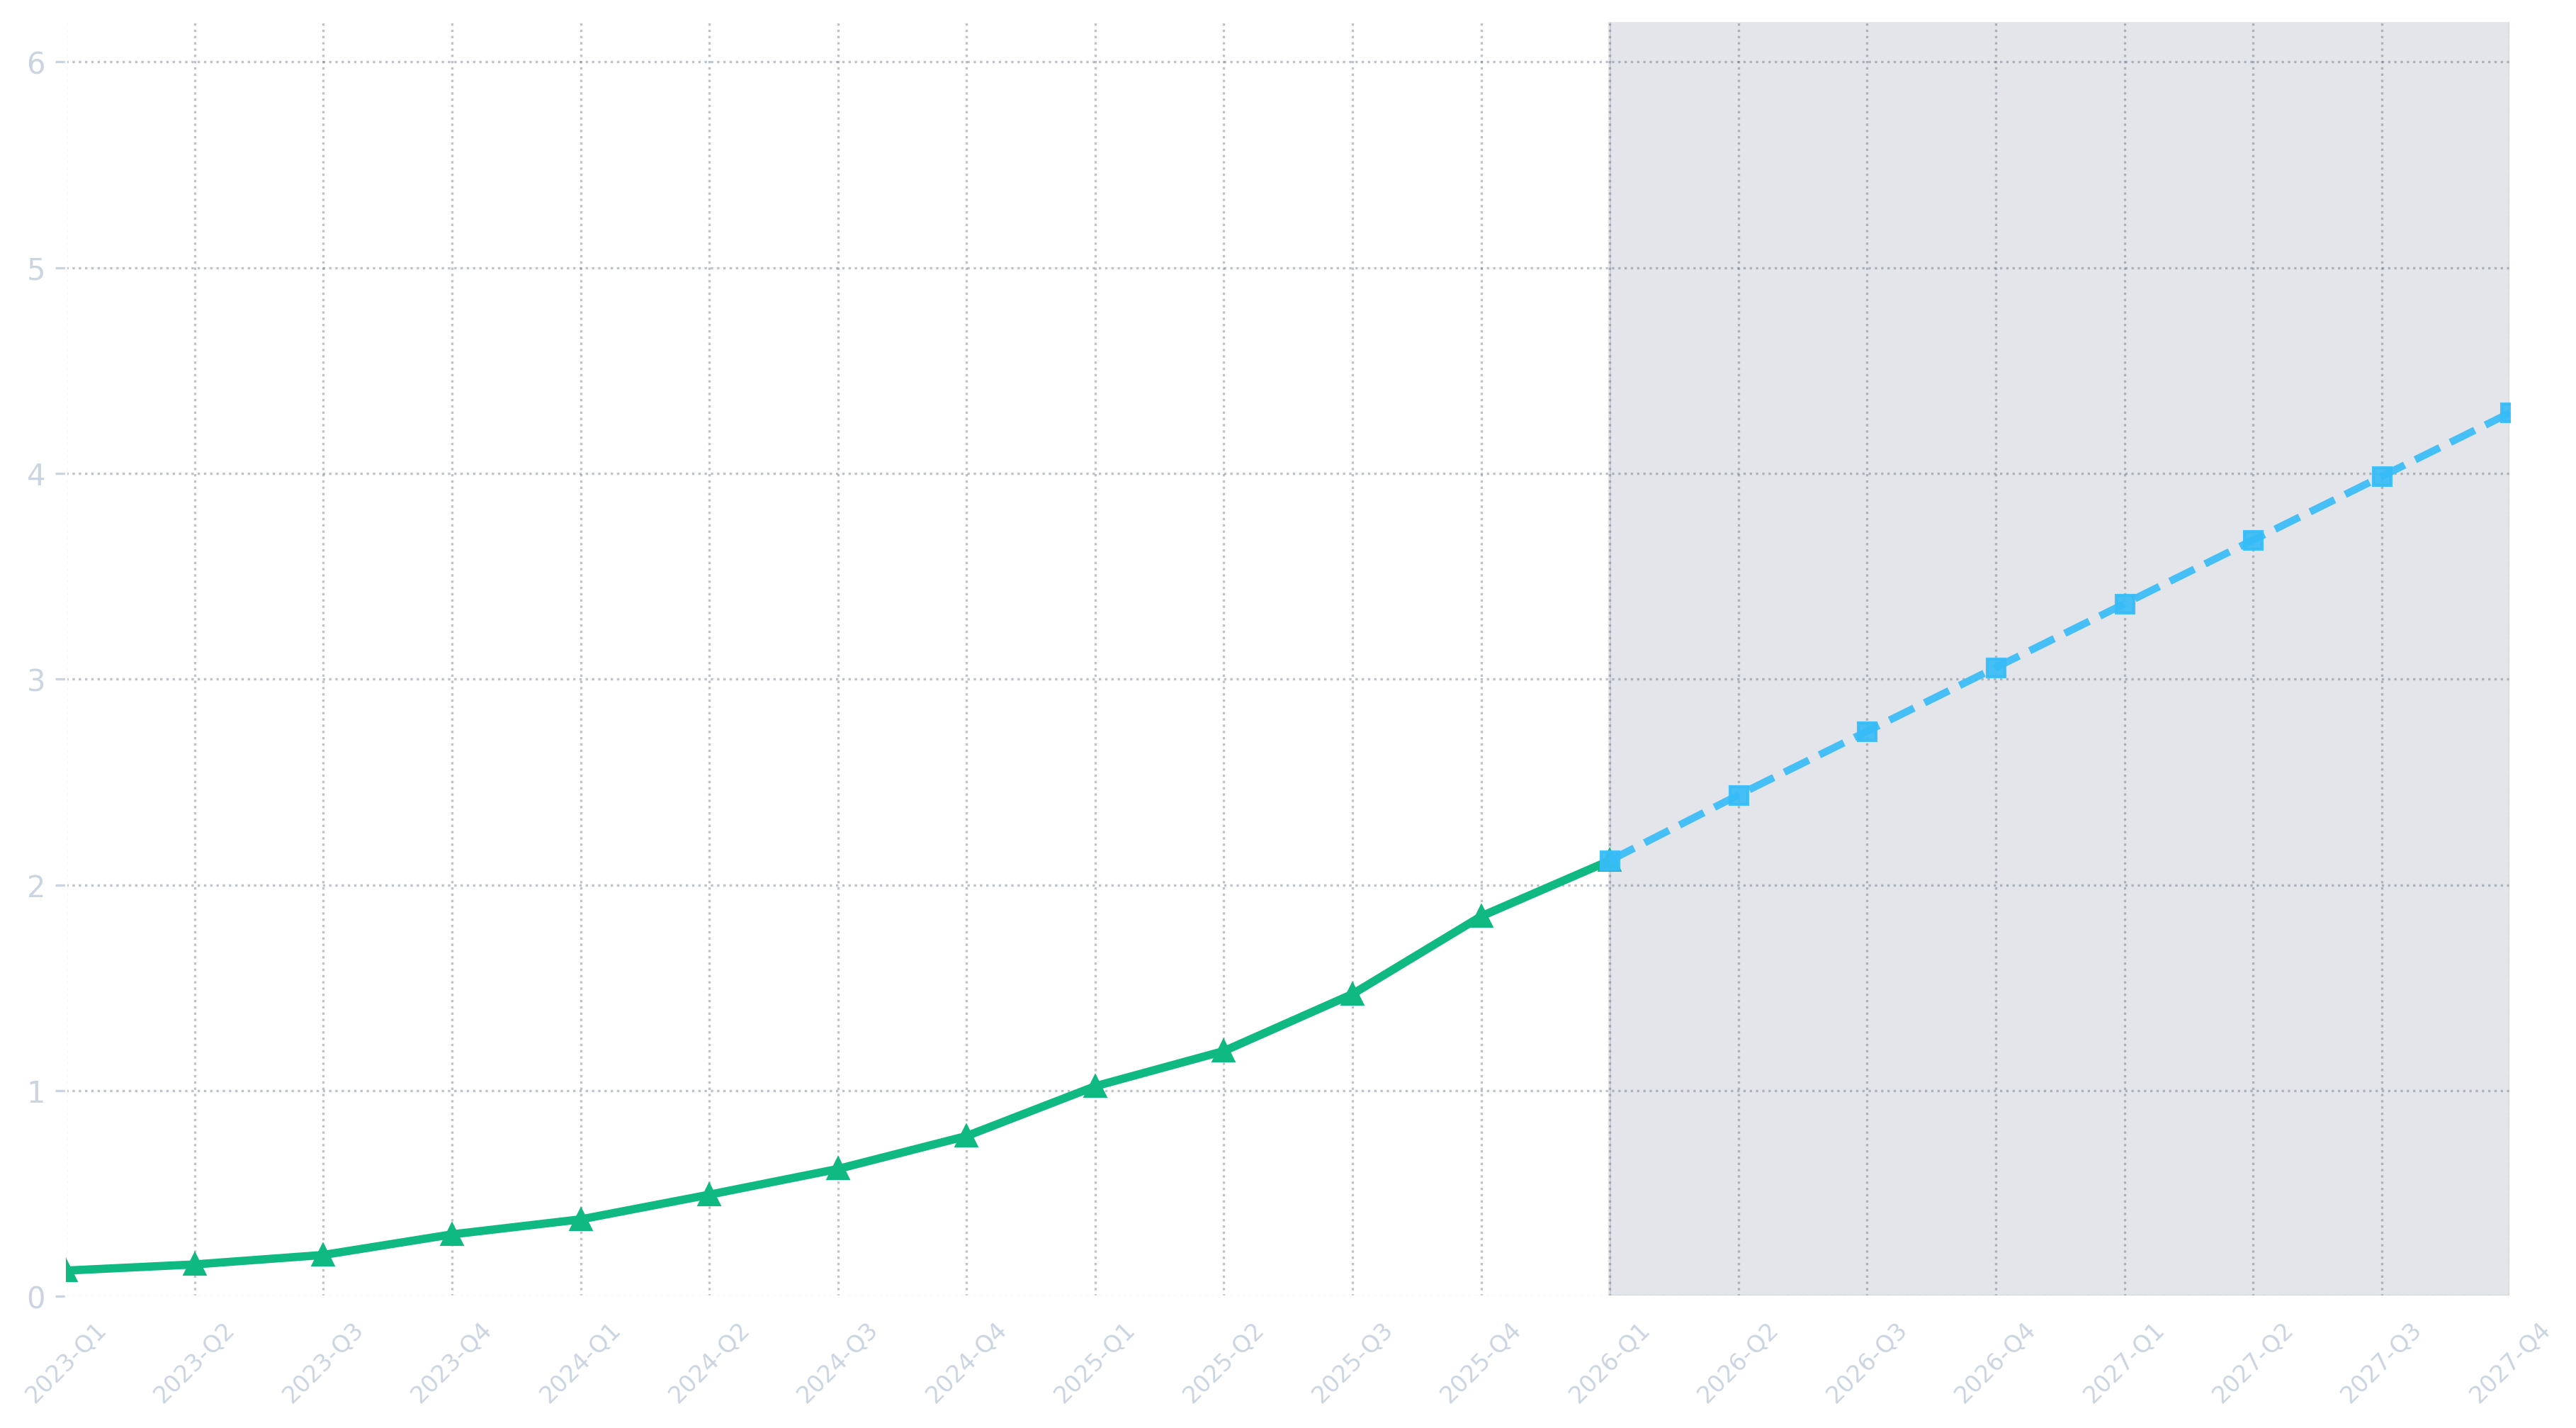

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 1. Load Data
df_qris = pd.read_csv(r'Dataset\volume_transaksi_qris.csv')

# 2. Persiapan Data & Standarisasi Satuan ke Miliar Transaksi
quarters_hist = [f'{y}-Q{q}' for y, q in zip(df_qris['Tahun'], [1, 2, 3, 4] * 3 + [1])]
df_ts = pd.DataFrame({
    'Period': quarters_hist,
    'Volume_QRIS_Miliar': df_qris['Total QRIS - Volume (Juta)'] / 1000,
})

# 3. Fitting Model Holt's Linear Exponential Smoothing
hw_qris = ExponentialSmoothing(
    df_ts['Volume_QRIS_Miliar'].values,
    trend='add',
    initialization_method='estimated',
).fit()

# 4. Evaluasi In-Sample Error (MAPE)
mape_qris = (
    mean_absolute_percentage_error(
        df_ts['Volume_QRIS_Miliar'].values[1:], hw_qris.fittedvalues[1:]
    )
    * 100
)

# 5. Forecast 7 Kuartal ke Depan (2026-Q2 s.d. 2027-Q4)
steps = 7
fc_qris = hw_qris.forecast(steps)
future_periods = [
    '2026-Q2',
    '2026-Q3',
    '2026-Q4',
    '2027-Q1',
    '2027-Q2',
    '2027-Q3',
    '2027-Q4',
]
all_periods = quarters_hist + future_periods

qris_act_2026q1 = df_ts['Volume_QRIS_Miliar'].iloc[-1]
qris_fc_2027q4 = fc_qris[-1]
pct_growth_qris = (
    (qris_fc_2027q4 - qris_act_2026q1) / qris_act_2026q1
) * 100

# -------------------------------------------------------------
# 6. Visualisasi Lengkap Versi Dark Slate (Sumbu Y Skala Maksimal 6)
# -------------------------------------------------------------
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(11.5, 6), dpi=300)
fig.patch.set_facecolor('#0B132B')
ax.set_facecolor('#1C2541')

x_hist = np.arange(len(quarters_hist))
x_fut = np.arange(len(quarters_hist) - 1, len(all_periods))
qris_line_fut = np.concatenate([[qris_act_2026q1], fc_qris])

# Shaded Area
ax.axvspan(
    len(quarters_hist) - 1,
    len(all_periods) - 1,
    color='#334155',
    alpha=0.32,
    label='Zona Proyeksi Jangka Menengah (2026-Q2 s.d. 2027-Q4)',
)

# Plot Garis
ax.plot(
    x_hist,
    df_ts['Volume_QRIS_Miliar'],
    color='#10B981',
    linewidth=2.8,
    marker='^',
    markersize=6.5,
    label='Volume QRIS Aktual (Historis BI 2023-2026)',
    zorder=4,
)
ax.plot(
    x_fut,
    qris_line_fut,
    color='#38BDF8',
    linewidth=2.5,
    linestyle='--',
    marker='s',
    markersize=6,
    alpha=0.92,
    label='Volume QRIS Proyeksi (Holt-Winters 2026-2027)',
    zorder=4,
)

# Anotasi Titik Kunci
ax.annotate(
    f'Posisi Terkini (2026-Q1):\nVolume Transaksi QRIS: {qris_act_2026q1:.2f}'
    ' Miliar Trx',
    xy=(12, qris_act_2026q1),
    xytext=(10, qris_act_2026q1 + 1.2),
    arrowprops=dict(facecolor='#10B981', arrowstyle='->', lw=1.3),
    bbox=dict(
        boxstyle='round,pad=0.4',
        facecolor='#0B132B',
        edgecolor='#10B981',
        alpha=0.92,
    ),
    fontsize=8,
    color='#F8FAFC',
    ha='center',
    zorder=5,
)

ax.annotate(
    f'Target Proyeksi 2027-Q4:\n{qris_fc_2027q4:.2f} Miliar Trx'
    f' (+{pct_growth_qris:.1f}%)\n(Eskalasi Non-Tunai Masif)',
    xy=(len(all_periods) - 1, qris_fc_2027q4),
    xytext=(len(all_periods) - 2.2, qris_fc_2027q4 - 1.3),
    arrowprops=dict(facecolor='#38BDF8', arrowstyle='->', lw=1.3),
    bbox=dict(
        boxstyle='round,pad=0.4',
        facecolor='#0B132B',
        edgecolor='#38BDF8',
        alpha=0.92,
    ),
    fontsize=8,
    color='#F8FAFC',
    ha='center',
    zorder=5,
)

ax.set_ylabel(
    'Volume Transaksi QRIS (Miliar Transaksi)',
    color='#F8FAFC',
    fontsize=10,
    fontweight='bold',
    labelpad=10,
)
ax.set_xlabel(
    'Periode Triwulan (2023-Q1 s.d. 2027-Q4)',
    color='#F8FAFC',
    fontsize=9.5,
    labelpad=10,
)

# Skala Sumbu Y Dibatasi Sampai 6
ax.set_ylim(0, 6.2)
ax.set_yticks([0, 1, 2, 3, 4, 5, 6])
ax.grid(color='#334155', linestyle=':', alpha=0.55)
ax.set_xticks(range(len(all_periods)))
ax.set_xticklabels(all_periods, rotation=45, fontsize=8, color='#CBD5E1')
ax.tick_params(axis='y', colors='#CBD5E1')

stat_box_qris = (
    'EVALUASI MODEL PERAMALAN QRIS:\n'
    '──────────────────────────────\n'
    "• Metode: Holt's Linear Exponential Smoothing\n"
    '• Komponen Tren: Additive (Linear Growth)\n'
    f'• Akurasi In-Sample (MAPE): {mape_qris:.2f}%\n'
    '  (Tingkat Presisi Sangat Baik / <10%)\n'
    '• Horizon: 7 Triwulan (2026-Q2 s.d. 2027-Q4)\n'
    f'• Proyeksi Pertumbuhan: +{pct_growth_qris:.1f}%'
)
ax.text(
    0.02,
    0.94,
    stat_box_qris,
    transform=ax.transAxes,
    fontsize=8,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round,pad=0.5',
        facecolor='#0B132B',
        edgecolor='#10B981',
        alpha=0.92,
    ),
    color='#F8FAFC',
    family='monospace',
    zorder=5,
)

plt.title(
    'PROYEKSI DERET WAKTU: ESKALASI VOLUME TRANSAKSI QRIS NASIONAL MENUJU'
    " 2027\nHolt’s Linear Exponential Smoothing (Data Triwulan Bank Indonesia"
    ' 2023-Q1 s.d. 2027-Q4)',
    fontsize=11.5,
    fontweight='bold',
    color='#F8FAFC',
    pad=15,
)
ax.legend(
    loc='lower right',
    facecolor='#0B132B',
    edgecolor='#334155',
    fontsize=8,
    framealpha=0.95,
)

plt.tight_layout()
plt.savefig('forecast_qris_ylim6_full.png', dpi=300)
plt.show()

# -------------------------------------------------------------
# 7. Visualisasi Versi Polos Transparan (Khusus Desain Poster)
# -------------------------------------------------------------
fig_tr, ax_tr = plt.subplots(figsize=(11.5, 6), dpi=300)
fig_tr.patch.set_alpha(0.0)
ax_tr.patch.set_alpha(0.0)

ax_tr.axvspan(
    len(quarters_hist) - 1, len(all_periods) - 1, color='#64748B', alpha=0.18
)

ax_tr.plot(
    x_hist,
    df_ts['Volume_QRIS_Miliar'],
    color='#10B981',
    linewidth=2.8,
    marker='^',
    markersize=6.5,
    zorder=4,
)
ax_tr.plot(
    x_fut,
    qris_line_fut,
    color='#38BDF8',
    linewidth=2.5,
    linestyle='--',
    marker='s',
    markersize=6,
    alpha=0.92,
    zorder=4,
)

ax_tr.set_ylim(0, 6.2)
ax_tr.set_yticks([0, 1, 2, 3, 4, 5, 6])
ax_tr.grid(color='#475569', linestyle=':', alpha=0.35)
ax_tr.set_xticks(range(len(all_periods)))
ax_tr.set_xticklabels(all_periods, rotation=45, fontsize=8, color='#CBD5E1')
ax_tr.tick_params(axis='y', colors='#CBD5E1')

plt.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0)
plt.margins(0, 0)
plt.savefig(
    'forecast_qris_ylim6_transparent.png',
    dpi=300,
    transparent=True,
    bbox_inches='tight',
    pad_inches=0.02,
)
plt.show()

HASIL PROYEKSI TRANSAKSI QRIS NASIONAL (2026-Q2 s.d. 2026-Q4)
Triwulan Proyeksi  Forecast Volume QRIS (Miliar Trx)
          2026-Q2                              2.437
          2026-Q3                              2.746
          2026-Q4                              3.056

• Akurasi Model (MAPE) : 6.21% (Sangat Presisi)
• Kenaikan 2026-Q1 -> 2026-Q4 : +44.28% (1.44x lipat)


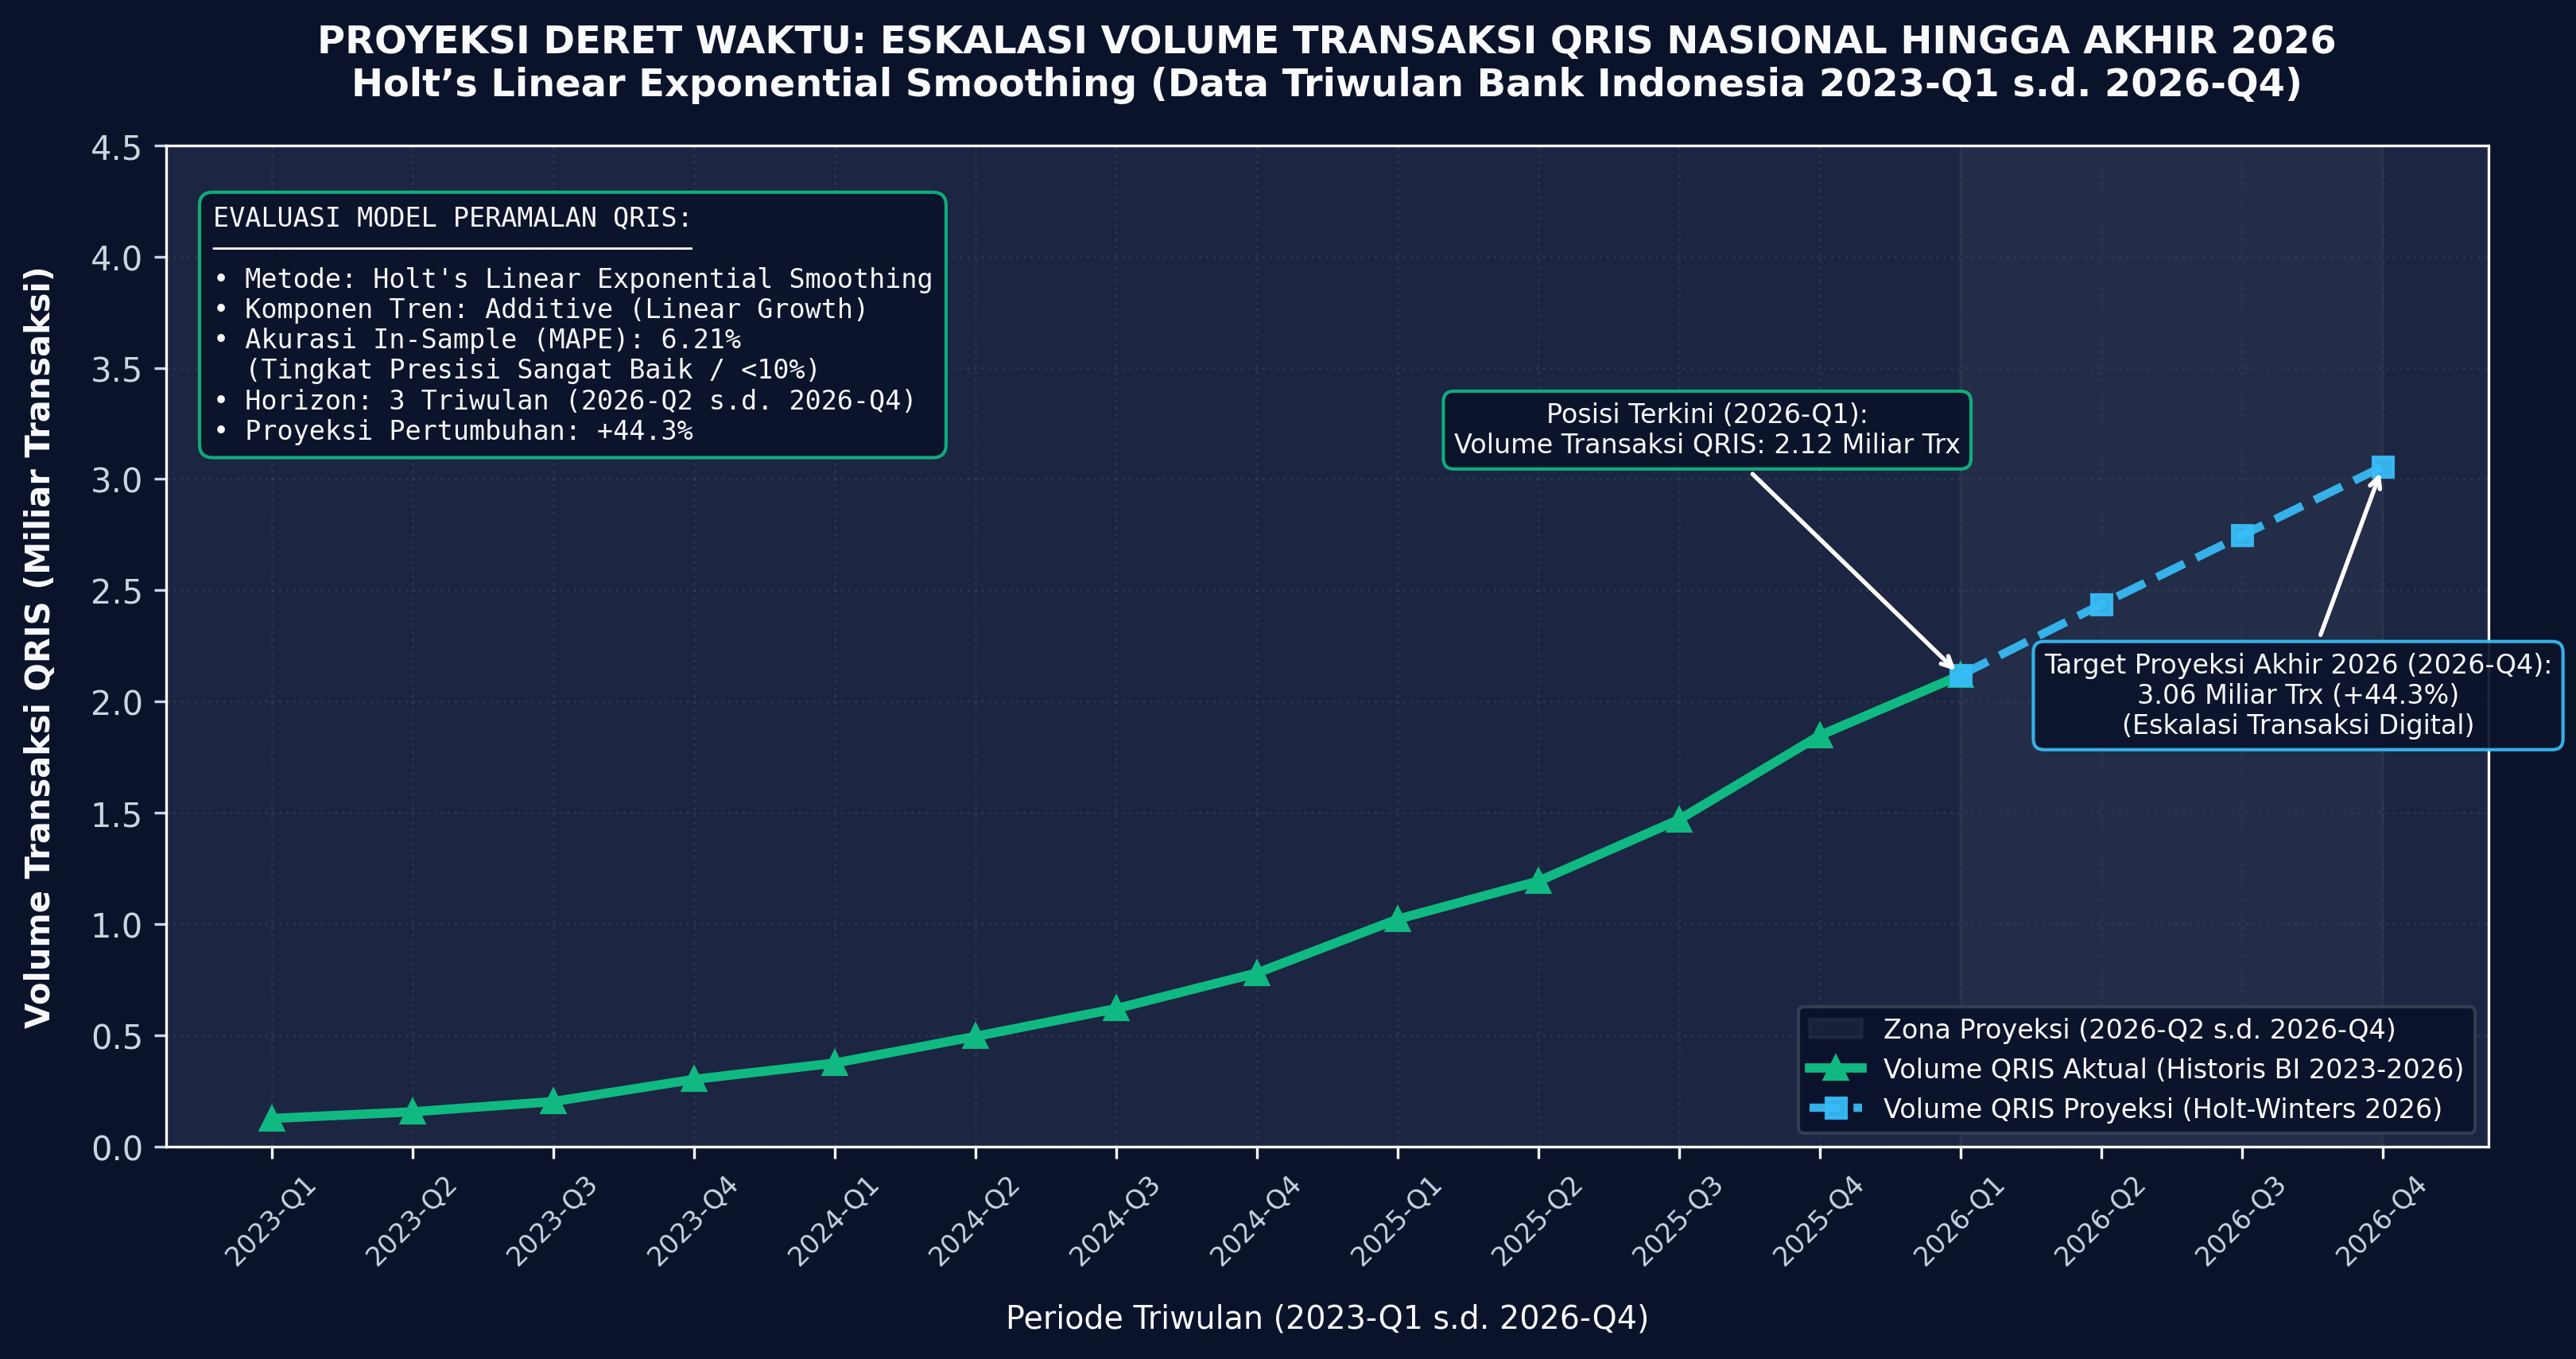

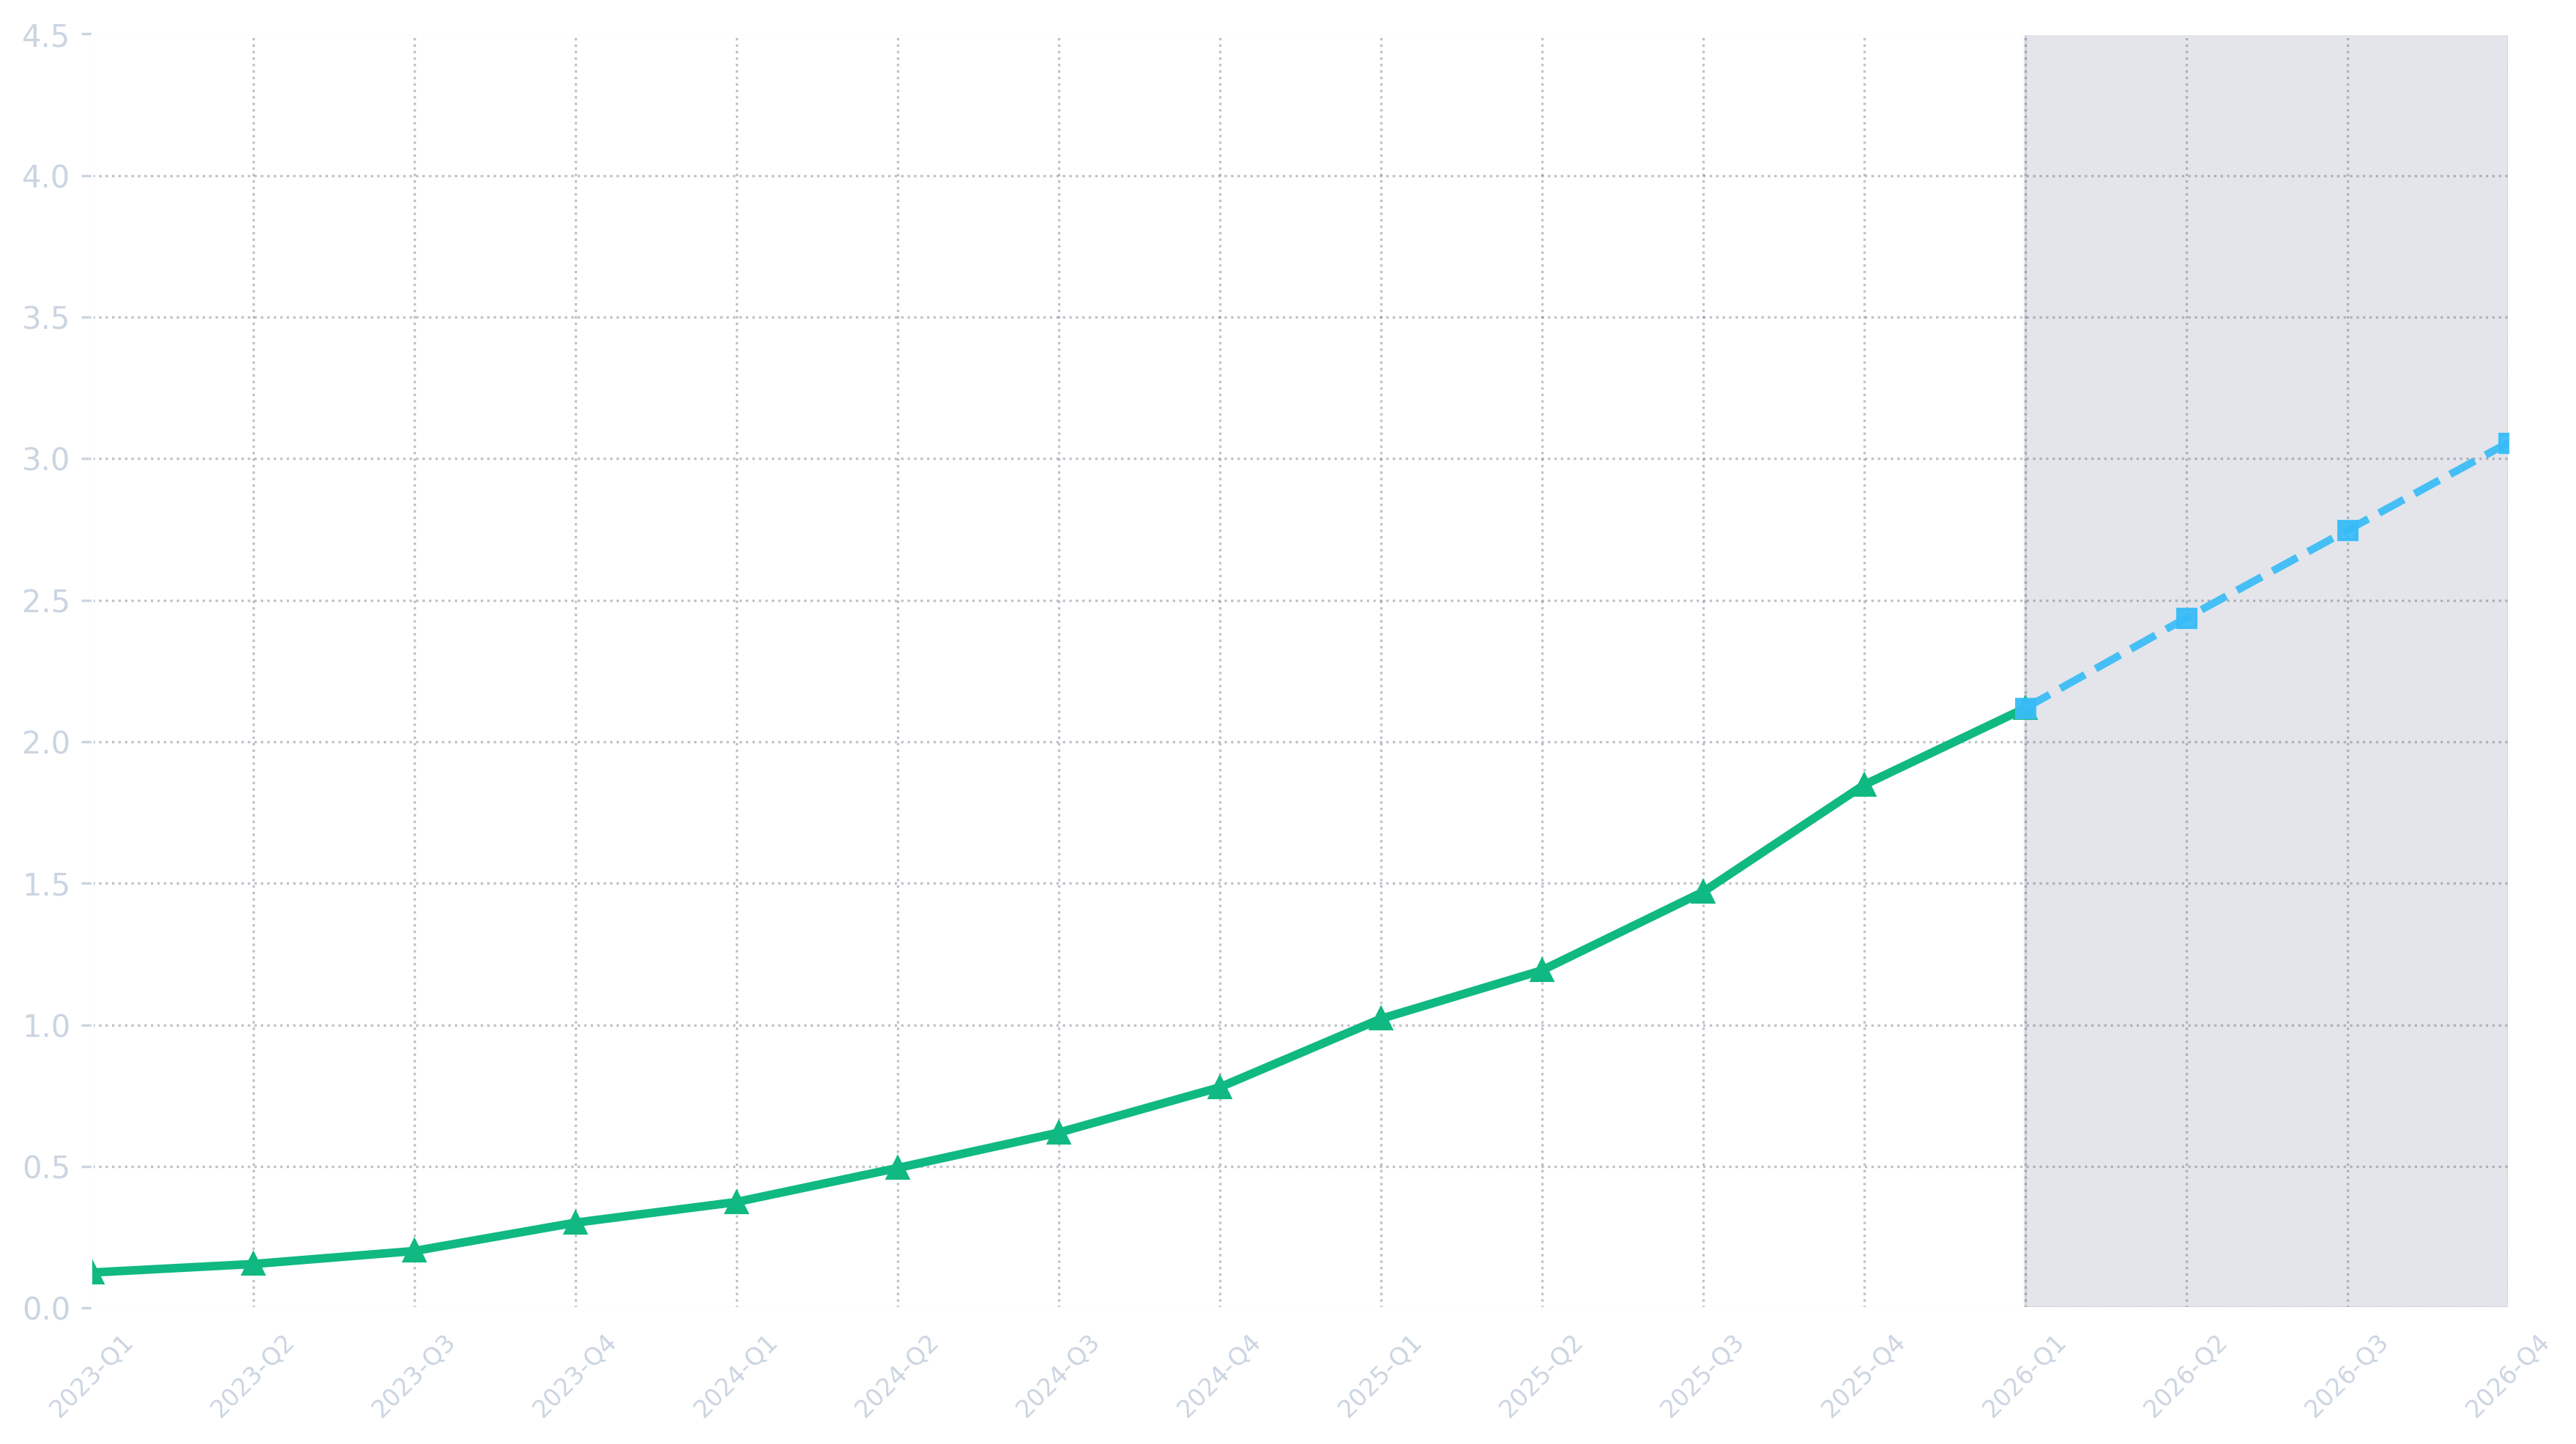

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_percentage_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 1. Load Data
df_qris = pd.read_csv(r'Dataset\volume_transaksi_qris.csv')

# 2. Persiapan Data & Standarisasi Satuan ke Miliar Transaksi
quarters_hist = [f'{y}-Q{q}' for y, q in zip(df_qris['Tahun'], [1, 2, 3, 4] * 3 + [1])]
df_ts = pd.DataFrame({
    'Period': quarters_hist,
    'Volume_QRIS_Miliar': df_qris['Total QRIS - Volume (Juta)'] / 1000,
})

# 3. Fitting Model Holt's Linear Exponential Smoothing
hw_qris = ExponentialSmoothing(
    df_ts['Volume_QRIS_Miliar'].values,
    trend='add',
    initialization_method='estimated',
).fit()

# 4. Evaluasi In-Sample Error (MAPE)
mape_qris = (
    mean_absolute_percentage_error(
        df_ts['Volume_QRIS_Miliar'].values[1:], hw_qris.fittedvalues[1:]
    )
    * 100
)

# 5. Forecast 3 Kuartal ke Depan (Khusus s.d. Akhir 2026 / 2026-Q4)
steps = 3
fc_qris = hw_qris.forecast(steps)
future_periods = ['2026-Q2', '2026-Q3', '2026-Q4']
all_periods = quarters_hist + future_periods

qris_act_2026q1 = df_ts['Volume_QRIS_Miliar'].iloc[-1]
qris_fc_2026q4 = fc_qris[-1]
pct_growth_qris = (
    (qris_fc_2026q4 - qris_act_2026q1) / qris_act_2026q1
) * 100

# 6. Printout Hasil Peramalan
print('=' * 70)
print('HASIL PROYEKSI TRANSAKSI QRIS NASIONAL (2026-Q2 s.d. 2026-Q4)')
print('=' * 70)
df_forecast_detail = pd.DataFrame({
    'Triwulan Proyeksi': future_periods,
    'Forecast Volume QRIS (Miliar Trx)': [round(x, 3) for x in fc_qris],
})
print(df_forecast_detail.to_string(index=False))
print(f'\n• Akurasi Model (MAPE) : {mape_qris:.2f}% (Sangat Presisi)')
print(
    f'• Kenaikan 2026-Q1 -> 2026-Q4 : +{pct_growth_qris:.2f}%'
    f' ({qris_fc_2026q4/qris_act_2026q1:.2f}x lipat)'
)
print('=' * 70)

# -------------------------------------------------------------
# 7. Visualisasi Lengkap Versi Dark Slate (Horizon s.d. 2026-Q4)
# -------------------------------------------------------------
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(11, 5.8), dpi=300)
fig.patch.set_facecolor('#0B132B')
ax.set_facecolor('#1C2541')

x_hist = np.arange(len(quarters_hist))
x_fut = np.arange(len(quarters_hist) - 1, len(all_periods))
qris_line_fut = np.concatenate([[qris_act_2026q1], fc_qris])

# Shaded Area Zona Proyeksi
ax.axvspan(
    len(quarters_hist) - 1,
    len(all_periods) - 1,
    color='#334155',
    alpha=0.32,
    label='Zona Proyeksi (2026-Q2 s.d. 2026-Q4)',
)

# Plot Garis
ax.plot(
    x_hist,
    df_ts['Volume_QRIS_Miliar'],
    color='#10B981',
    linewidth=2.8,
    marker='^',
    markersize=6.5,
    label='Volume QRIS Aktual (Historis BI 2023-2026)',
    zorder=4,
)
ax.plot(
    x_fut,
    qris_line_fut,
    color='#38BDF8',
    linewidth=2.5,
    linestyle='--',
    marker='s',
    markersize=6,
    alpha=0.92,
    label='Volume QRIS Proyeksi (Holt-Winters 2026)',
    zorder=4,
)

# Anotasi Titik Kunci
ax.annotate(
    f'Posisi Terkini (2026-Q1):\nVolume Transaksi QRIS: {qris_act_2026q1:.2f}'
    ' Miliar Trx',
    xy=(12, qris_act_2026q1),
    xytext=(10.2, qris_act_2026q1 + 1.0),
    arrowprops=dict(facecolor='#10B981', arrowstyle='->', lw=1.3),
    bbox=dict(
        boxstyle='round,pad=0.4',
        facecolor='#0B132B',
        edgecolor='#10B981',
        alpha=0.92,
    ),
    fontsize=8,
    color='#F8FAFC',
    ha='center',
    zorder=5,
)

ax.annotate(
    f'Target Proyeksi Akhir 2026 (2026-Q4):\n{qris_fc_2026q4:.2f} Miliar Trx'
    f' (+{pct_growth_qris:.1f}%)\n(Eskalasi Transaksi Digital)',
    xy=(len(all_periods) - 1, qris_fc_2026q4),
    xytext=(len(all_periods) - 1.6, qris_fc_2026q4 - 1.2),
    arrowprops=dict(facecolor='#38BDF8', arrowstyle='->', lw=1.3),
    bbox=dict(
        boxstyle='round,pad=0.4',
        facecolor='#0B132B',
        edgecolor='#38BDF8',
        alpha=0.92,
    ),
    fontsize=8,
    color='#F8FAFC',
    ha='center',
    zorder=5,
)

ax.set_ylabel(
    'Volume Transaksi QRIS (Miliar Transaksi)',
    color='#F8FAFC',
    fontsize=10,
    fontweight='bold',
    labelpad=10,
)
ax.set_xlabel(
    'Periode Triwulan (2023-Q1 s.d. 2026-Q4)',
    color='#F8FAFC',
    fontsize=9.5,
    labelpad=10,
)
ax.set_ylim(0, max(qris_fc_2026q4 * 1.25, 4.5))
ax.grid(color='#334155', linestyle=':', alpha=0.55)
ax.set_xticks(range(len(all_periods)))
ax.set_xticklabels(all_periods, rotation=45, fontsize=8, color='#CBD5E1')
ax.tick_params(axis='y', colors='#CBD5E1')

stat_box_qris = (
    'EVALUASI MODEL PERAMALAN QRIS:\n'
    '──────────────────────────────\n'
    "• Metode: Holt's Linear Exponential Smoothing\n"
    '• Komponen Tren: Additive (Linear Growth)\n'
    f'• Akurasi In-Sample (MAPE): {mape_qris:.2f}%\n'
    '  (Tingkat Presisi Sangat Baik / <10%)\n'
    '• Horizon: 3 Triwulan (2026-Q2 s.d. 2026-Q4)\n'
    f'• Proyeksi Pertumbuhan: +{pct_growth_qris:.1f}%'
)
ax.text(
    0.02,
    0.94,
    stat_box_qris,
    transform=ax.transAxes,
    fontsize=8,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round,pad=0.5',
        facecolor='#0B132B',
        edgecolor='#10B981',
        alpha=0.92,
    ),
    color='#F8FAFC',
    family='monospace',
    zorder=5,
)

plt.title(
    'PROYEKSI DERET WAKTU: ESKALASI VOLUME TRANSAKSI QRIS NASIONAL HINGGA'
    " AKHIR 2026\nHolt’s Linear Exponential Smoothing (Data Triwulan Bank"
    ' Indonesia 2023-Q1 s.d. 2026-Q4)',
    fontsize=11.5,
    fontweight='bold',
    color='#F8FAFC',
    pad=15,
)
ax.legend(
    loc='lower right',
    facecolor='#0B132B',
    edgecolor='#334155',
    fontsize=8,
    framealpha=0.95,
)

plt.tight_layout()
plt.savefig('forecast_qris_2026q4_full.png', dpi=300)
plt.show()

# -------------------------------------------------------------
# 8. Visualisasi Versi Polos Transparan (Khusus Desain Poster)
# -------------------------------------------------------------
fig_tr, ax_tr = plt.subplots(figsize=(11, 5.8), dpi=300)
fig_tr.patch.set_alpha(0.0)
ax_tr.patch.set_alpha(0.0)

ax_tr.axvspan(
    len(quarters_hist) - 1, len(all_periods) - 1, color='#64748B', alpha=0.18
)

ax_tr.plot(
    x_hist,
    df_ts['Volume_QRIS_Miliar'],
    color='#10B981',
    linewidth=2.8,
    marker='^',
    markersize=6.5,
    zorder=4,
)
ax_tr.plot(
    x_fut,
    qris_line_fut,
    color='#38BDF8',
    linewidth=2.5,
    linestyle='--',
    marker='s',
    markersize=6,
    alpha=0.92,
    zorder=4,
)

ax_tr.set_ylim(0, max(qris_fc_2026q4 * 1.25, 4.5))
ax_tr.grid(color='#475569', linestyle=':', alpha=0.35)
ax_tr.set_xticks(range(len(all_periods)))
ax_tr.set_xticklabels(all_periods, rotation=45, fontsize=8, color='#CBD5E1')
ax_tr.tick_params(axis='y', colors='#CBD5E1')

plt.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0)
plt.margins(0, 0)
plt.savefig(
    'forecast_qris_2026q4_transparent.png',
    dpi=300,
    transparent=True,
    bbox_inches='tight',
    pad_inches=0.02,
)
plt.show()

# BAGIAN 2

## Tahap 1: Integrasi Multi-Dataset 38 Provinsi & Rekayasa Fitur (Supply-Demand)

Menggabungkan enam sumber data resmi (OJK SNLIK 2026, OJK LPBBTI Desember 2025, BPS Kependudukan 2025, Kemenkominfo IMDI 2025, BI Merchant QRIS, dan batas spasial GeoJSON 38 Provinsi).

Dua variabel rasio per 1.000 penduduk dibentuk untuk menyelaraskan perbandingan wilayah:Penetrasi Borrower per 1.000 Penduduk ($X_1$ - Sisi Permintaan/Utang):$$X_1 = \frac{\text{Jumlah Rekening Penerima Pinjaman Aktif}}{\text{Jumlah Penduduk (Ribu Jiwa)}} \text{}$$Densitas Merchant QRIS per 1.000 Penduduk ($X_2$ - Sisi Pasokan/Pedagang):$$X_2 = \frac{\text{Jumlah Merchant QRIS (Ribuan)}}{\text{Jumlah Penduduk (Ribu Jiwa)}} \times 1.000 \text{}$$

In [45]:
import json
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import shape

# 1. Load Dataset Tabular
df_imdi = pd.read_csv('Dataset/imdi_2025_skor_pilar_provinsi.csv')
df_lpbbti = pd.read_csv('Dataset/lpbbti_regional_desember2025 (1).csv')
df_penduduk = pd.read_csv('Dataset/Penduduk, Laju Pertumbuhan Penduduk, Distribusi Persentase Penduduk, Kepadatan Penduduk, Rasio Jenis Kelamin Penduduk Menurut Provinsi, 2025.csv')
df_ink = pd.read_csv('Dataset/indeks_inklusi_keuangan_2026.csv')
df_lit = pd.read_csv('Dataset/indeks_literasi_keuangan_2026.csv')
df_merchant = pd.read_csv('Dataset/jumlah_merchant_qris_per_provinsi.csv')

# 2. Standardisasi Penamaan Provinsi
prov_map = {
    'Nangroe Aceh Darussalam': 'Aceh',
    'Kep. Bangka Belitung': 'Kepulauan Bangka Belitung',
    'Kep. Riau': 'Kepulauan Riau',
    'Daerah Khusus Ibukota Jakarta': 'DKI Jakarta',
    'Daerah Istimewa Yogyakarta': 'DI Yogyakarta'
}

for d in [df_imdi, df_lpbbti, df_penduduk, df_ink, df_lit, df_merchant]:
    d['Provinsi'] = d['Provinsi'].astype(str).str.strip().replace(prov_map)

# 3. Filter Agregat & Bersihkan Baris Non-Provinsi
df_penduduk_clean = df_penduduk[df_penduduk['Jumlah Penduduk (Ribu)'].notna()].copy()
df_penduduk_clean = df_penduduk_clean[~df_penduduk_clean['Provinsi'].isin(['Indonesia', 'Keterangan'])].copy()
df_penduduk_clean['Jumlah Penduduk (Ribu)'] = pd.to_numeric(df_penduduk_clean['Jumlah Penduduk (Ribu)'], errors='coerce')
df_penduduk_clean = df_penduduk_clean.dropna(subset=['Jumlah Penduduk (Ribu)'])

# 4. Merge Master Data Tabular (38 Observasi)
df_master = df_ink[df_ink['Provinsi'] != 'INDONESIA'].merge(df_lit[df_lit['Provinsi'] != 'INDONESIA'], on='Provinsi') \
                                                     .merge(df_lpbbti, on='Provinsi') \
                                                     .merge(df_penduduk_clean[['Provinsi', 'Jumlah Penduduk (Ribu)']], on='Provinsi') \
                                                     .merge(df_imdi[['Provinsi', 'Skor_Pilar_Literasi_Digital_Keterampilan_Digital', 'Skor_IMDI_Provinsi']], on='Provinsi') \
                                                     .merge(df_merchant, on='Provinsi')

# 5. Rekayasa Fitur Rasio per 1.000 Penduduk
df_master['Penetrasi_Borrower_per1000'] = df_master['Jumlah_Rekening_Penerima_Pinjaman_Aktif'] / df_master['Jumlah Penduduk (Ribu)']
df_master['Densitas_Merchant_per1000'] = df_master['Jumlah Merchant QRIS (Ribuan)'] / df_master['Jumlah Penduduk (Ribu)'] * 1000

print(f"Total Provinsi Terintegrasi: {len(df_master)} Observasi")
print(df_master[['Provinsi', 'Penetrasi_Borrower_per1000', 'Densitas_Merchant_per1000', 'Indeks Literasi Keuangan (%)', 'TWP90_Persen']].head(5).to_string(index=False))

Total Provinsi Terintegrasi: 38 Observasi
        Provinsi  Penetrasi_Borrower_per1000  Densitas_Merchant_per1000  Indeks Literasi Keuangan (%)  TWP90_Persen
     DKI Jakarta                  264.318037                 527.814197                         84.01         11.58
   DI Yogyakarta                  106.647891                 289.303187                         76.44          2.85
  Kepulauan Riau                  148.777953                 208.267450                         78.29          1.62
            Aceh                   16.279239                  49.235691                         66.33          0.90
Kalimantan Timur                  110.303449                 195.660324                         73.12          1.63


## Tahap 2: Statistik Deskriptif & Standardisasi Multivariat ($Z\text{-Score}$)

In [46]:
from sklearn.preprocessing import StandardScaler

features = [
    'Penetrasi_Borrower_per1000',
    'Densitas_Merchant_per1000',
    'Indeks Literasi Keuangan (%)',
    'Indeks Inklusi Keuangan (%)',
    'TWP90_Persen',
    'Skor_Pilar_Literasi_Digital_Keterampilan_Digital'
]

# 1. Ringkasan Statistik 6 Fitur
print("=== STATISTIK DESKRIPTIF 6 FITUR REGIONAL ===")
print(df_master[features].describe().round(2).T[['count', 'mean', 'std', 'min', '50%', 'max']])

# 2. Standardisasi Z-Score
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_master[features])
df_scaled = pd.DataFrame(X_scaled, columns=[f"z_{c}" for c in features])

=== STATISTIK DESKRIPTIF 6 FITUR REGIONAL ===
                                                  count    mean    std    min  \
Penetrasi_Borrower_per1000                         38.0   70.70  47.81   1.78   
Densitas_Merchant_per1000                          38.0  133.54  87.53  10.10   
Indeks Literasi Keuangan (%)                       38.0   65.20  13.71  17.55   
Indeks Inklusi Keuangan (%)                        38.0   91.65   6.38  71.38   
TWP90_Persen                                       38.0    2.21   1.84   0.66   
Skor_Pilar_Literasi_Digital_Keterampilan_Digital   38.0   49.28   4.47  36.72   

                                                     50%     max  
Penetrasi_Borrower_per1000                         66.28  264.32  
Densitas_Merchant_per1000                         119.56  527.81  
Indeks Literasi Keuangan (%)                       68.46   84.01  
Indeks Inklusi Keuangan (%)                        93.22   99.74  
TWP90_Persen                                       

## Tahap 3: Evaluasi Klasterisasi K-Means ($k=2$ s.d. $7$)

In [47]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

eval_results = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=2026, n_init=50).fit(X_scaled)
    eval_results.append({
        'k': k,
        'WCSS (Inersia)': round(km.inertia_, 2),
        'Silhouette Score': round(silhouette_score(X_scaled, km.labels_), 4),
        'Calinski-Harabasz': round(calinski_harabasz_score(X_scaled, km.labels_), 2),
        'Davies-Bouldin': round(davies_bouldin_score(X_scaled, km.labels_), 4)
    })

df_eval = pd.DataFrame(eval_results)
print("=== EVALUASI VALIDASI INTERNAL KLASTER ===")
print(df_eval.to_string(index=False))

=== EVALUASI VALIDASI INTERNAL KLASTER ===
 k  WCSS (Inersia)  Silhouette Score  Calinski-Harabasz  Davies-Bouldin
 2          150.31            0.4714              18.61          0.7345
 3           84.62            0.5006              29.65          0.5272
 4           62.10            0.2613              30.28          0.9104
 5           47.24            0.2981              31.57          0.8624
 6           39.76            0.2885              30.30          0.8696
 7           32.32            0.2736              31.28          0.8973


Pada $k = 4$, nilai Calinski-Harabasz Index mencapai $\mathbf{30{,}28}$ dengan penurunan inersia WCSS sebesar $58{,}7\%$ dari $k=2$ ($150{,}31 \rightarrow 62{,}10$). Jumlah 4 klaster dipilih untuk mengatasi kelemahan $k=3$ yang menggabungkan 32 provinsi ke dalam satu kelompok besar, sehingga pembagian tipologi daerah menjadi lebih terdistribusi dan terarah bagi pembuatan kebijakan intervensi.

## Tahap 4: Eksekusi K-Means Final ($k=4$) & Karakterisasi 4 Klaster

In [48]:
# 1. Eksekusi K-Means Final (k=4)
kmeans_k4 = KMeans(n_clusters=4, random_state=2026, n_init=50).fit(X_scaled)
df_master['Cluster_K4'] = kmeans_k4.labels_

# 2. Profiling Agregat 6 Fitur Klastering
cluster_profile_k4 = (
    df_master.groupby('Cluster_K4')
    .agg(
        Jumlah_Provinsi=('Provinsi', 'count'),
        Penetrasi_Borrower=('Penetrasi_Borrower_per1000', 'mean'),
        Densitas_Merchant=('Densitas_Merchant_per1000', 'mean'),
        Literasi_Keuangan=('Indeks Literasi Keuangan (%)', 'mean'),
        Inklusi_Keuangan=('Indeks Inklusi Keuangan (%)', 'mean'),
        TWP90_KreditMacet=('TWP90_Persen', 'mean'),
        IMDI_DigitalSkills=(
            'Skor_Pilar_Literasi_Digital_Keterampilan_Digital',
            'mean',
        ),
    )
    .round(2)
)

print('=== PROFIL 4 KLASTER SPASIAL K-MEANS (6 FITUR KLASTERING) ===')
print(cluster_profile_k4.to_string())

# 3. Rincian Anggota Tiap Klaster
for c in sorted(df_master['Cluster_K4'].unique()):
  anggota = df_master[df_master['Cluster_K4'] == c]['Provinsi'].tolist()
  print(f'\n[Klaster {c} - {len(anggota)} Provinsi]:')
  print(', '.join(anggota))

=== PROFIL 4 KLASTER SPASIAL K-MEANS (6 FITUR KLASTERING) ===
            Jumlah_Provinsi  Penetrasi_Borrower  Densitas_Merchant  Literasi_Keuangan  Inklusi_Keuangan  TWP90_KreditMacet  IMDI_DigitalSkills
Cluster_K4                                                                                                                                    
0                         1              264.32             527.81              84.01             99.74              11.58               53.73
1                         4               15.96              49.31              34.45             75.68               0.95               42.58
2                        15               53.02             100.13              64.17             92.02               1.69               47.05
3                        18               86.84             158.20              71.84             94.44               2.40               52.37

[Klaster 0 - 1 Provinsi]:
DKI Jakarta

[Klaster 1 - 4 Provinsi]:
Papua Selatan,

1. Klaster 0: Hyper-Developed Mega-Hub with High Credit Risk
    - Anggota (1 Provinsi): DKI Jakarta
    - Karakteristik Kunci: Outlier ekstrem dengan tingkat maturitas digital finansial tertinggi. Penetrasi borrower (264.32) dan densitas merchant (527.81) melampaui rata-rata nasional. Tingkat literasi (84.01%) dan inklusi keuangan (99.74%) mendekati saturasi penuh, didukung IMDI Skills tertinggi (53.73).
    - Catatan Khusus: Tingkat risiko gagal bayar (TWP90) sangat tinggi (11.58%), menandakan ekspansi kredit yang sangat agresif berbanding lurus dengan tingginya rasio kredit bermasalah.

2. Klaster 1: Lagging / Digital Frontier
    - Anggota (4 Provinsi): Papua Selatan, Maluku Utara, Papua Tengah, Papua Pegunungan
    - Karakteristik Kunci: Wilayah dengan adopsi ekosistem digital paling rendah. Penetrasi borrower (15.96) dan densitas merchant (49.31) sangat minim. Tingkat literasi keuangan (34.45%), inklusi (75.68%), serta IMDI Skills (42.58) berada di level terendah nasional.
    - Catatan Khusus: TWP90 rendah (0.95%) murni akibat basis volume transaksi dan akses penyaluran pinjaman yang masih sangat terbatas (total outstanding hanya Rp0.37 Triliun).

3. Klaster 2: Emerging Market with Controlled Risk
    - Anggota (15 Provinsi): Aceh, Gorontalo, Sulawesi Tenggara, Bengkulu, NTB, Papua Barat Daya, Riau, Sulawesi Barat, Kalimantan Barat, Sumatera Utara, Papua, Sulawesi Tengah, Sumatera Selatan, Maluku, Papua Barat
    - Karakteristik Kunci: Wilayah transisi/berkembang dengan tingkat inklusi baik (92.02%) namun literasi masih moderat (64.17%). Penetrasi borrower (53.02) dan merchant (100.13) bergerak di skala menengah-bawah.
    - Catatan Khusus: Kualitas kredit sangat sehat dengan TWP90 terjaga di angka 1.69%, menjadikannya klaster potensial untuk penetrasi pasar baru yang berisiko rendah.

4. Klaster 3: Established High-Volume Economic Engines
    - Anggota (18 Provinsi): DI Yogyakarta, Kepulauan Riau, Kalimantan Timur, Bali, Jawa Barat, Jawa Tengah, Sumatera Barat, Kalimantan Selatan, Sulawesi Utara, Sulawesi Selatan, Kalimantan Utara, Kepulauan Bangka Belitung, Kalimantan Tengah, NTT, Jambi, Jawa Timur, Banten, Lampung
    - Karakteristik Kunci: Tulang punggung volume transaksi nasional. Menguasai pangsa pasar terbesar dengan total outstanding Rp67.62 Triliun dan 31.60 Juta merchant. Penetrasi borrower (86.84), literasi (71.84%), dan IMDI Skills (52.37) berada di level matang.
    - Catatan Khusus: Profil risiko berada pada level moderat dan wajar untuk pasar padat modal (TWP90 2.40%).

1. Klaster 0 (DKI Jakarta) — The Hyper-Active Risk Outlier
    - Inti Ciri: Ekosistem digital paling matang di Indonesia. Densitas merchant dan penetrasi pinjaman berada di level tertinggi (sekitar 1 dari 4 orang punya pinjaman aktif).
    - Penyakit Utama: Literasi tinggi tidak meredam perilaku konsumtif. Kemudahan akses memicu fenomena over-leverage sehingga rasio kredit macetnya meledak dua kali lipat di atas ambang batas aman.

2. Klaster 1 (4 Provinsi DOB Papua & Maluku Utara) — The Under-Served Frontier
    - Inti Ciri: Wilayah yang belum tersentuh penetrasi digital secara merata. Merchant QRIS dan penyaluran pinjaman sangat minim karena keterbatasan infrastruktur.
    - Kondisi Riil: Angka kredit macet tampak sangat rendah murni karena ketiadaan akses layanan, bukan karena disiplin finansial. Wilayah ini rentan menjadi korban penipuan digital jika akses dibuka tanpa literasi dasar.

3. Klaster 2 (15 Provinsi Berkembang) — The Prudent Adopter
    - Inti Ciri: Pasar berkembang dengan adopsi digital yang seimbang. Pertumbuhan merchant dan peminjam bergerak secara wajar di tingkat menengah.
    - Kelebihan Utama: Masyarakat menggunakan fasilitas keuangan secara hati-hati (prudent), menjaga rasio gagal bayar tetap rendah dan paling sehat secara nasional.

4. Klaster 3 (18 Provinsi Pusat Ekonomi) — The National Growth Backbone
    - Inti Ciri: Penguasa mayoritas volume transaksi di Indonesia. Menampung lebih dari 70% total perputaran utang pinjol dan merchant QRIS nasional.
    - Kekuatan: Memiliki skala ekonomi yang masif dengan literasi dan keterampilan digital yang mapan, sehingga volume transaksi yang sangat padat tetap diimbangi oleh rasio kredit macet yang terkendali.

## Tahap 5: Visualisasi Peta Spasial 38 Provinsi ($k=4$)

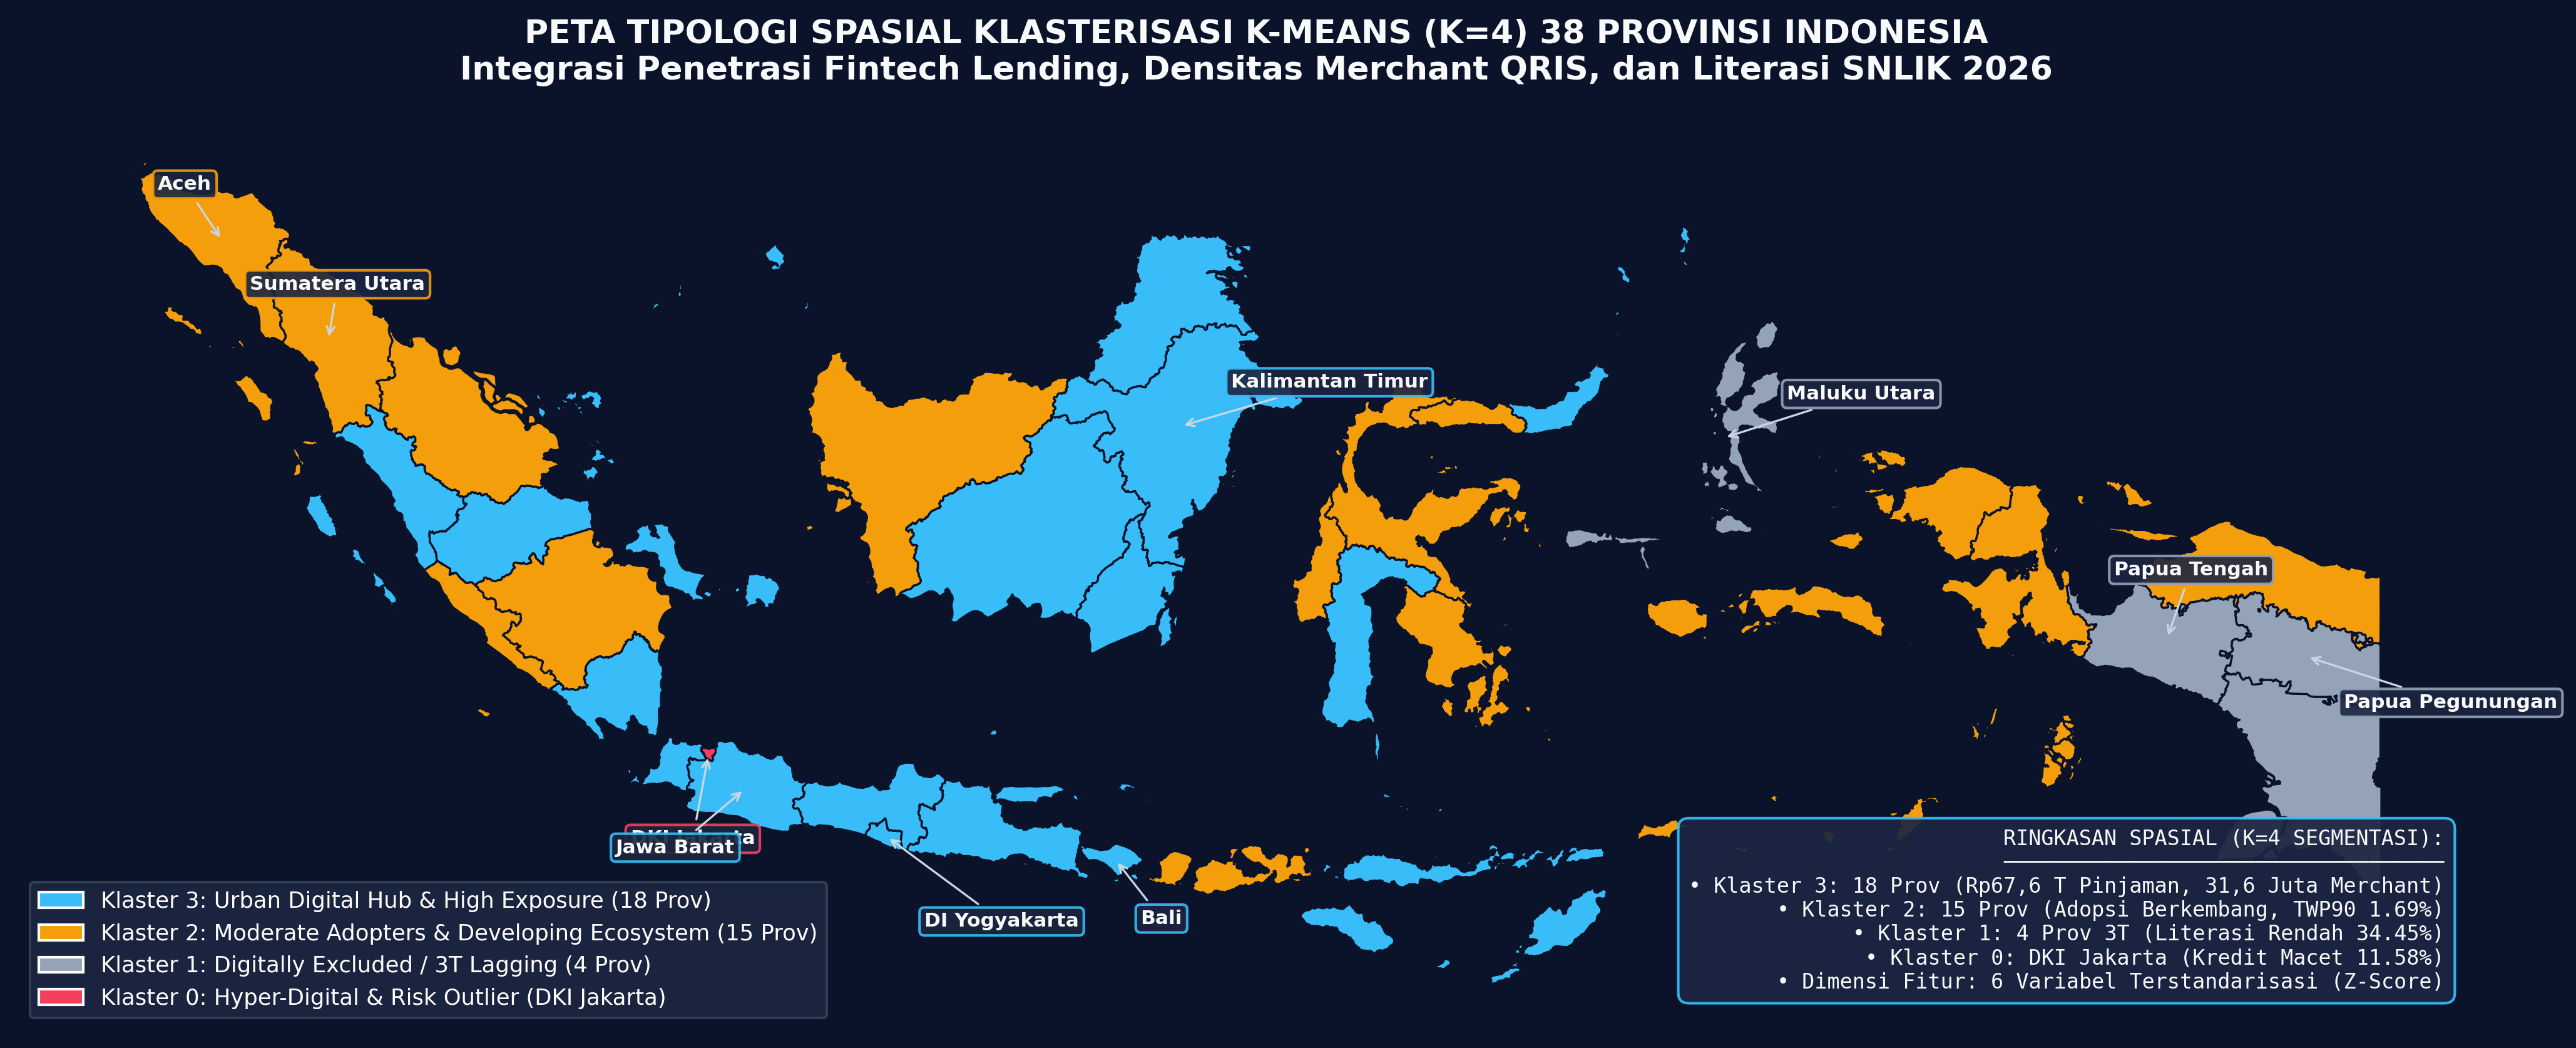

In [49]:
import json
import geopandas as gpd
from shapely.geometry import shape
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 1. Parse File GeoJSON
with open('Dataset/38 Provinsi Indonesia - Provinsi.json', 'r', encoding='utf-8') as f:
    geojson_data = json.load(f)

features_list = []
for feat in geojson_data['features']:
    props = feat['properties']
    props['geometry'] = shape(feat['geometry'])
    features_list.append(props)

gdf = gpd.GeoDataFrame(features_list)
gdf['PROVINSI_CLEAN'] = gdf['PROVINSI'].replace({'Daerah Istimewa Yogyakarta': 'DI Yogyakarta'})
gdf_merged_k4 = gdf.merge(df_master, left_on='PROVINSI_CLEAN', right_on='Provinsi')

# 2. Setup Kanvas Dark Slate
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 7), dpi=300)
fig.patch.set_facecolor('#0B132B')
ax.set_facecolor('#0B132B')

# Palet Warna Sesuai Urutan Indeks Klaster Kamu
palette_k4 = {
    3: '#38BDF8',  # Klaster 3: Urban Digital Hub (Sky Blue - 18 Prov)
    2: '#F59E0B',  # Klaster 2: Moderate Adopters (Amber - 15 Prov)
    1: '#94A3B8',  # Klaster 1: Digitally Excluded / 3T Lagging (Slate Grey - 4 Prov)
    0: '#F43F5E'   # Klaster 0: Hyper-Digital Outlier (Crimson Red - DKI Jakarta)
}

# 3. Plot Poligon Peta (Urutan layer: 3, 2, 1, 0 agar DKI Jakarta menonjol)
for c in [3, 2, 1, 0]:
    sub_gdf = gdf_merged_k4[gdf_merged_k4['Cluster_K4'] == c]
    sub_gdf.plot(ax=ax, color=palette_k4[c], edgecolor='#0B132B', linewidth=0.8)

# 4. Anotasi Label Provinsi Kunci pada Peta
annot_provs = {
    'DKI Jakarta': (-30, -35), 'Jawa Barat': (-50, -25), 'Bali': (10, -25),
    'DI Yogyakarta': (15, -35), 'Aceh': (-25, 20), 'Maluku Utara': (25, 15),
    'Papua Pegunungan': (15, -20), 'Papua Tengah': (-20, 25), 'Sumatera Utara': (-30, 20),
    'Kalimantan Timur': (20, 15)
}

for _, row in gdf_merged_k4.iterrows():
    p = row['Provinsi']
    if p in annot_provs:
        centroid = row['geometry'].centroid
        ax.annotate(p, xy=(centroid.x, centroid.y), xytext=annot_provs[p], textcoords='offset points',
                    fontsize=7.5, color='#F8FAFC', fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.25', facecolor='#1C2541', edgecolor=palette_k4[row['Cluster_K4']], alpha=0.9),
                    arrowprops=dict(arrowstyle='->', color='#CBD5E1', lw=0.8))

ax.set_axis_off()
plt.title('PETA TIPOLOGI SPASIAL KLASTERISASI K-MEANS (K=4) 38 PROVINSI INDONESIA\nIntegrasi Penetrasi Fintech Lending, Densitas Merchant QRIS, dan Literasi SNLIK 2026',
          fontsize=12.5, fontweight='bold', color='#F8FAFC', pad=15)

# Legenda Tersinkronisasi
legend_elements = [
    Patch(facecolor=palette_k4[3], edgecolor='#FFFFFF', label='Klaster 3: Urban Digital Hub & High Exposure (18 Prov)'),
    Patch(facecolor=palette_k4[2], edgecolor='#FFFFFF', label='Klaster 2: Moderate Adopters & Developing Ecosystem (15 Prov)'),
    Patch(facecolor=palette_k4[1], edgecolor='#FFFFFF', label='Klaster 1: Digitally Excluded / 3T Lagging (4 Prov)'),
    Patch(facecolor=palette_k4[0], edgecolor='#FFFFFF', label='Klaster 0: Hyper-Digital & Risk Outlier (DKI Jakarta)')
]
ax.legend(handles=legend_elements, loc='lower left', facecolor='#1C2541', edgecolor='#334155', fontsize=8.5, framealpha=0.95)

# Box Ringkasan
info_box_k4 = (
    "RINGKASAN SPASIAL (K=4 SEGMENTASI):\n"
    "───────────────────────────────────\n"
    "• Klaster 3: 18 Prov (Rp67,6 T Pinjaman, 31,6 Juta Merchant)\n"
    "• Klaster 2: 15 Prov (Adopsi Berkembang, TWP90 1.69%)\n"
    "• Klaster 1: 4 Prov 3T (Literasi Rendah 34.45%)\n"
    "• Klaster 0: DKI Jakarta (Kredit Macet 11.58%)\n"
    "• Dimensi Fitur: 6 Variabel Terstandarisasi (Z-Score)"
)
ax.text(0.98, 0.04, info_box_k4, transform=ax.transAxes, fontsize=8, verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#1C2541', edgecolor='#38BDF8', alpha=0.92),
        color='#F8FAFC', family='monospace')



plt.tight_layout()
plt.savefig('babak2_spatial_map_k4_final.png', dpi=300)
plt.show()

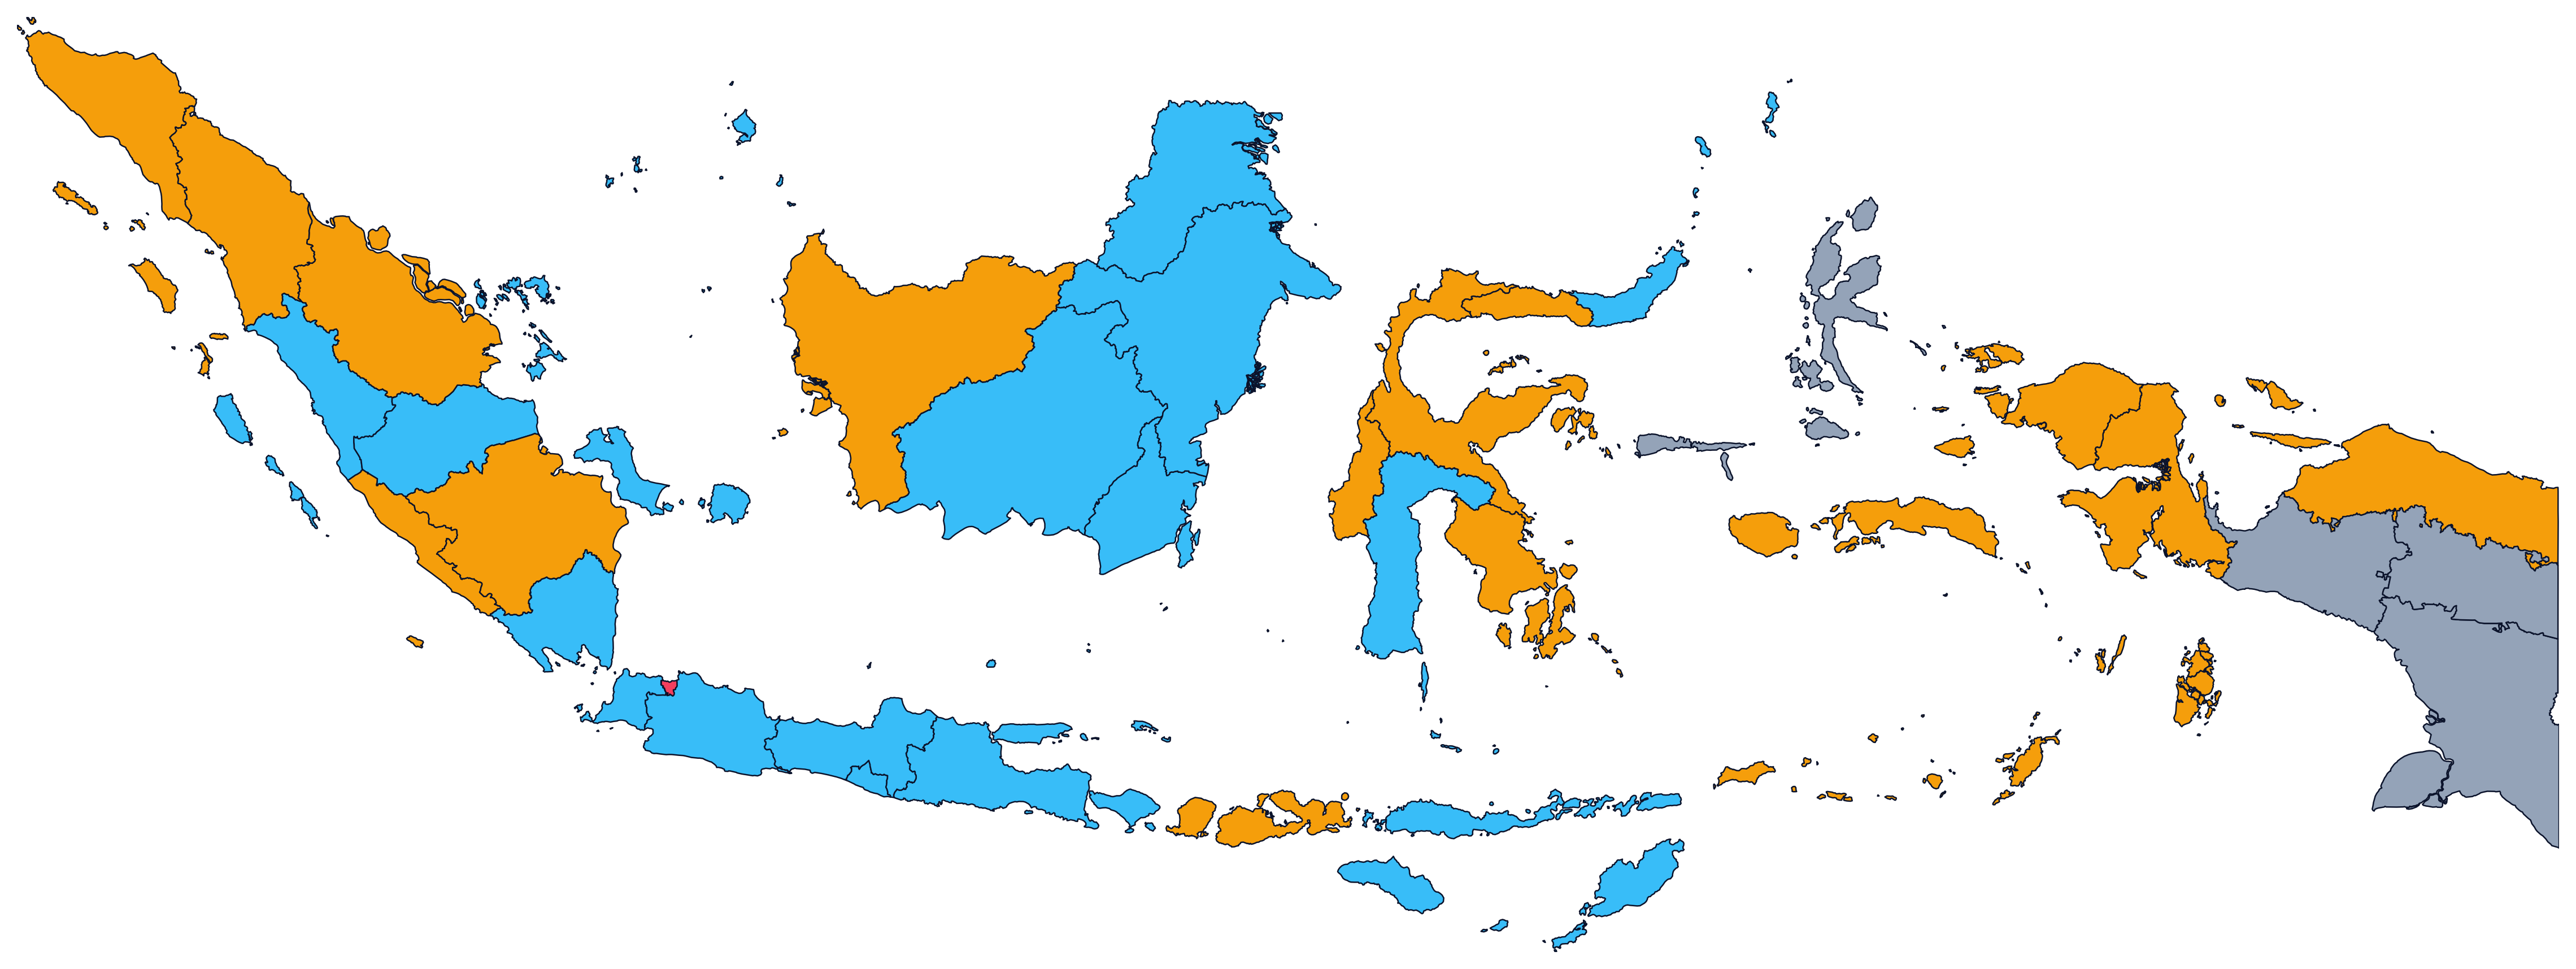

In [50]:
import json
import geopandas as gpd
from shapely.geometry import shape
import matplotlib.pyplot as plt

# 1. Parse File GeoJSON 38 Provinsi
with open('Dataset/38 Provinsi Indonesia - Provinsi.json', 'r', encoding='utf-8') as f:
    geojson_data = json.load(f)

features_list = []
for feat in geojson_data['features']:
    props = feat['properties']
    props['geometry'] = shape(feat['geometry'])
    features_list.append(props)

gdf = gpd.GeoDataFrame(features_list)
gdf['PROVINSI_CLEAN'] = gdf['PROVINSI'].replace({'Daerah Istimewa Yogyakarta': 'DI Yogyakarta'})
gdf_merged_k4 = gdf.merge(df_master, left_on='PROVINSI_CLEAN', right_on='Provinsi')

# 2. Palet Warna Klaster
palette_k4 = {
    3: '#38BDF8',  # Klaster 3: Urban Digital Hub (Sky Blue - 18 Prov)
    2: '#F59E0B',  # Klaster 2: Moderate Adopters (Amber Orange - 15 Prov)
    1: '#94A3B8',  # Klaster 1: Digitally Excluded / 3T (Slate Grey - 4 Prov)
    0: '#F43F5E'   # Klaster 0: Hyper-Digital Outlier (Crimson Red - DKI Jakarta)
}

# 3. Plot Peta Polos Versi Transparan (Khusus Desain Figma / Canva / Photoshop)
fig, ax = plt.subplots(figsize=(15, 6.5), dpi=300)
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

for c in [3, 2, 1, 0]:
    sub_gdf = gdf_merged_k4[gdf_merged_k4['Cluster_K4'] == c]
    sub_gdf.plot(ax=ax, color=palette_k4[c], edgecolor='#0B132B', linewidth=0.6)

ax.set_axis_off()
plt.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0)
plt.margins(0, 0)
plt.savefig('peta_polos_indonesia_k4_transparent.png', dpi=300, transparent=True, bbox_inches='tight', pad_inches=0.02)
plt.show()

# BAGIAN 3

## Tahap 1: Analisis Alokasi Sektoral Pinjaman Fintech P2P Lending (OJK LPBBTI)

Membedah arah aliran dana pinjaman daring di tingkat nasional berdasarkan data resmi statistik OJK LPBBTI. Tujuannya adalah menguji apakah penetrasi fintech lending yang melonjak benar-benar dialokasikan untuk membiayai usaha produktif (UMKM/modal kerja) atau justru didominasi oleh pinjaman konsumtif perorangan (multiguna/paylater).

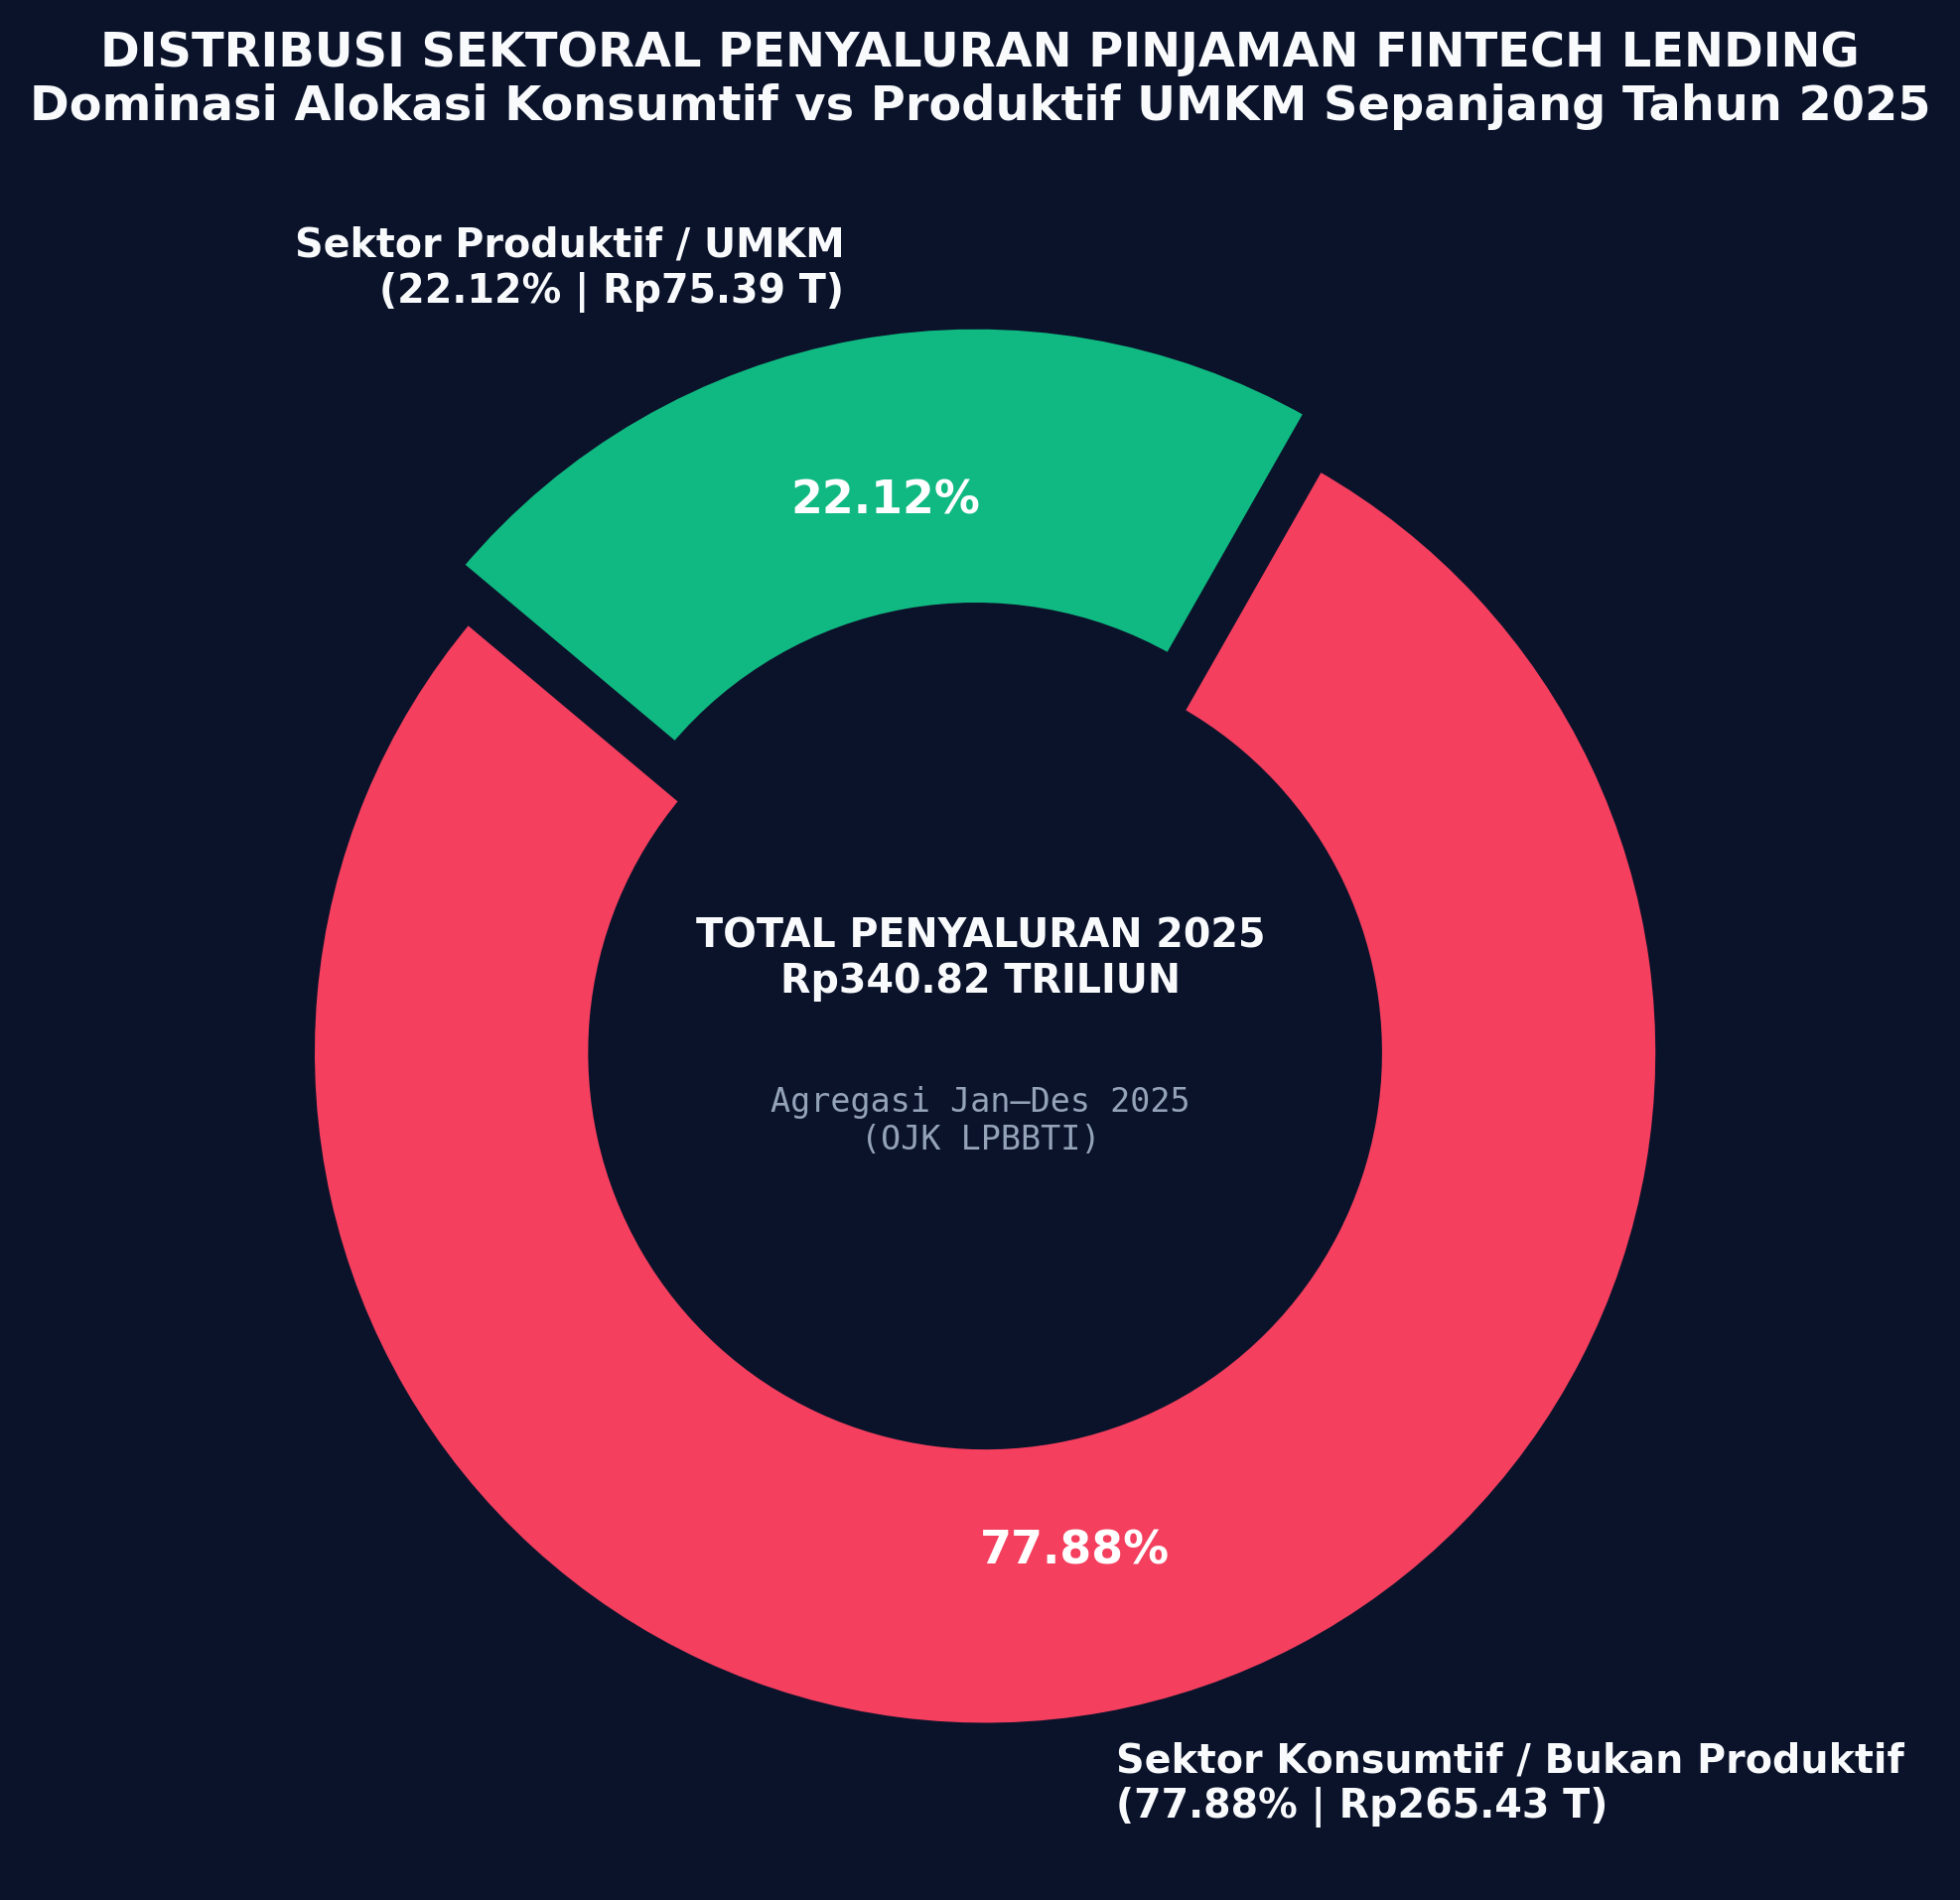

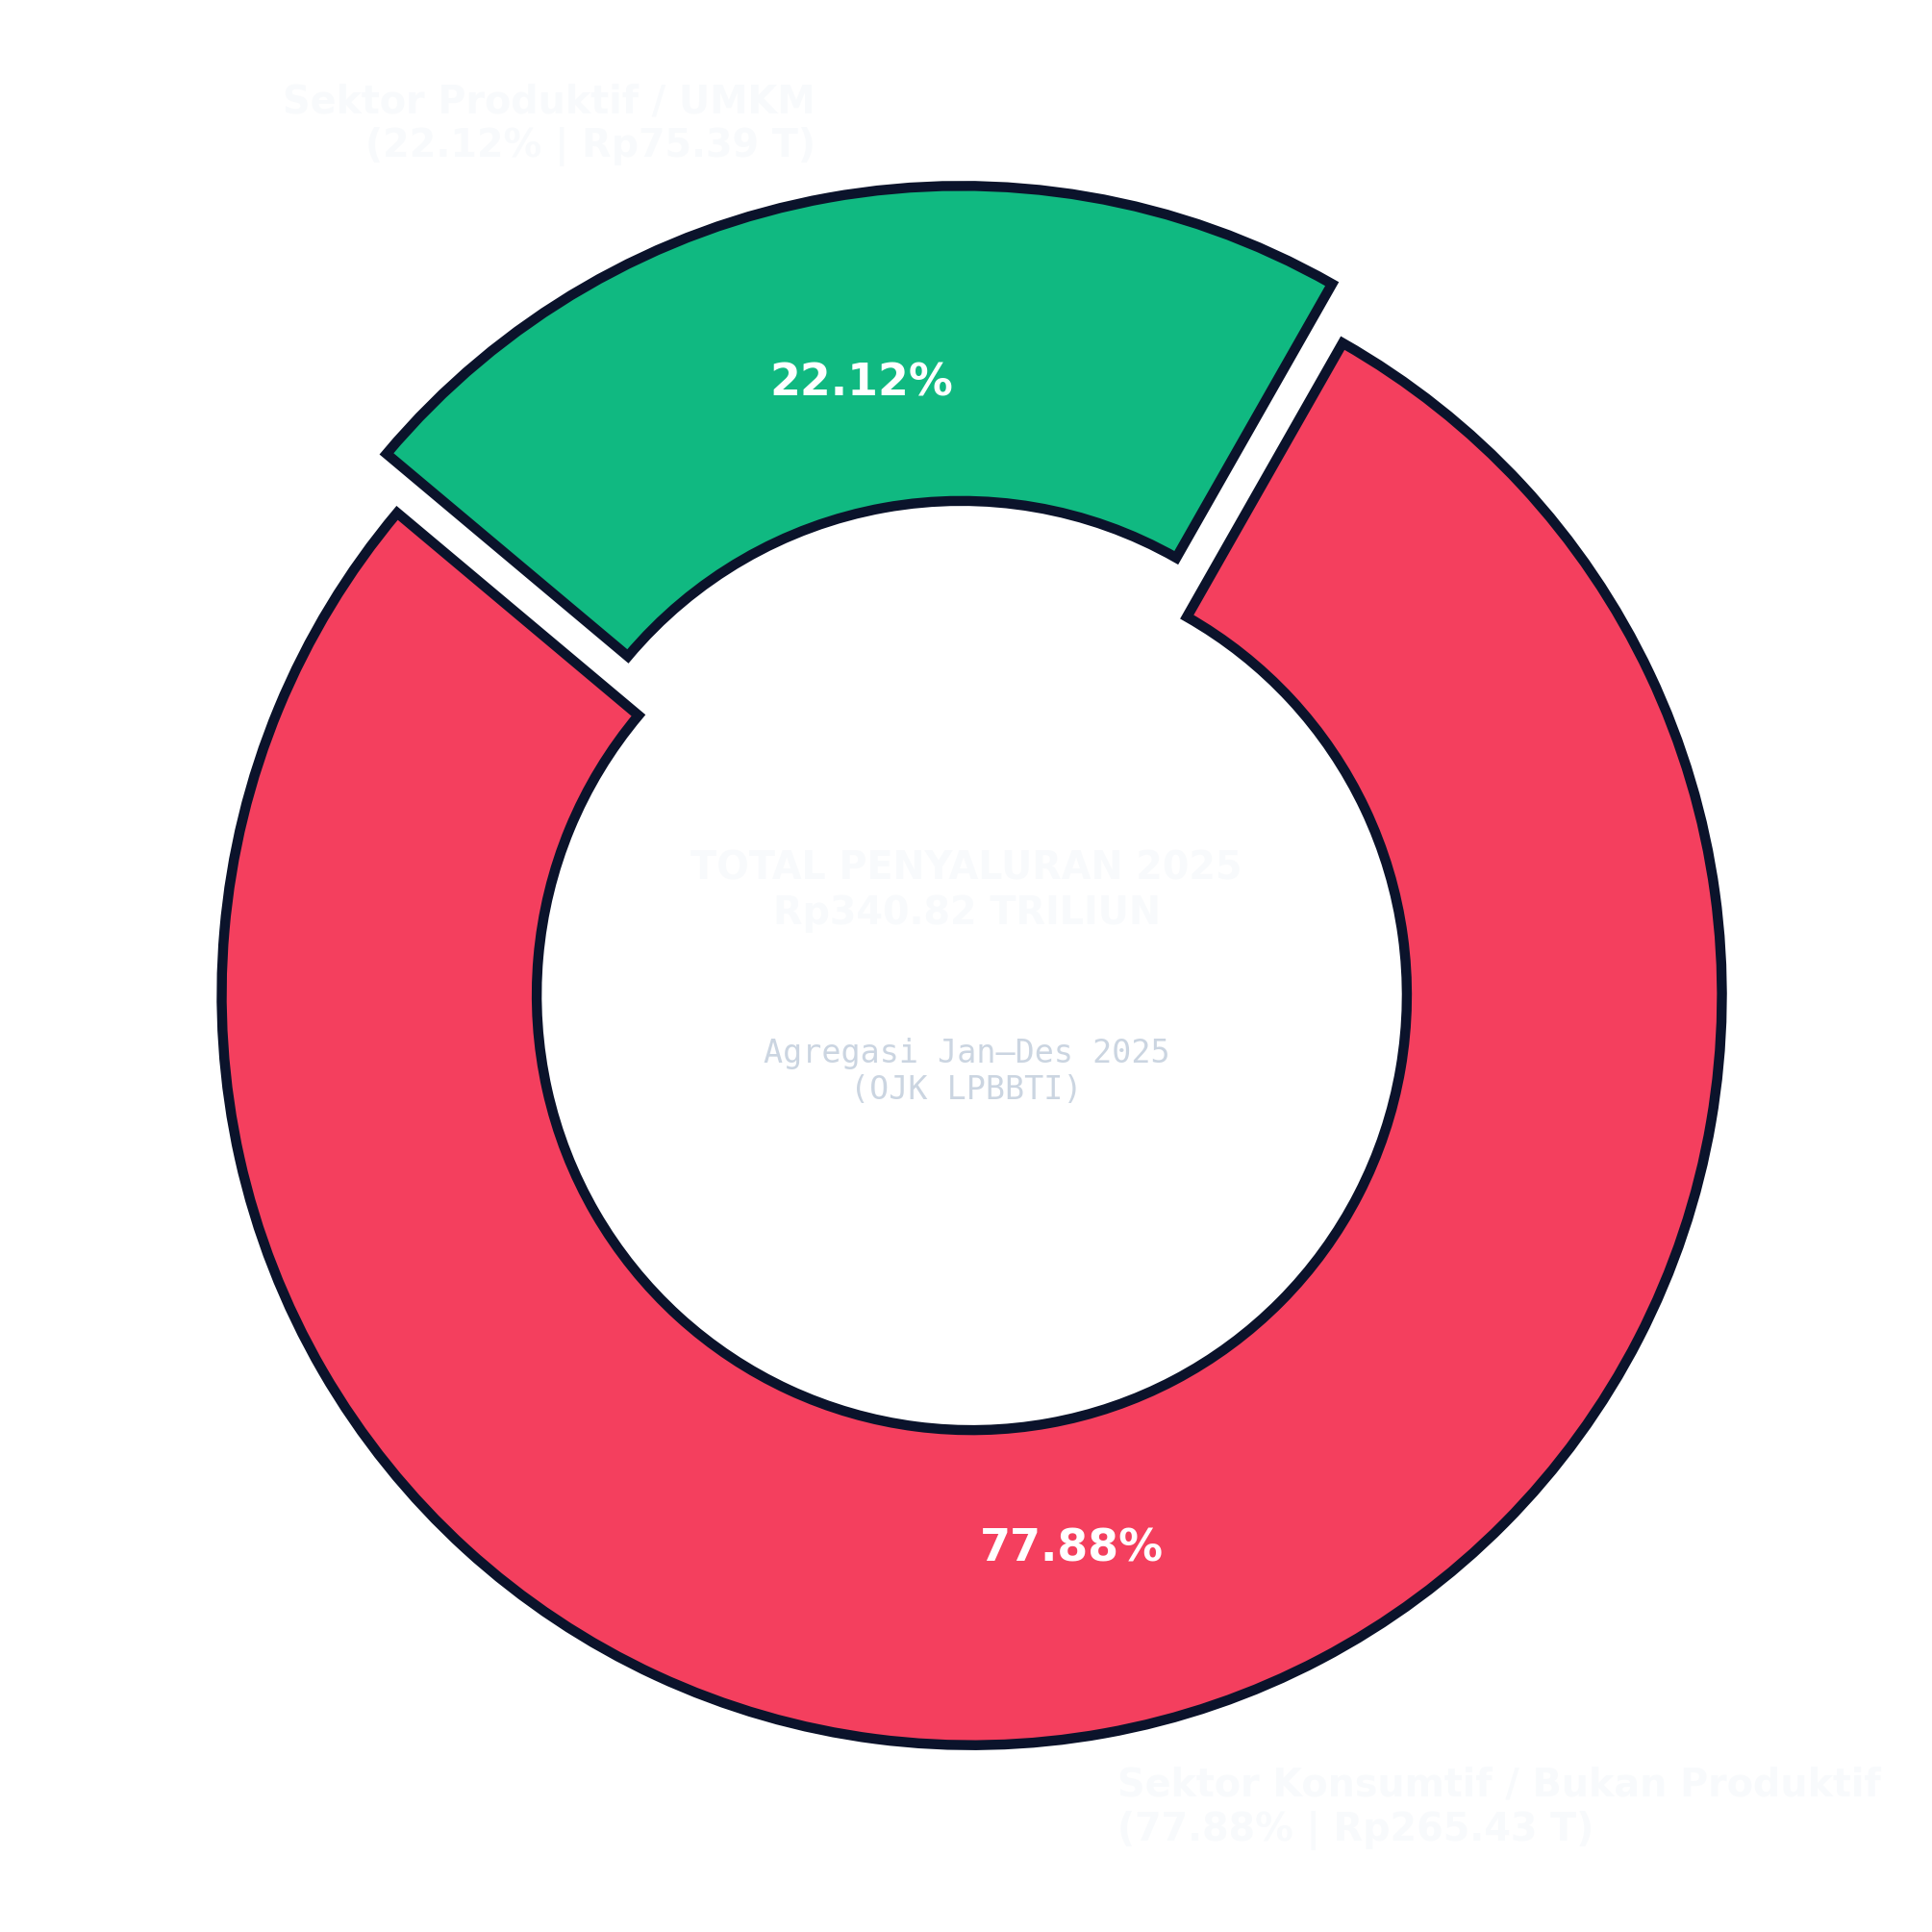

In [3]:
import matplotlib.pyplot as plt

# 1. Parameter Penyaluran Pinjaman Fintech Lending (Agregasi Jan-Des 2025)
total_penyaluran_miliar = 340821.69
total_penyaluran_triliun = total_penyaluran_miliar / 1000.0  # Rp340,82 Triliun

pct_produktif = 22.12
pct_konsumtif = 100.0 - pct_produktif  # 77.88%

nom_produktif_triliun = total_penyaluran_triliun * (pct_produktif / 100.0)
nom_konsumtif_triliun = total_penyaluran_triliun * (pct_konsumtif / 100.0)

labels = [
    (
        'Sektor Konsumtif / Bukan'
        f' Produktif\n({pct_konsumtif:.2f}% |'
        f' Rp{nom_konsumtif_triliun:.2f} T)'
    ),
    (
        'Sektor Produktif /'
        f' UMKM\n({pct_produktif:.2f}% | Rp{nom_produktif_triliun:.2f} T)'
    ),
]
sizes = [pct_konsumtif, pct_produktif]
colors = ['#F43F5E', '#10B981']
explode = (0.04, 0.04)

# -------------------------------------------------------------
# 2. Visualisasi Lengkap Versi Dark Slate
# -------------------------------------------------------------
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(6.5, 6.5), dpi=300)
fig.patch.set_facecolor('#0B132B')
ax.set_facecolor('#0B132B')

wedges, texts, autotexts = ax.pie(
    sizes,
    explode=explode,
    labels=labels,
    autopct='%1.2f%%',
    startangle=140,
    colors=colors,
    pctdistance=0.75,
    textprops=dict(color='#F8FAFC', fontsize=9.5, fontweight='bold'),
    wedgeprops=dict(width=0.42, edgecolor='#0B132B', linewidth=2.5),
)

for autotext in autotexts:
  autotext.set_color('#FFFFFF')
  autotext.set_fontsize(11)
  autotext.set_fontweight('heavy')

# Anotasi Teks Tengah
ax.text(
    0,
    0.10,
    f'TOTAL PENYALURAN 2025\nRp{total_penyaluran_triliun:.2f} TRILIUN',
    ha='center',
    va='center',
    fontsize=9.5,
    fontweight='bold',
    color='#F8FAFC',
)
ax.text(
    0,
    -0.14,
    'Agregasi Jan–Des 2025\n(OJK LPBBTI)',
    ha='center',
    va='center',
    fontsize=8,
    color='#94A3B8',
    family='monospace',
)

plt.title(
    'DISTRIBUSI SEKTORAL PENYALURAN PINJAMAN FINTECH LENDING\nDominasi Alokasi'
    ' Konsumtif vs Produktif UMKM Sepanjang Tahun 2025',
    fontsize=11.5,
    fontweight='bold',
    color='#F8FAFC',
    pad=15,
)

plt.tight_layout()
plt.savefig('donut_penyaluran_2025_full.png', dpi=300)
plt.show()

# -------------------------------------------------------------
# 3. Visualisasi Versi Polos Transparan (Khusus Desain Poster)
# -------------------------------------------------------------
fig_tr, ax_tr = plt.subplots(figsize=(6.5, 6.5), dpi=300)
fig_tr.patch.set_alpha(0.0)
ax_tr.patch.set_alpha(0.0)

wedges_tr, texts_tr, autotexts_tr = ax_tr.pie(
    sizes,
    explode=explode,
    labels=labels,
    autopct='%1.2f%%',
    startangle=140,
    colors=colors,
    pctdistance=0.75,
    textprops=dict(color='#F8FAFC', fontsize=9.5, fontweight='bold'),
    wedgeprops=dict(width=0.42, edgecolor='#0B132B', linewidth=2.5),
)

for autotext in autotexts_tr:
  autotext.set_color('#FFFFFF')
  autotext.set_fontsize(11)
  autotext.set_fontweight('heavy')

ax_tr.text(
    0,
    0.10,
    f'TOTAL PENYALURAN 2025\nRp{total_penyaluran_triliun:.2f} TRILIUN',
    ha='center',
    va='center',
    fontsize=9.5,
    fontweight='bold',
    color='#F8FAFC',
)
ax_tr.text(
    0,
    -0.14,
    'Agregasi Jan–Des 2025\n(OJK LPBBTI)',
    ha='center',
    va='center',
    fontsize=8,
    color='#CBD5E1',
    family='monospace',
)

plt.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0)
plt.margins(0, 0)
plt.savefig(
    'donut_penyaluran_2025_transparent.png',
    dpi=300,
    transparent=True,
    bbox_inches='tight',
    pad_inches=0.02,
)
plt.show()

## Tahap 2: Evaluasi 5 Dimensi Literasi Finansial SNLIK 2026 (The Action Gap)

Membedah data parameter penyusun Indeks Literasi Keuangan SNLIK 2026 (parameter_indeks_literasi_keuangan.csv). Analisis ini menguji kesenjangan antara apa yang dipahami masyarakat (Knowledge/Pengetahuan) dengan bagaimana masyarakat mengelola uangnya sehari-hari (Behavior/Perilaku) menggunakan Radar/Spider Chart.

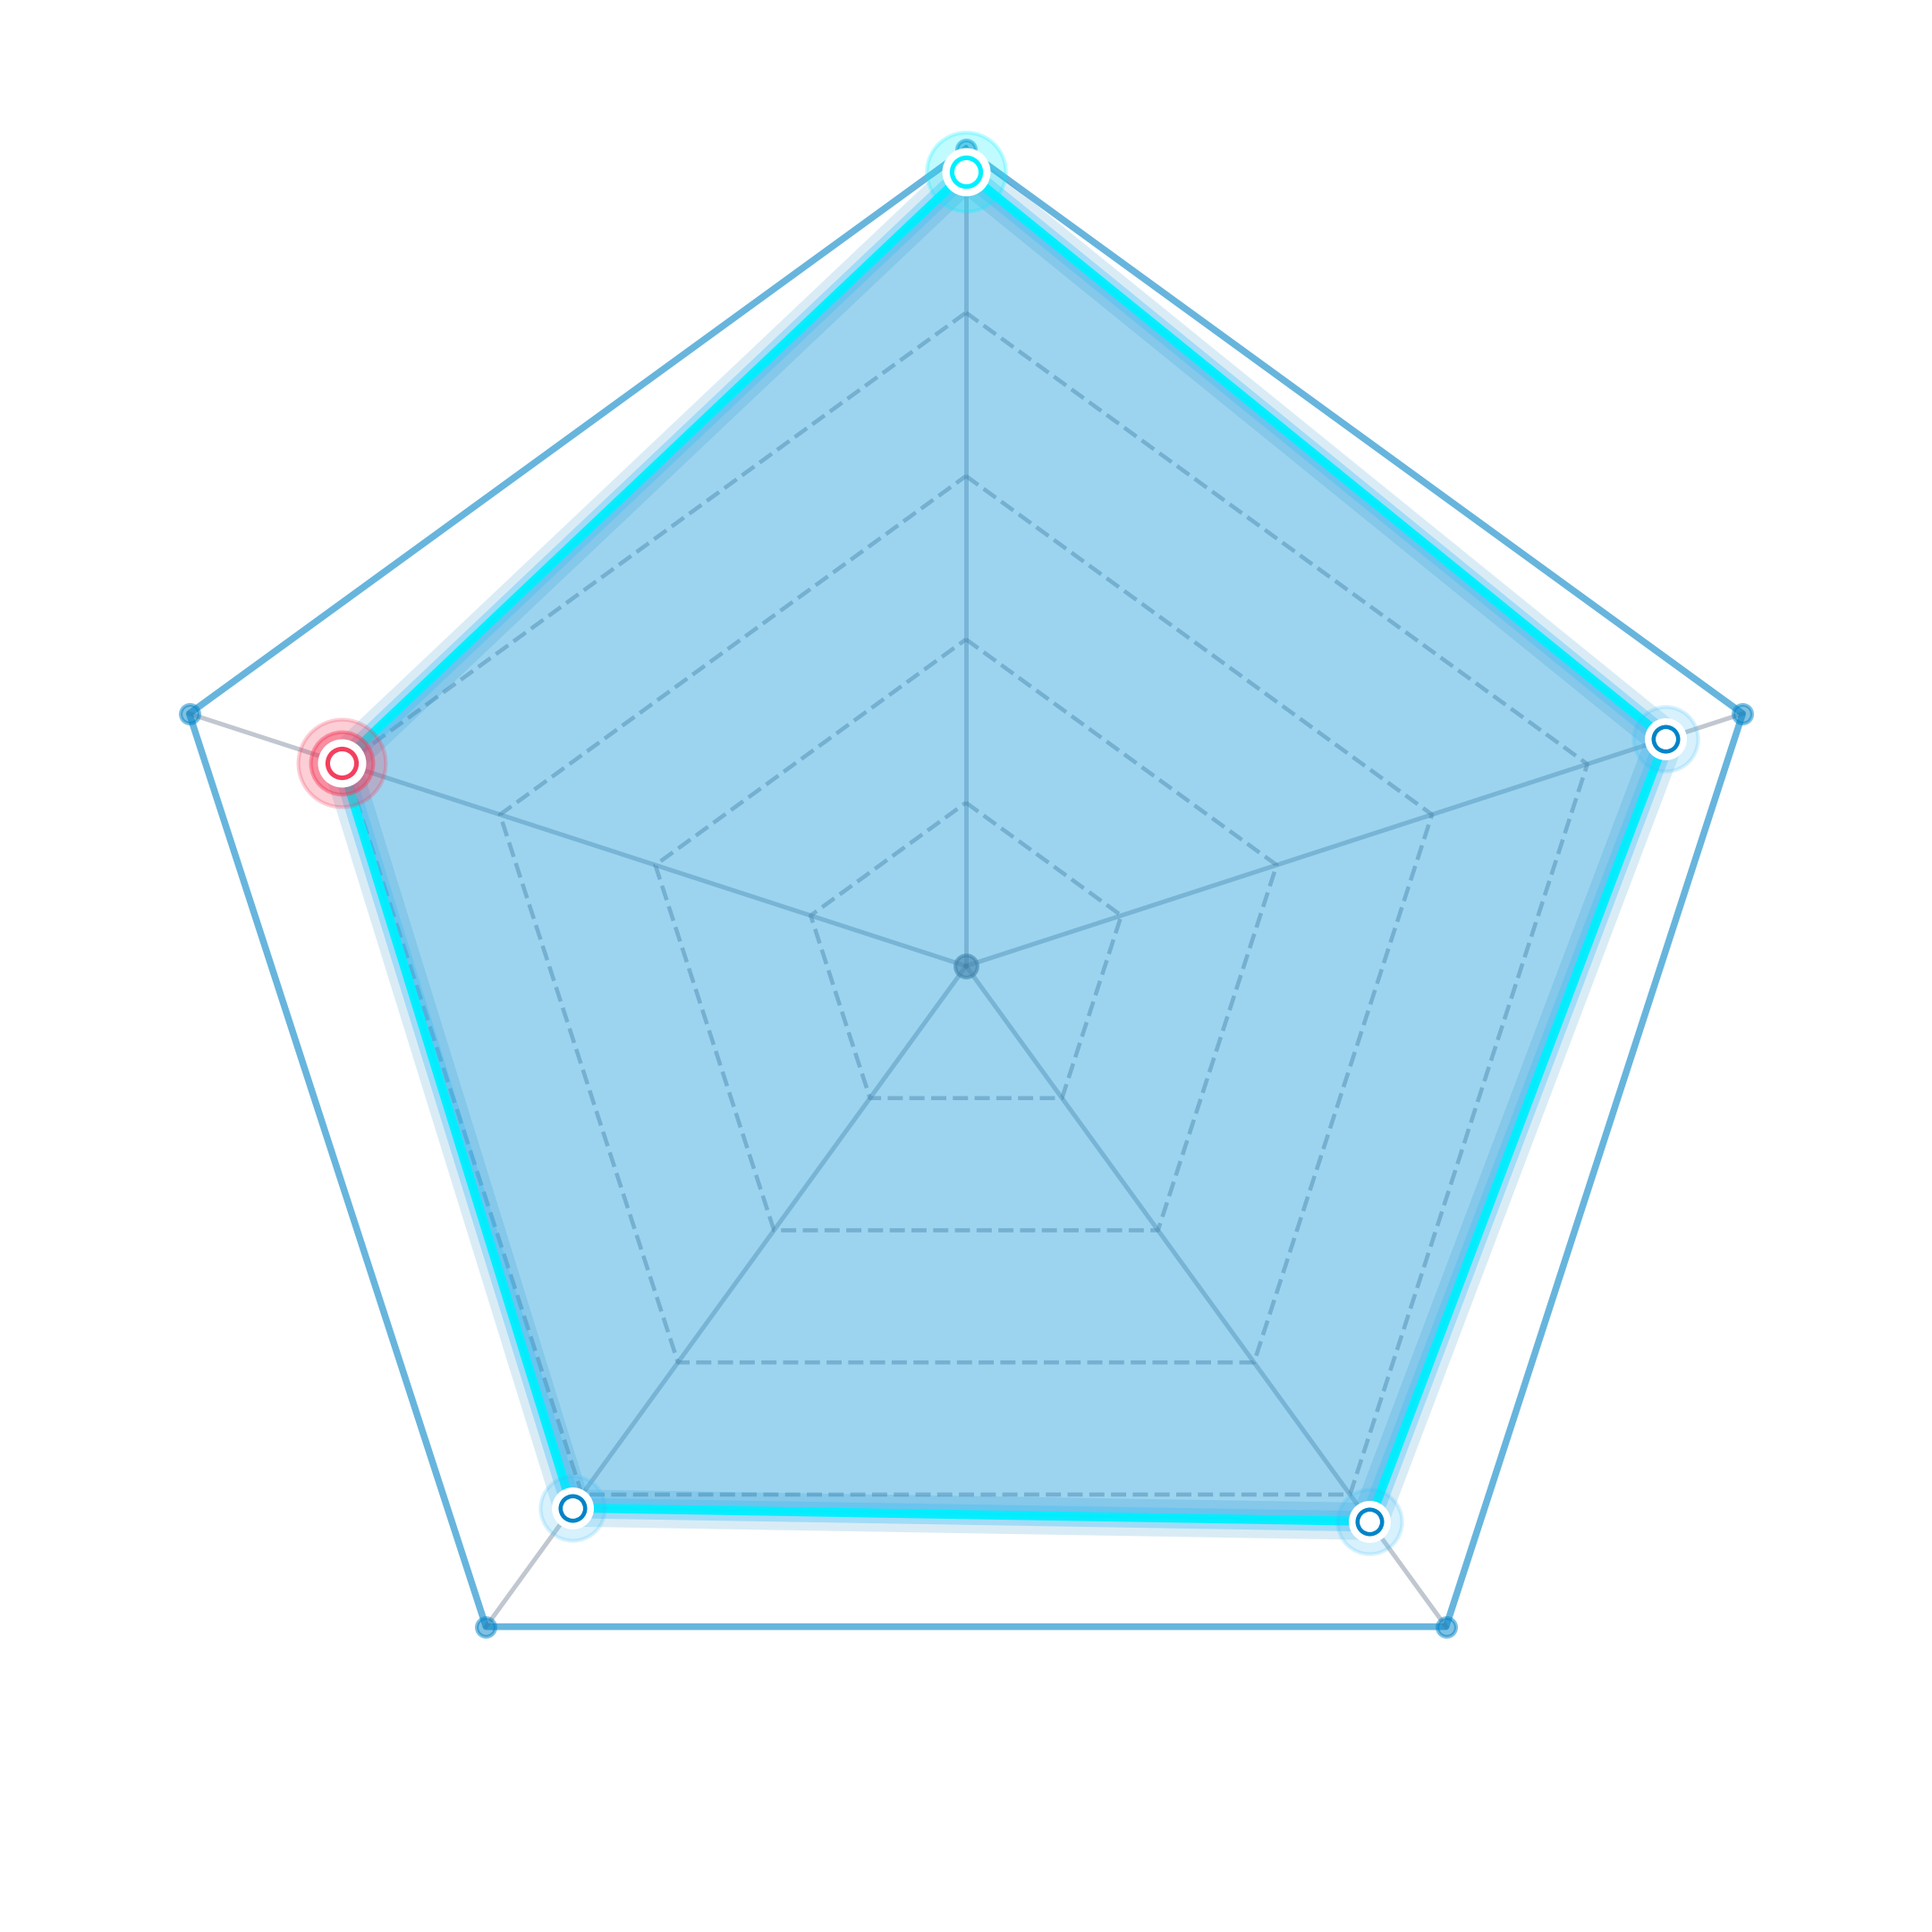

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------------------
# 1. Parameter Data 5 Dimensi SNLIK
# -------------------------------------------------------------
scores = [97.24, 90.06, 84.06, 82.03, 80.43]
num_vars = len(scores)

# Sudut segi lima (titik puncak tepat di atas / 90 derajat)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
scores_closed = scores + [scores[0]]
angles_closed = angles + [angles[0]]

# Koordinat data polygon
x_data = [v * np.sin(a) for v, a in zip(scores_closed, angles_closed)]
y_data = [v * np.cos(a) for v, a in zip(scores_closed, angles_closed)]

# -------------------------------------------------------------
# 2. Setup Canvas Transparan High-Res
# -------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 7), dpi=300)
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

# A. Grid Segi Lima (Concentric Pentagons)
grid_levels = [20, 40, 60, 80, 100]
for level in grid_levels:
    x_grid = [level * np.sin(a) for a in angles_closed]
    y_grid = [level * np.cos(a) for a in angles_closed]
    
    if level == 100:
        # Ring terluar (lebih tegas sebagai batas 100%)
        ax.plot(x_grid, y_grid, color='#0284C7', linestyle='-', linewidth=1.8, alpha=0.6, zorder=1)
    else:
        # Ring dalam (subtle dashed grid)
        ax.plot(x_grid, y_grid, color='#64748B', linestyle='--', linewidth=1.1, alpha=0.45, zorder=1)

# B. Garis Jari-Jari (Radial Spokes) & Node Ujung Grid
for a in angles:
    x_spoke = [0, 100 * np.sin(a)]
    y_spoke = [0, 100 * np.cos(a)]
    ax.plot(x_spoke, y_spoke, color='#64748B', linestyle='-', linewidth=1.2, alpha=0.4, zorder=1)
    # Titik jangkar kecil di ujung 100%
    ax.scatter(100 * np.sin(a), 100 * np.cos(a), s=25, color='#0284C7', alpha=0.5, zorder=2)

# Titik pusat poros
ax.scatter(0, 0, s=35, color='#64748B', alpha=0.6, zorder=2)

# C. Efek Multi-Layered Glow & Area Fill Poligon Data
# Lapisan area dalam
ax.fill(x_data, y_data, color='#0284C7', alpha=0.30, zorder=2)
ax.fill(x_data, y_data, color='#38BDF8', alpha=0.18, zorder=2)

# Lapisan neon glow garis (stacked stroke)
ax.plot(x_data, y_data, color='#0284C7', linewidth=10.0, alpha=0.15, zorder=3)
ax.plot(x_data, y_data, color='#38BDF8', linewidth=5.5,  alpha=0.35, zorder=3)
ax.plot(x_data, y_data, color='#00F0FF', linewidth=2.4,  alpha=0.95, zorder=4)

# D. Node Khusus (Titik Sudut Modern)
for i, (x, y) in enumerate(zip(x_data[:-1], y_data[:-1])):
    if i == 4:  # Titik Perilaku (Titik Kritis / Terendah)
        # Glow halo merah
        ax.scatter(x, y, s=550, color='#F43F5E', alpha=0.25, zorder=4)
        ax.scatter(x, y, s=280, color='#F43F5E', alpha=0.45, zorder=4)
        # Core ring merah-putih
        ax.scatter(x, y, s=120, color='#F43F5E', edgecolor='#FFFFFF', linewidth=2.0, zorder=5)
        ax.scatter(x, y, s=30,  color='#FFFFFF', zorder=6)
    elif i == 0:  # Titik Pengetahuan (Tertinggi)
        # Glow halo cyan-emas
        ax.scatter(x, y, s=450, color='#00F0FF', alpha=0.25, zorder=4)
        # Core ring
        ax.scatter(x, y, s=120, color='#00F0FF', edgecolor='#FFFFFF', linewidth=2.0, zorder=5)
        ax.scatter(x, y, s=30,  color='#FFFFFF', zorder=6)
    else:  # Titik Reguler
        ax.scatter(x, y, s=300, color='#38BDF8', alpha=0.20, zorder=4)
        ax.scatter(x, y, s=90,  color='#0284C7', edgecolor='#FFFFFF', linewidth=1.8, zorder=5)
        ax.scatter(x, y, s=20,  color='#FFFFFF', zorder=6)

# -------------------------------------------------------------
# 3. Framing & Export
# -------------------------------------------------------------
ax.set_xlim(-115, 115)
ax.set_ylim(-115, 115)
ax.set_aspect('equal')
ax.set_axis_off()

plt.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0)
plt.margins(0, 0)

plt.savefig('radar_chart_clean_transparent.png', 
            dpi=300, 
            transparent=True, 
            bbox_inches='tight', 
            pad_inches=0.02)

plt.show()

## Tahap 3: Analisis Disparitas Perkotaan vs. Perdesaan (Urban vs. Rural Lifestyle Gap)

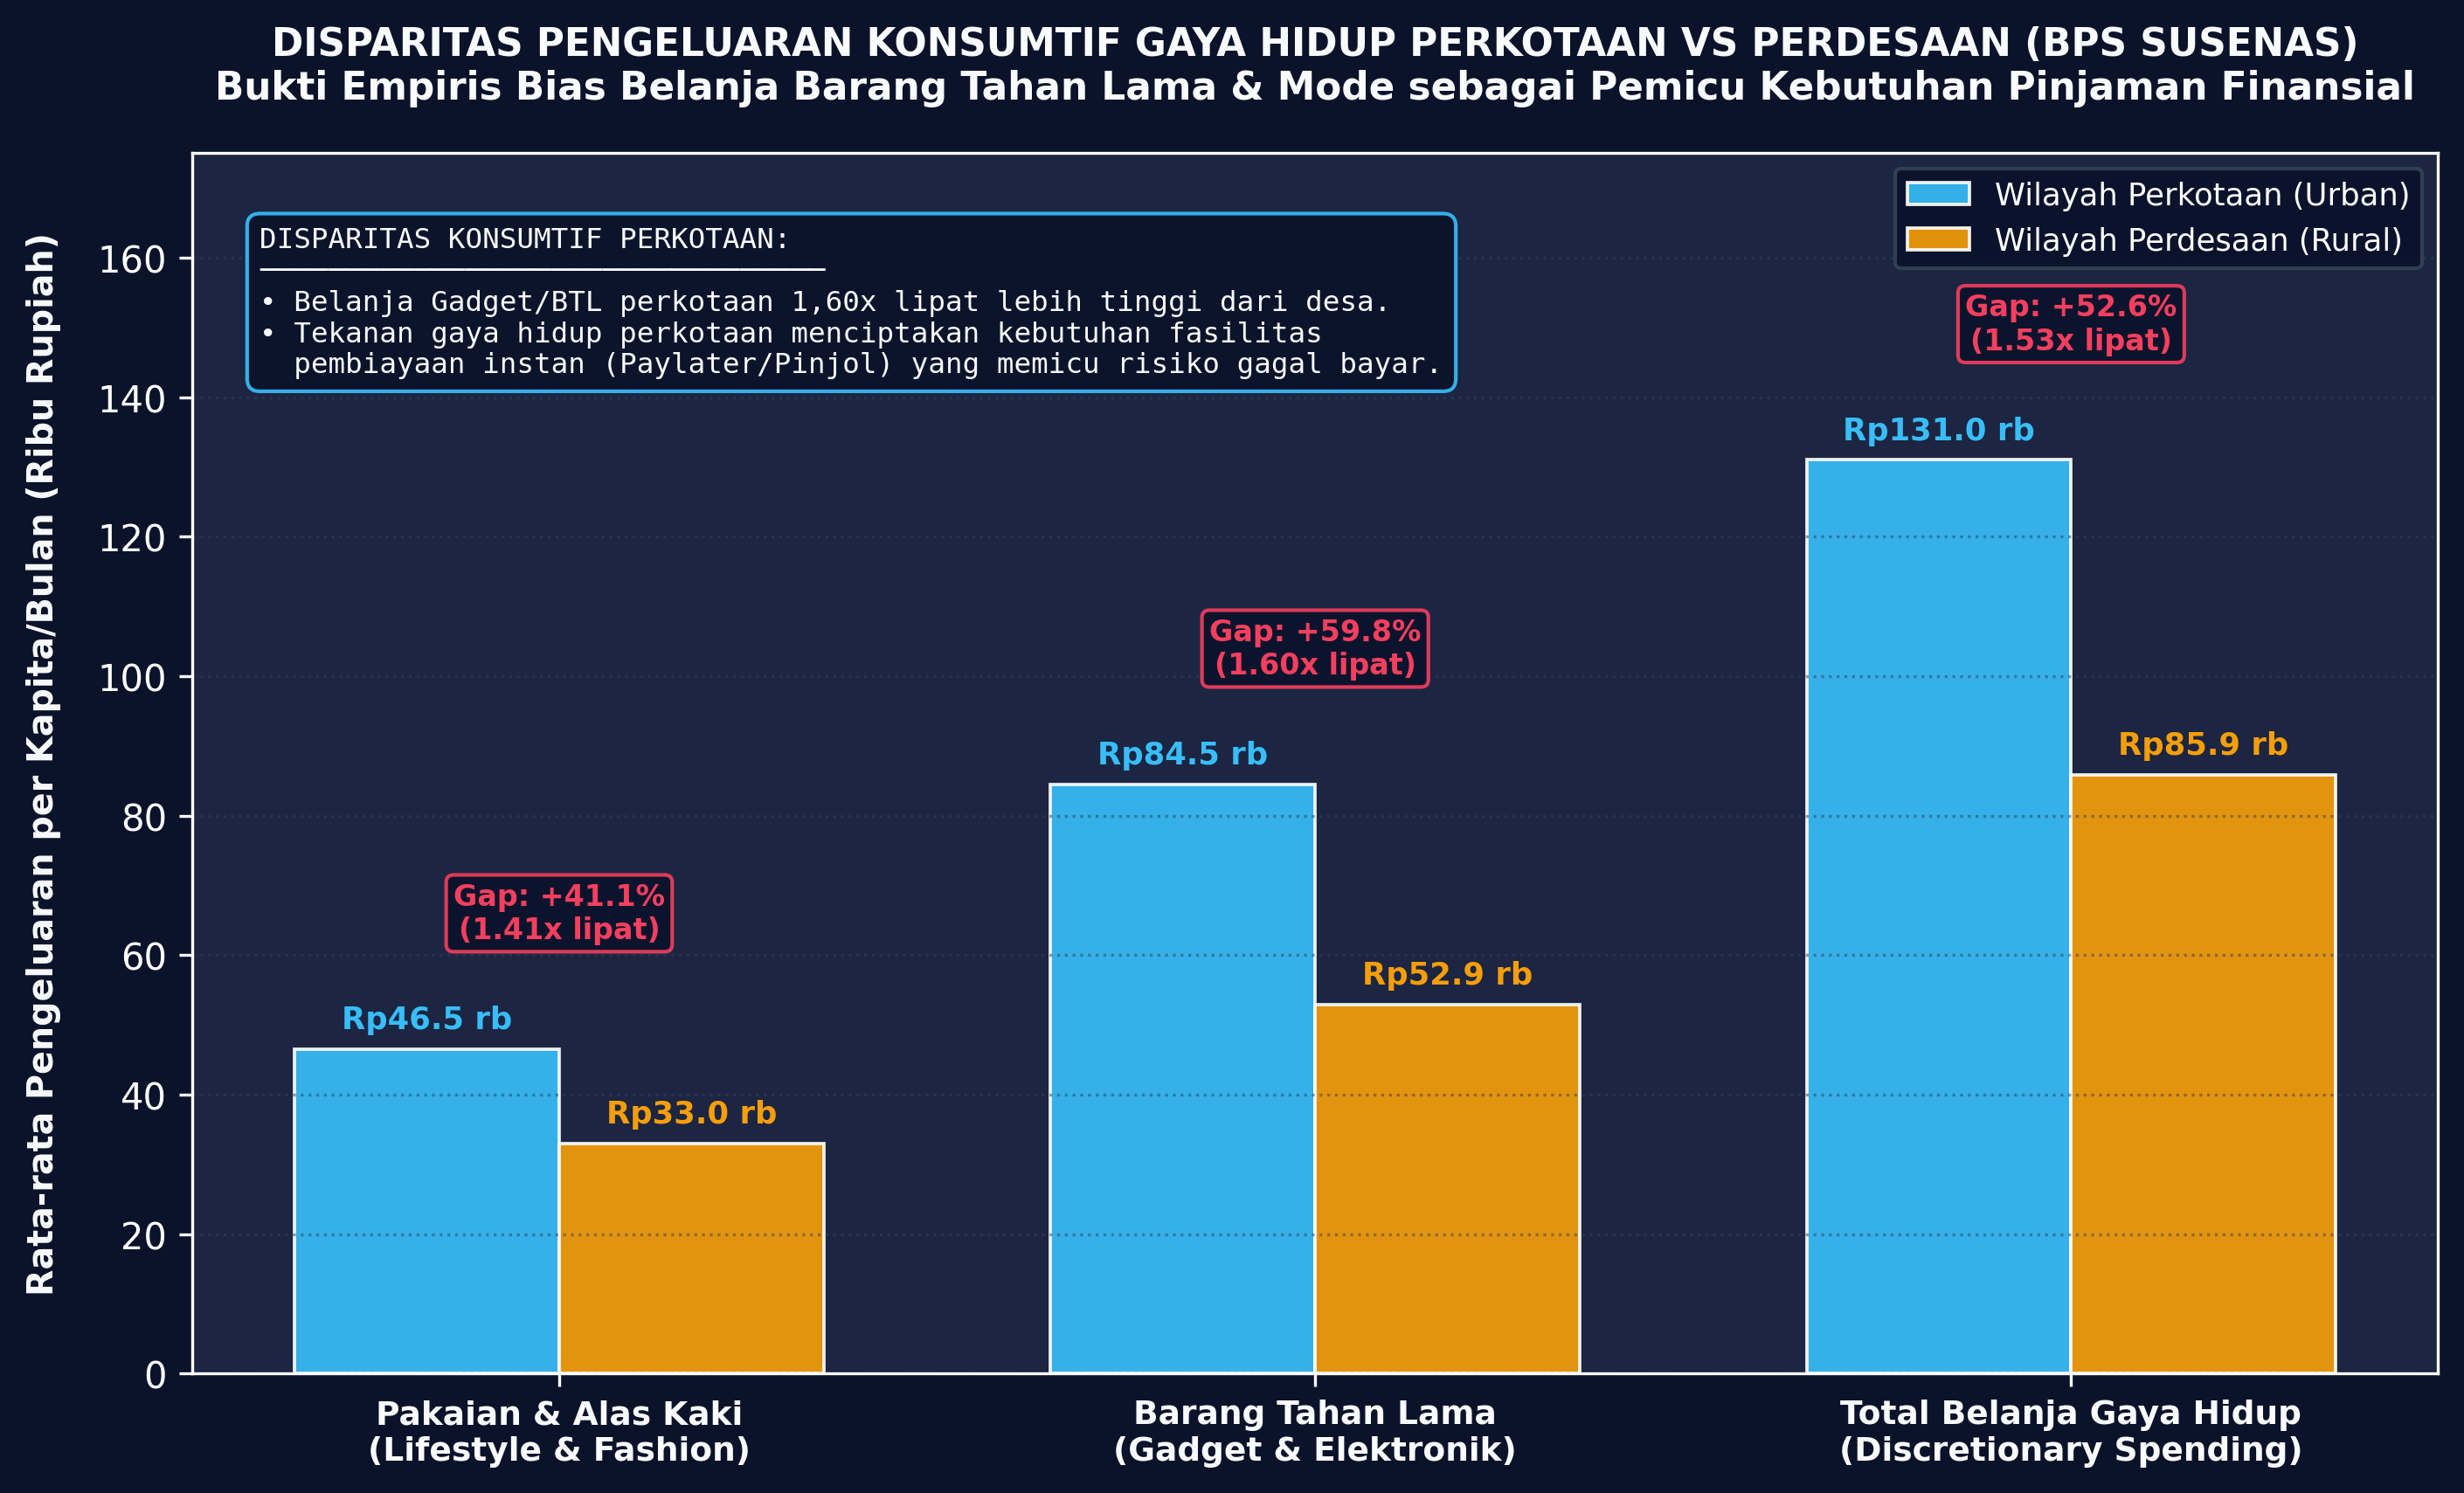

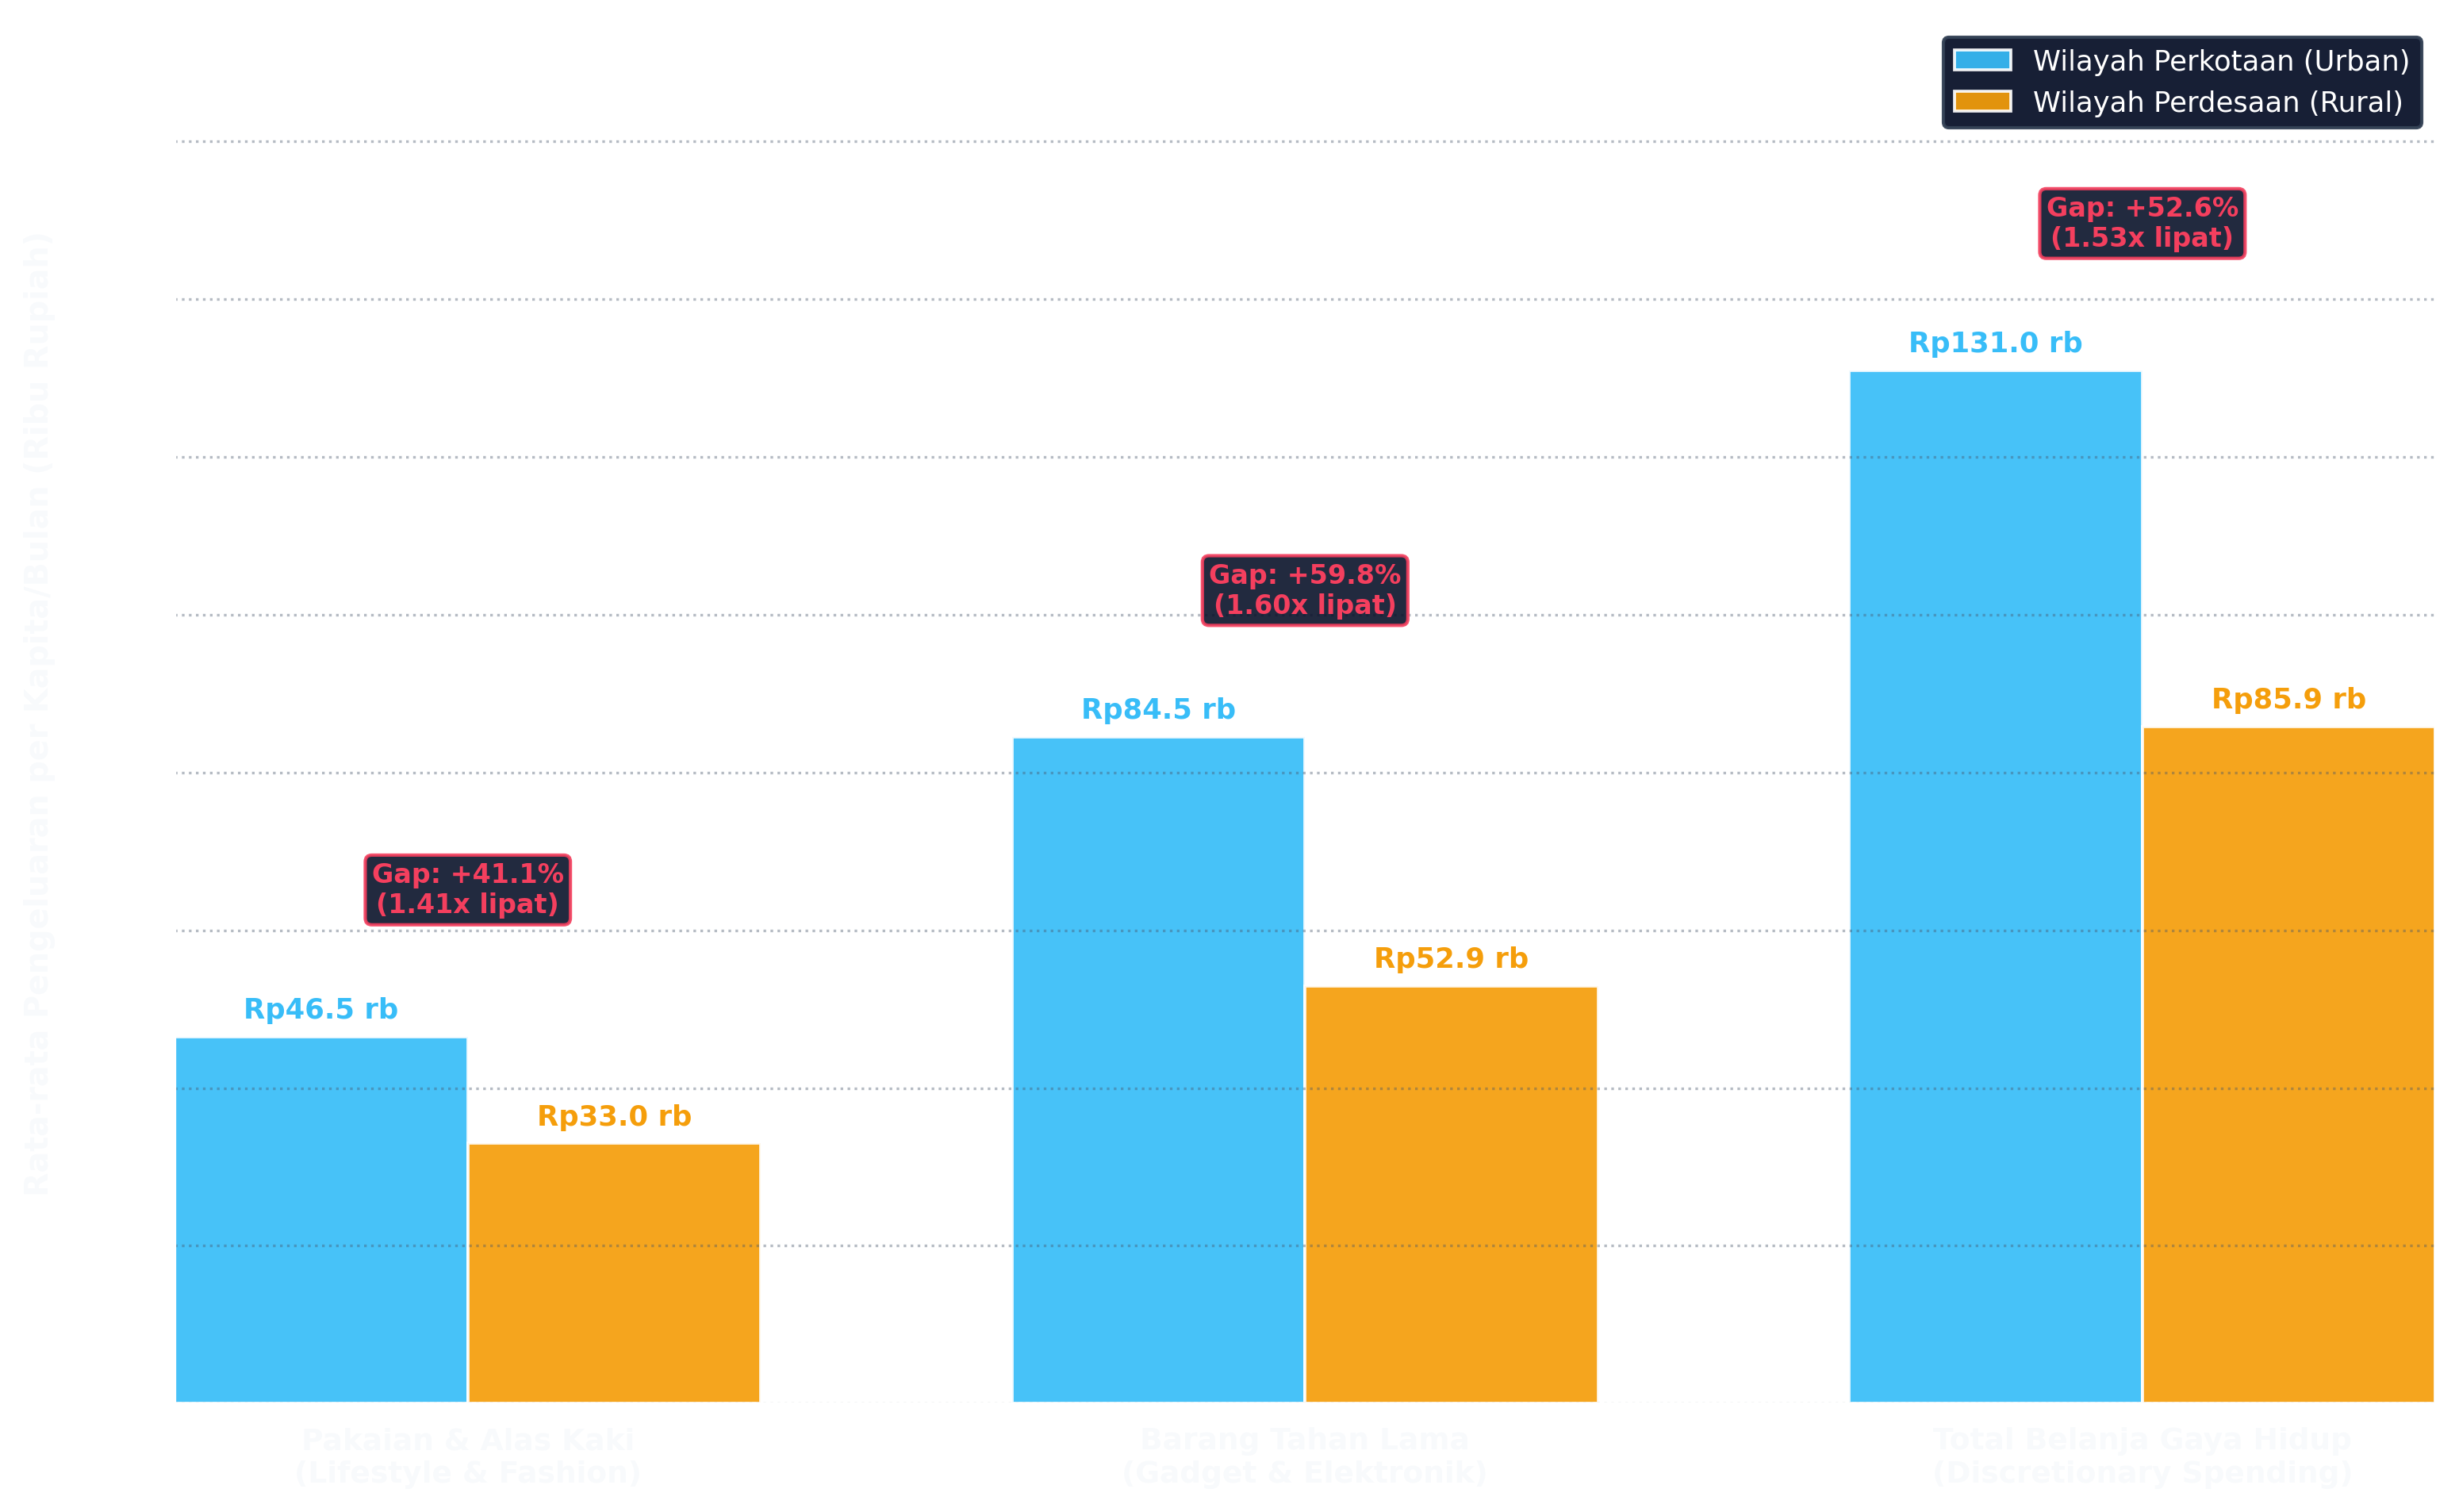

In [54]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Load Data BPS Susenas
df_exp = pd.read_csv('Dataset/pengeluaran_pakaian_btl_bukanmakanan.csv')

# 2. Hitung Rata-rata Nasional Perkotaan vs Perdesaan
urban_pakaian = df_exp['Pakaian_AlasKaki_TutupKepala_Perkotaan'].mean()
rural_pakaian = df_exp['Pakaian_AlasKaki_TutupKepala_Perdesaan'].dropna().mean()

urban_btl = df_exp['Barang_Tahan_Lama_Perkotaan'].mean()
rural_btl = df_exp['Barang_Tahan_Lama_Perdesaan'].dropna().mean()

urban_disc = urban_pakaian + urban_btl
rural_disc = rural_pakaian + rural_btl

# -------------------------------------------------------------
# 3. Visualisasi Grouped Bar Chart (Dark Slate Theme)
# -------------------------------------------------------------
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(9.5, 5.8), dpi=300)
fig.patch.set_facecolor('#0B132B')
ax.set_facecolor('#1C2541')

categories = [
    'Pakaian & Alas Kaki\n(Lifestyle & Fashion)',
    'Barang Tahan Lama\n(Gadget & Elektronik)',
    'Total Belanja Gaya Hidup\n(Discretionary Spending)',
]

urban_vals = [urban_pakaian / 1000, urban_btl / 1000, urban_disc / 1000]
rural_vals = [rural_pakaian / 1000, rural_btl / 1000, rural_disc / 1000]

x = np.arange(len(categories))
width = 0.35

rects1 = ax.bar(
    x - width / 2,
    urban_vals,
    width,
    label='Wilayah Perkotaan (Urban)',
    color='#38BDF8',
    alpha=0.92,
    edgecolor='#FFFFFF',
    linewidth=0.9,
)
rects2 = ax.bar(
    x + width / 2,
    rural_vals,
    width,
    label='Wilayah Perdesaan (Rural)',
    color='#F59E0B',
    alpha=0.92,
    edgecolor='#FFFFFF',
    linewidth=0.9,
)

# Anotasi Nilai di Atas Batang
for rect in rects1:
  h = rect.get_height()
  ax.annotate(
      f'Rp{h:.1f} rb',
      xy=(rect.get_x() + rect.get_width() / 2, h),
      xytext=(0, 4),
      textcoords='offset points',
      ha='center',
      va='bottom',
      fontsize=8.5,
      color='#38BDF8',
      fontweight='bold',
  )

for rect in rects2:
  h = rect.get_height()
  ax.annotate(
      f'Rp{h:.1f} rb',
      xy=(rect.get_x() + rect.get_width() / 2, h),
      xytext=(0, 4),
      textcoords='offset points',
      ha='center',
      va='bottom',
      fontsize=8.5,
      color='#F59E0B',
      fontweight='bold',
  )

# Anotasi Gap Persentase & Rasio
diff_pct = [
    (urban_pakaian - rural_pakaian) / rural_pakaian * 100,
    (urban_btl - rural_btl) / rural_btl * 100,
    (urban_disc - rural_disc) / rural_disc * 100,
]
ratios = [
    urban_pakaian / rural_pakaian,
    urban_btl / rural_btl,
    urban_disc / rural_disc,
]

for i in range(len(categories)):
  top_y = max(urban_vals[i], rural_vals[i]) + 15
  ax.annotate(
      f'Gap: +{diff_pct[i]:.1f}%\n({ratios[i]:.2f}x lipat)',
      xy=(x[i], top_y),
      ha='center',
      va='bottom',
      fontsize=8,
      color='#F43F5E',
      fontweight='bold',
      bbox=dict(
          boxstyle='round,pad=0.25',
          facecolor='#0B132B',
          edgecolor='#F43F5E',
          alpha=0.9,
      ),
  )

ax.set_ylabel(
    'Rata-rata Pengeluaran per Kapita/Bulan (Ribu Rupiah)',
    color='#F8FAFC',
    fontsize=9.5,
    fontweight='bold',
    labelpad=10,
)
ax.set_xticks(x)
ax.set_xticklabels(categories, color='#F8FAFC', fontsize=9, fontweight='bold')
ax.set_ylim(0, 175)
ax.grid(color='#334155', linestyle=':', alpha=0.5, axis='y')

# Main Insight Box
insight_text = (
    'DISPARITAS KONSUMTIF PERKOTAAN:\n'
    '─────────────────────────────────\n'
    '• Belanja Gadget/BTL perkotaan 1,60x lipat lebih tinggi dari desa.\n'
    '• Tekanan gaya hidup perkotaan menciptakan kebutuhan fasilitas\n'
    '  pembiayaan instan (Paylater/Pinjol) yang memicu risiko gagal bayar.'
)
ax.text(
    0.03,
    0.94,
    insight_text,
    transform=ax.transAxes,
    fontsize=7.8,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round,pad=0.45',
        facecolor='#0B132B',
        edgecolor='#38BDF8',
        alpha=0.92,
    ),
    color='#F8FAFC',
    family='monospace',
)

plt.title(
    'DISPARITAS PENGELUARAN KONSUMTIF GAYA HIDUP PERKOTAAN VS PERDESAAN (BPS'
    ' SUSENAS)\nBukti Empiris Bias Belanja Barang Tahan Lama & Mode sebagai'
    ' Pemicu Kebutuhan Pinjaman Finansial',
    fontsize=10.5,
    fontweight='bold',
    color='#F8FAFC',
    pad=15,
)
ax.legend(
    loc='upper right',
    facecolor='#0B132B',
    edgecolor='#334155',
    fontsize=8.5,
    framealpha=0.95,
)

plt.tight_layout()
plt.savefig('babak3_bar_urban_vs_rural.png', dpi=300)
plt.show()

# -------------------------------------------------------------
# 4. Versi Polos Transparan (Khusus Desain Poster)
# -------------------------------------------------------------
fig_tr, ax_tr = plt.subplots(figsize=(9.5, 5.8), dpi=300)
fig_tr.patch.set_alpha(0.0)
ax_tr.patch.set_alpha(0.0)

rects1_tr = ax_tr.bar(
    x - width / 2,
    urban_vals,
    width,
    label='Wilayah Perkotaan (Urban)',
    color='#38BDF8',
    alpha=0.92,
    edgecolor='#FFFFFF',
    linewidth=0.9,
)
rects2_tr = ax_tr.bar(
    x + width / 2,
    rural_vals,
    width,
    label='Wilayah Perdesaan (Rural)',
    color='#F59E0B',
    alpha=0.92,
    edgecolor='#FFFFFF',
    linewidth=0.9,
)

for rect in rects1_tr:
  h = rect.get_height()
  ax_tr.annotate(
      f'Rp{h:.1f} rb',
      xy=(rect.get_x() + rect.get_width() / 2, h),
      xytext=(0, 4),
      textcoords='offset points',
      ha='center',
      va='bottom',
      fontsize=8.5,
      color='#38BDF8',
      fontweight='bold',
  )

for rect in rects2_tr:
  h = rect.get_height()
  ax_tr.annotate(
      f'Rp{h:.1f} rb',
      xy=(rect.get_x() + rect.get_width() / 2, h),
      xytext=(0, 4),
      textcoords='offset points',
      ha='center',
      va='bottom',
      fontsize=8.5,
      color='#F59E0B',
      fontweight='bold',
  )

for i in range(len(categories)):
  top_y = max(urban_vals[i], rural_vals[i]) + 15
  ax_tr.annotate(
      f'Gap: +{diff_pct[i]:.1f}%\n({ratios[i]:.2f}x lipat)',
      xy=(x[i], top_y),
      ha='center',
      va='bottom',
      fontsize=8,
      color='#F43F5E',
      fontweight='bold',
      bbox=dict(
          boxstyle='round,pad=0.25',
          facecolor='#0B132B',
          edgecolor='#F43F5E',
          alpha=0.9,
      ),
  )

ax_tr.set_ylabel(
    'Rata-rata Pengeluaran per Kapita/Bulan (Ribu Rupiah)',
    color='#F8FAFC',
    fontsize=9.5,
    fontweight='bold',
    labelpad=10,
)
ax_tr.set_xticks(x)
ax_tr.set_xticklabels(categories, color='#F8FAFC', fontsize=9, fontweight='bold')
ax_tr.set_ylim(0, 175)
ax_tr.grid(color='#475569', linestyle=':', alpha=0.4, axis='y')
ax_tr.legend(
    loc='upper right',
    facecolor='#0B132B',
    edgecolor='#334155',
    fontsize=8.5,
    framealpha=0.95,
)

plt.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0)
plt.margins(0, 0)
plt.savefig(
    'babak3_bar_urban_vs_rural_transparent.png',
    dpi=300,
    transparent=True,
    bbox_inches='tight',
    pad_inches=0.02,
)
plt.show()

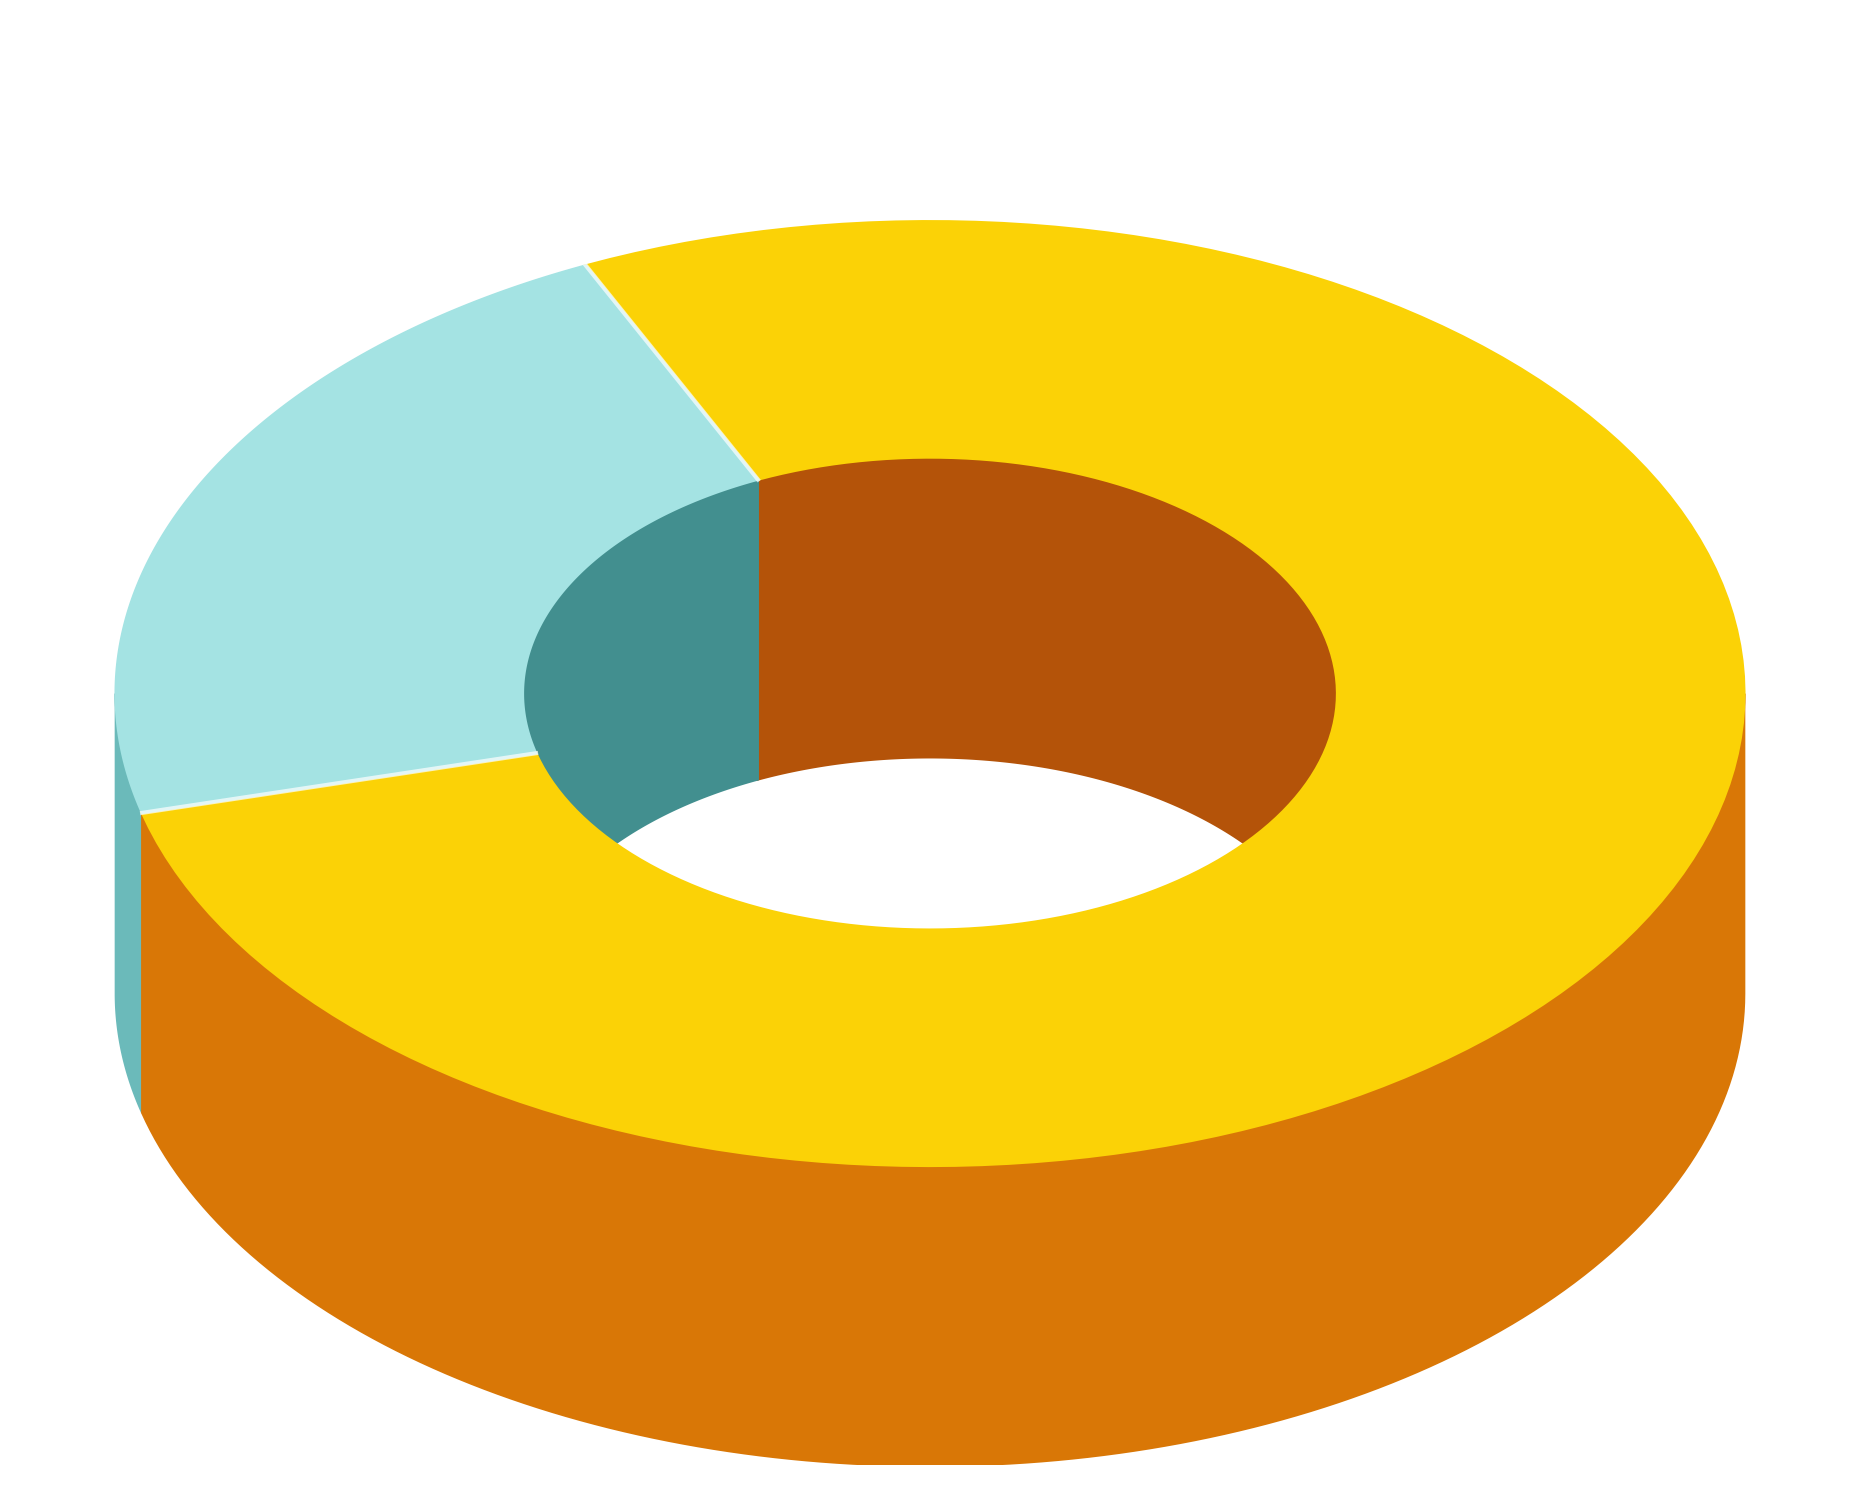

Gambar berhasil disimpan sebagai: donut_3d_kuning_utama.png


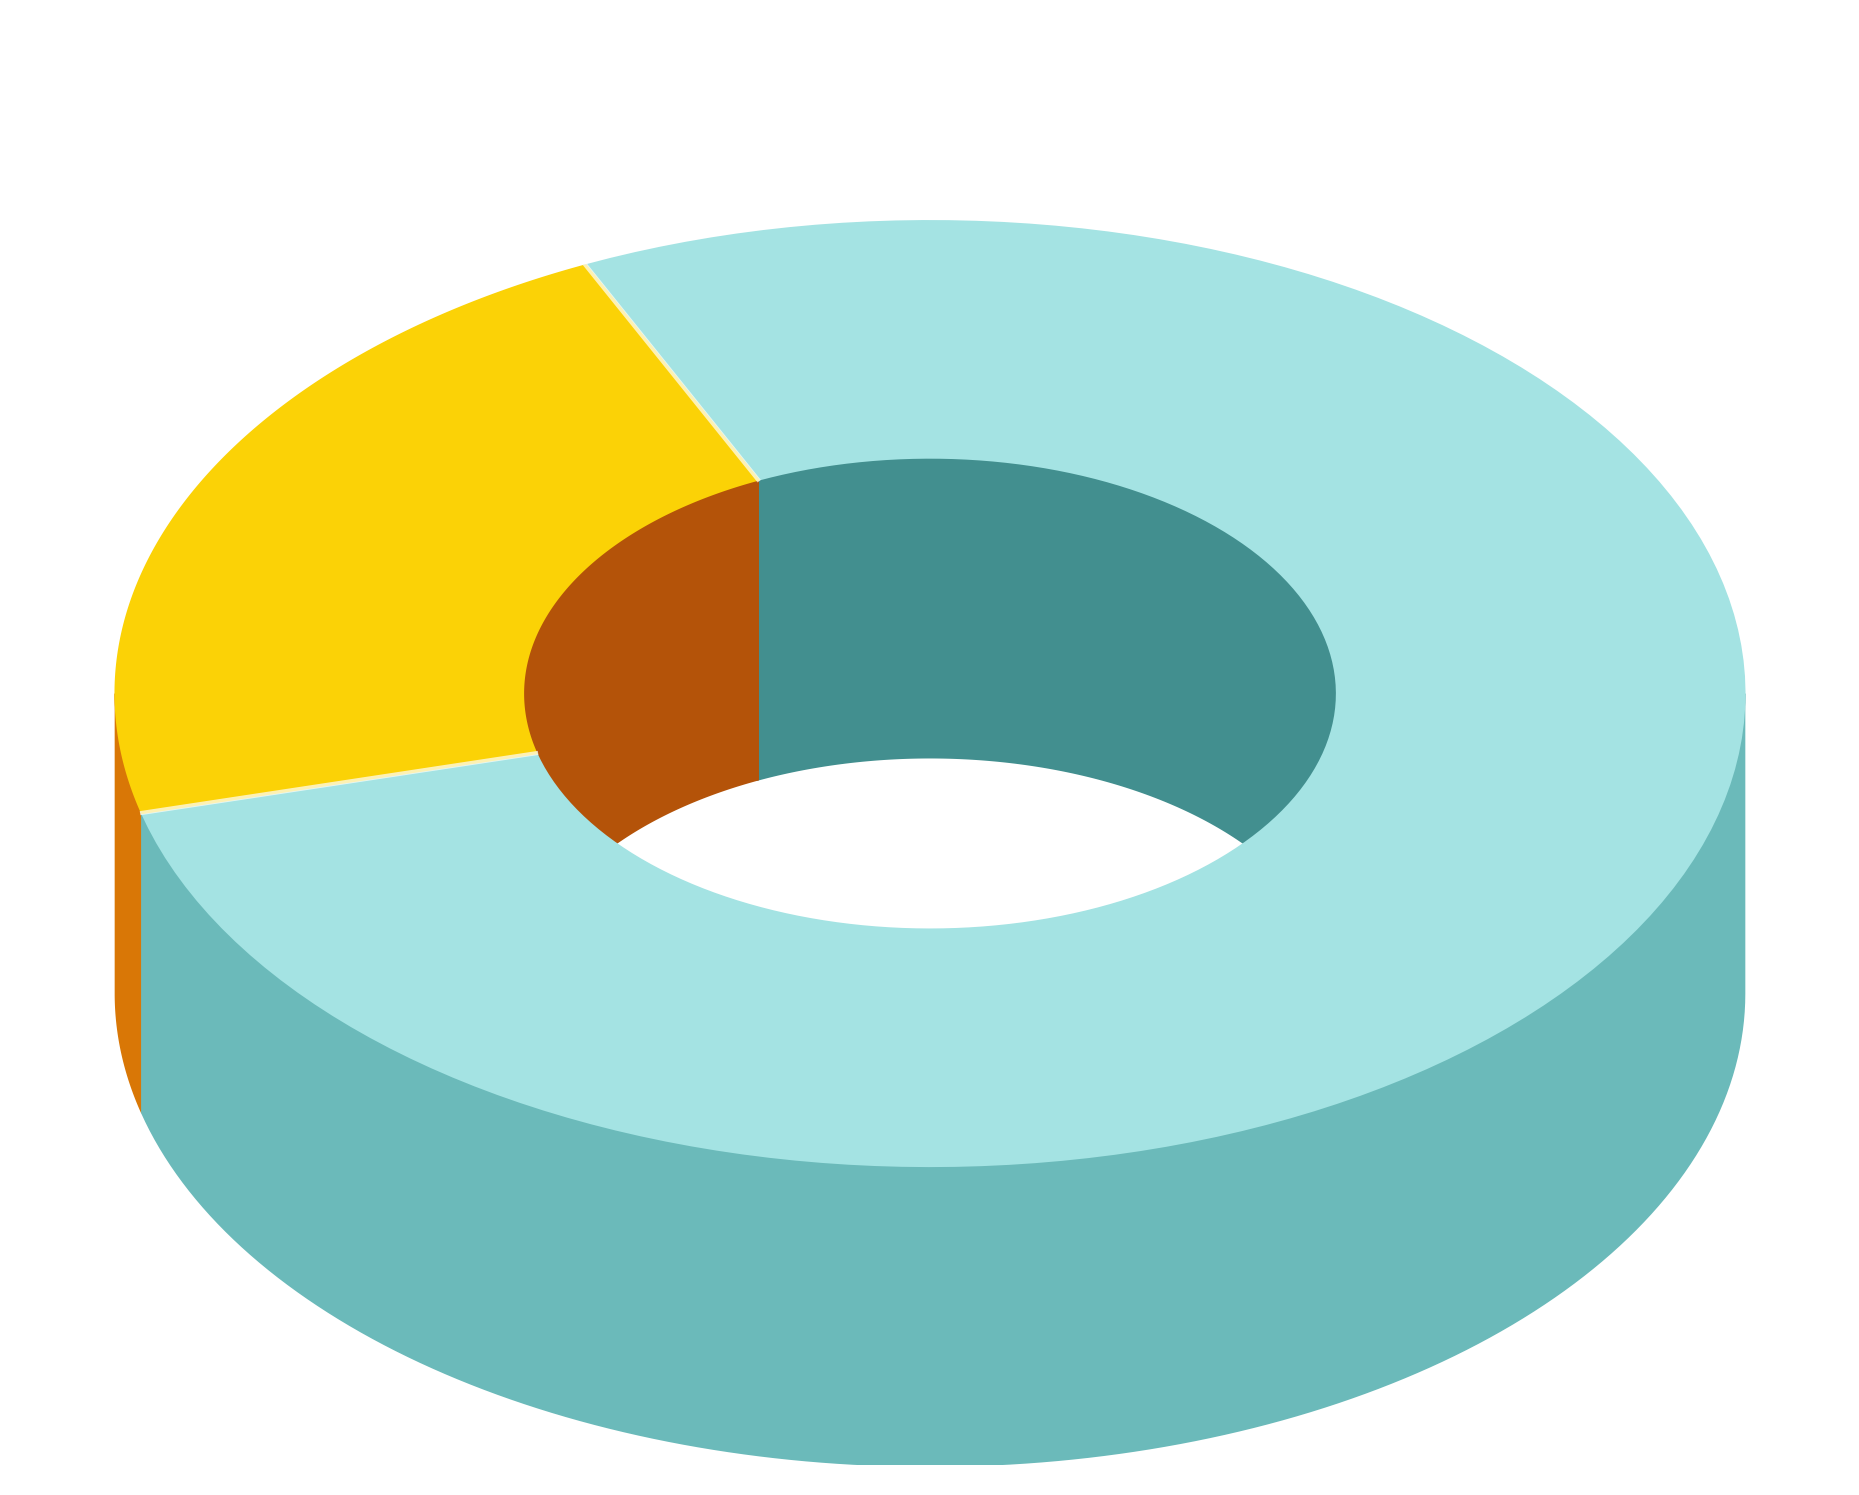

Gambar berhasil disimpan sebagai: donut_3d_cyan_utama.png


In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np


def generate_3d_donut_clean(
    val_main=77.88,
    val_sec=22.12,
    colors_main=None,
    colors_sec=None,
    filename='donut_3d_pure_custom.png',
):
    # Validasi dan set warna default jika tidak disediakan
    if colors_main is None:
        # Default Kuning berdasarkan #fbd206 dengan bayangan
        colors_main = {'top': '#fbd206', 'side': '#d4af02', 'inner': '#997c00'}
    if colors_sec is None:
        # Default Cyan berdasarkan #a4e3e3 dengan bayangan
        colors_sec = {'top': '#a4e3e3', 'side': '#6bbaba', 'inner': '#428f8f'}

    fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
    # Set background figure transparan
    fig.patch.set_alpha(0.0)
    # Set background axes transparan
    ax.patch.set_alpha(0.0)

    # 1. Parameter Geometri 3D Isometrik
    cx, cy = 0.5, 0.54
    R_out_x = 0.38
    aspect = 0.58  # Sudut kemiringan perspektif 3D
    R_out_y = R_out_x * aspect

    hole_ratio = 0.50  # Diameter rongga dalam
    R_in_x = R_out_x * hole_ratio
    R_in_y = R_out_y * hole_ratio

    H = 0.14  # Ketebalan silinder 3D

    # 2. Perhitungan Sudut Irisan (Irisan sekunder di kiri atas)
    th_s2_start = np.radians(115)
    th_s2_span = np.radians(360 * (val_sec / (val_main + val_sec)))
    th_s2_end = th_s2_start + th_s2_span

    th_s1_start = th_s2_end
    th_s1_end = th_s2_start + 2 * np.pi

    # Fungsi pembentuk poligon dinding solid
    def make_wall_polygon(r_x, r_y, th_start, th_end, h, n_pts=150):
        thetas = np.linspace(th_start, th_end, n_pts)
        x_top = cx + r_x * np.cos(thetas)
        y_top = cy + r_y * np.sin(thetas)
        x_bot = cx + r_x * np.cos(thetas[::-1])
        y_bot = (cy - h) + r_y * np.sin(thetas[::-1])
        verts = list(
            zip(np.concatenate([x_top, x_bot]), np.concatenate([y_top, y_bot]))
        )
        return Polygon(verts, closed=True)

    # 3. Dinding Samping Luar (Visible Range: pi s.d. 2*pi untuk perspektif ini)
    if th_s2_end > np.pi:
        # Bagian dinding luar untuk irisan sekunder
        wall_s2_out = make_wall_polygon(R_out_x, R_out_y, np.pi, th_s2_end, H)
        wall_s2_out.set_facecolor(colors_sec['side'])
        wall_s2_out.set_edgecolor(colors_sec['side'])
        wall_s2_out.set_linewidth(0.5)
        wall_s2_out.set_zorder(2)
        ax.add_patch(wall_s2_out)

    # Bagian dinding luar untuk irisan utama
    wall_s1_out = make_wall_polygon(R_out_x, R_out_y, th_s2_end, 2 * np.pi, H)
    wall_s1_out.set_facecolor(colors_main['side'])
    wall_s1_out.set_edgecolor(colors_main['side'])
    wall_s1_out.set_linewidth(0.5)
    wall_s1_out.set_zorder(2)
    ax.add_patch(wall_s1_out)

    # 4. Dinding Lubang Rongga Dalam (Visible Range: 0 s.d. pi)
    # Bagian dinding dalam untuk irisan utama
    wall_s1_in = make_wall_polygon(R_in_x, R_in_y, 0, th_s2_start, H)
    wall_s1_in.set_facecolor(colors_main['inner'])
    wall_s1_in.set_edgecolor(colors_main['inner'])
    wall_s1_in.set_linewidth(0.5)
    wall_s1_in.set_zorder(1)
    ax.add_patch(wall_s1_in)

    # Bagian dinding dalam untuk irisan sekunder
    wall_s2_in = make_wall_polygon(R_in_x, R_in_y, th_s2_start, np.pi, H)
    wall_s2_in.set_facecolor(colors_sec['inner'])
    wall_s2_in.set_edgecolor(colors_sec['inner'])
    wall_s2_in.set_linewidth(0.5)
    wall_s2_in.set_zorder(1)
    ax.add_patch(wall_s2_in)

    # 5. Permukaan Cincin Atas
    def make_top_sector(th1, th2, n_pts=150):
        thetas = np.linspace(th1, th2, n_pts)
        x_out = cx + R_out_x * np.cos(thetas)
        y_out = cy + R_out_y * np.sin(thetas)
        x_in = cx + R_in_x * np.cos(thetas[::-1])
        y_in = cy + R_in_y * np.sin(thetas[::-1])
        verts = list(
            zip(np.concatenate([x_out, x_in]), np.concatenate([y_out, y_in]))
        )
        return Polygon(verts, closed=True)

    # Top surface irisan utama
    top_s1 = make_top_sector(th_s1_start, th_s1_end)
    top_s1.set_facecolor(colors_main['top'])
    top_s1.set_edgecolor(colors_main['top']) # Border sewarna agar smooth
    top_s1.set_linewidth(0.6)
    top_s1.set_zorder(5)
    ax.add_patch(top_s1)

    # Top surface irisan sekunder
    top_s2 = make_top_sector(th_s2_start, th_s2_end)
    top_s2.set_facecolor(colors_sec['top'])
    top_s2.set_edgecolor(colors_sec['top']) # Border sewarna agar smooth
    top_s2.set_linewidth(0.6)
    top_s2.set_zorder(5)
    ax.add_patch(top_s2)

    # Garis pemisah tipis warna putih antar irisan di permukaan atas
    for th_cut in [th_s2_start, th_s2_end]:
        xc_in, yc_in = cx + R_in_x * np.cos(th_cut), cy + R_in_y * np.sin(th_cut)
        xc_out, yc_out = cx + R_out_x * np.cos(th_cut), cy + R_out_y * np.sin(
            th_cut
        )
        ax.plot(
            [xc_in, xc_out],
            [yc_in, yc_out],
            color='#FFFFFF',
            linewidth=1.0,
            alpha=0.7,
            zorder=6,
        )

    # Pengaturan Axes
    ax.set_xlim(0.08, 0.92)
    ax.set_ylim(0.18, 0.85)
    ax.set_aspect('equal')
    ax.axis('off')  # Matikan axis

    # Simpan gambar dan tampilkan di output notebook
    plt.subplots_adjust(top=1, bottom=0, right=1, left=0)
    plt.savefig(
        filename,
        dpi=300,
        transparent=True,  # Penting untuk background transparan
        bbox_inches='tight',
        pad_inches=0.01,
    )
    plt.show()
    print(f"Gambar berhasil disimpan sebagai: {filename}")
    plt.close()


# ==========================================
# Konfigurasi Palet Warna Spesifik
# Kuning: #fbd206, Biru/Cyan: #a4e3e3
# Termasuk variasi gelap untuk efek 3D
# ==========================================

color_yellow_custom = {
    'top': '#fbd206',    # Kuning Utama
    'side': '#D97706',   # Bayangan Luar (lebih gelap)
    'inner': '#B45309',  # Bayangan Dalam (paling gelap)
}

color_cyan_custom = {
    'top': '#a4e3e3',    # Biru/Cyan Utama
    'side': '#6bbaba',   # Bayangan Luar (lebih gelap)
    'inner': '#428f8f',  # Bayangan Dalam (paling gelap)
}

# --- Eksekusi ---

# Versi A: Utama Kuning (#fbd206), Sekunder Cyan (#a4e3e3)
generate_3d_donut_clean(
    val_main=77.88,
    val_sec=22.12,
    colors_main=color_yellow_custom,
    colors_sec=color_cyan_custom,
    filename='donut_3d_kuning_utama.png',
)

# Versi B: Utama Cyan (#a4e3e3), Sekunder Kuning (#fbd206)
generate_3d_donut_clean(
    val_main=77.88,
    val_sec=22.12,
    colors_main=color_cyan_custom,
    colors_sec=color_yellow_custom,
    filename='donut_3d_cyan_utama.png',
)